In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/Operational_risk/modules')

In [ ]:
from typing import Union

import granger_analysis
import graphs
import hill_plot_new_patched

import recent_lag

import l1_l2_gpd_patched_new_catprune

#Total

In [ ]:
import numpy as np
import pandas as pd
from functools import reduce
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import minimize
from scipy.stats import genpareto
import copy

#############################################
# 1. 데이터 전처리
#############################################
# (1) 엑셀 파일 읽기 및 날짜 정리
# 실제 파일 경로로 수정하세요.
sasop_path = '/content/drive/MyDrive/sasop.xlsx'
# 손실 데이터 (미국 사건만 선택)
df1 = pd.read_excel(sasop_path)



In [ ]:
df=df1.copy()

In [ ]:
us_df = df[df['Country of Incident'] == 'United States']
loss_df = us_df[['First Year of Event','Industry Sector Code','Basel Business Line - Level 2','Event Risk Category','Loss Amount ($M)']].copy()
loss_df.rename(columns={'First Year of Event':'Date', 'Loss Amount ($M)':'Current Value of Loss'}, inplace=True)
loss_df['Date'] = pd.to_datetime(loss_df['Date']).dt.strftime('%Y')
loss_df.sort_values(by='Date', inplace=True)
loss_df = loss_df[loss_df['Date'] >= '1979']


In [ ]:
loss_df_finance=loss_df

In [ ]:
loss_df['Event Risk Category'].unique()

array(['Clients, Products & Business Practices',
       'Employment Practices and Workplace Safety',
       'Damage to Physical Assets', 'Internal Fraud', 'External Fraud',
       'Execution, Delivery & Process Management',
       'Business Disruption and System Failures'], dtype=object)

In [ ]:
loss_df_finance.rename(columns={"Basel Business Line - Level 2":"Business"},inplace=True)
loss_df_finance.drop(columns=['Industry Sector Code'],inplace=True)

In [ ]:
loss_df_finance['Business'].unique()

array(['Professional, Scientific and Technical Services',
       'Commercial Banking', 'Manufacturing',
       'Transportation and Warehousing',
       'Professional Liability/Fidelity Coverage', 'Construction',
       'Wholesale Trade', 'Retail Banking', 'Utilities',
       'Educational Services', 'Information', 'Private Banking',
       'Property and Casualty Insurance', 'Market Making',
       'Retail Brokerage', 'Mining', 'Arts, Entertainment and Recreation',
       'Life Insurance and Benefit Plans', 'Retail Trade',
       'Agriculture, Forestry, Fishing and Hunting', 'Corporate Trust',
       'Brokerage and Advisory', 'Discretionary Fund Management',
       'Other Services (except Public Administration)',
       'Health Care and Social Assistance',
       'Administrative and Support, Waste Management and Remediation Services',
       'Custody', 'Card Services', 'Real Estate, Rental and Leasing',
       'Non-Profit Organizations', 'Corporate Finance',
       'Accommodation and Foo

In [ ]:
import re
import pandas as pd

# 입력 컬럼
SOURCE_COL = 'Business'

def _norm(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    # 정규화: & -> and, / -> space, -, , -> space, 괄호 제거, 다중공백 축소
    s = s.replace('&', ' and ')
    s = re.sub(r'[\/,\-]', ' ', s)
    s = re.sub(r'[\(\)\[\]]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    # 특수 케이스 보정
    s = s.replace('foodservices', 'food services')
    s = s.replace('non discretionary', 'non-discretionary')
    return s

# -------------------------------
# 1) 금융 도메인 상위 라인 매핑
# -------------------------------
FIN_MAP = {
    # Banking
    'retail banking': 'Banking',
    'commercial banking': 'Banking',
    'private banking': 'Banking',
    'card services': 'Banking',
    # Markets & Treasury
    'market making': 'Markets & Treasury',
    'sales': 'Markets & Treasury',
    'proprietary positions': 'Markets & Treasury',
    'treasury': 'Markets & Treasury',
    # Investment Banking
    'corporate finance': 'Investment Banking',
    'municipal government finance': 'Investment Banking',  # 슬래시 정규화 반영
    # Brokerage & Advisory
    'retail brokerage': 'Brokerage & Advisory',
    'brokerage and advisory': 'Brokerage & Advisory',
    'advisory services': 'Brokerage & Advisory',
    # Asset & Wealth Mgmt
    'discretionary fund management': 'Asset & Wealth Mgmt',
    'non-discretionary fund management': 'Asset & Wealth Mgmt',
    'merchant banking': 'Asset & Wealth Mgmt',
    # Asset Servicing & Trust
    'custody': 'Asset Servicing & Trust',
    'corporate trust': 'Asset Servicing & Trust',
    # Insurance
    'property and casualty insurance': 'Insurance',
    'life insurance and benefit plans': 'Insurance',
    'health insurance': 'Insurance',
    'reinsurance': 'Insurance',
    'corporate agency': 'Insurance',
    'professional liability fidelity coverage': 'Insurance',
    # Others
    'external clients': 'Others',
    'others': 'Others',
}

# -------------------------------
# 2) 비금융(NAICS류) 상위 그룹 매핑
# -------------------------------
NONFIN_MAP = {
    'manufacturing': 'Manufacturing',
    'construction': 'Construction',
    'utilities': 'Utilities',
    'mining': 'Mining',
    'retail trade': 'Retail Trade',
    'wholesale trade': 'Wholesale Trade',
    'transportation and warehousing': 'Transportation & Warehousing',
    'information': 'Information',
    'educational services': 'Educational Services',
    'health care and social assistance': 'Health Care & Social Assistance',
    'agriculture forestry fishing and hunting': 'Agriculture, Forestry, Fishing & Hunting',
    'real estate rental and leasing': 'Real Estate, Rental & Leasing',
    'accommodation and food services': 'Accommodation & Food Services',
    'arts entertainment and recreation': 'Arts, Entertainment & Recreation',
    'public administration': 'Public Administration',
    'professional scientific and technical services': 'Professional Services',
    'administrative and support waste management and remediation services': 'Admin & Support, Waste Mgmt',
    'management of companies and enterprises': 'Mgmt of Companies & Enterprises',
    'other services except public administration': 'Other Services',
    'non-profit organizations': 'Non-Profit',
}

# -------------------------------
# 3) 키워드 휴리스틱 (미지정 값 보조 분류)
# -------------------------------
def _heuristic_fin(key: str):
    if any(w in key for w in ['bank', 'card']):
        return 'Banking'
    if any(w in key for w in ['market making', 'treasury', 'proprietary', 'sales']):
        return 'Markets & Treasury'
    if any(w in key for w in ['broker', 'advisory']):
        return 'Brokerage & Advisory'
    if any(w in key for w in ['fund', 'asset', 'merchant banking', 'wealth']):
        return 'Asset & Wealth Mgmt'
    if any(w in key for w in ['custody', 'trust']):
        return 'Asset Servicing & Trust'
    if 'insurance' in key or 'reinsurance' in key or 'liability' in key:
        return 'Insurance'
    if 'finance' in key:
        return 'Investment Banking'
    return None

def _heuristic_nonfin(key: str):
    # 순서 중요(특정성이 높은 것부터)
    if 'retail trade' in key or (('retail' in key) and ('trade' in key)):
        return 'Retail Trade'
    if 'wholesale' in key:
        return 'Wholesale Trade'
    if 'manufactur' in key:
        return 'Manufacturing'
    if 'construction' in key:
        return 'Construction'
    if 'transportation' in key or 'warehousing' in key:
        return 'Transportation & Warehousing'
    if 'utilities' in key:
        return 'Utilities'
    if any(w in key for w in ['agriculture','forestry','fishing','hunting']):
        return 'Agriculture, Forestry, Fishing & Hunting'
    if 'information' in key:
        return 'Information'
    if 'educational' in key or 'education' in key:
        return 'Educational Services'
    if 'health care' in key or 'social assistance' in key or 'healthcare' in key:
        return 'Health Care & Social Assistance'
    if 'real estate' in key or 'rental' in key or 'leasing' in key:
        return 'Real Estate, Rental & Leasing'
    if 'accommodation' in key or 'food services' in key:
        return 'Accommodation & Food Services'
    if any(w in key for w in ['arts','entertainment','recreation']):
        return 'Arts, Entertainment & Recreation'
    if 'public administration' in key:
        return 'Public Administration'
    if 'professional scientific' in key or 'technical services' in key:
        return 'Professional Services'
    if 'administrative and support' in key or 'waste management' in key or 'remediation' in key:
        return 'Admin & Support, Waste Mgmt'
    if 'management of companies' in key:
        return 'Mgmt of Companies & Enterprises'
    if 'non profit' in key or 'nonprofit' in key:
        return 'Non-Profit'
    if 'other services' in key:
        return 'Other Services'
    return None

# -------------------------------
# 4) 최종 분류 함수
# -------------------------------
def classify_sector_and_line(val):
    key = _norm(val)
    if key is None or key == '':
        return pd.Series(['Unknown', 'Others'])

    # 1) 직접 매핑
    if key in FIN_MAP:
        return pd.Series(['Finance', FIN_MAP[key]])
    if key in NONFIN_MAP:
        return pd.Series(['Non-Finance', NONFIN_MAP[key]])

    # 2) 휴리스틱(금융 → 비금융 순서)
    fin_guess = _heuristic_fin(key)
    if fin_guess:
        return pd.Series(['Finance', fin_guess])
    nonfin_guess = _heuristic_nonfin(key)
    if nonfin_guess:
        return pd.Series(['Non-Finance', nonfin_guess])

    # 3) 최종 기본값
    return pd.Series(['Unknown', 'Others'])

# 적용: 두 컬럼 생성
loss_df_finance[['SectorType', 'Business_line']] = (
    loss_df_finance[SOURCE_COL].apply(classify_sector_and_line)
)


In [ ]:
loss_df_finance=loss_df_finance.drop(columns=['Business','SectorType'])

In [ ]:
# Encode 'Event Risk Category'
df_encoded_a = pd.get_dummies(loss_df_finance, columns=['Event Risk Category'], prefix='Category')

# Use the result of the first encoding as input for the second encoding
df_encoded_b = pd.get_dummies(df_encoded_a, columns=['Business_line'], prefix='Category')

# Final encoded DataFrame
loss_df_finance = df_encoded_b.copy()


In [ ]:
import re

# ① CSV 읽기
cpu = pd.read_csv('/content/drive/MyDrive/CPU index.csv')[['date', 'cpu_index']]

# ② 전처리 ── 공백 제거
cpu['date'] = cpu['date'].str.strip()

# ③ 'YY-Mon' → 'Mon-YY' 로 재배열
cpu['date'] = cpu['date'].str.replace(
    r'^(\d{2})-([A-Za-z]{3})$',   # 2자리 연도-3자리 월
    r'\2-\1',                     # 월-연도로 바꾸기
    regex=True, flags=re.IGNORECASE
)

# ④ datetime 파싱
cpu['date'] = pd.to_datetime(cpu['date'], format='%b-%y', errors='coerce')

# ⑤ 원하는 포맷(문자열)으로 출력하거나, 월 Period 로도 사용 가능
cpu['date'] = cpu['date'].dt.strftime('%Y-%m')      # 문자열 형태


In [ ]:
import pandas as pd
import numpy as np
from functools import reduce

file_paths = {
    "us_cpi": "/content/drive/MyDrive/us_cpi.csv",
    "us_unemp": "/content/drive/MyDrive/us_unemp.csv",
    "us_vix": "/content/drive/MyDrive/us_vix.csv",
    "us_m1": "/content/drive/MyDrive/us_m1.csv",
    "us_home_price": "/content/drive/MyDrive/us_home price index.csv",
    "us_T10Y2Y": "/content/drive/MyDrive/us_T10Y2Y.csv",
    "sp500": "/content/drive/MyDrive/sp500_monthly.csv",
}

# Load
us_cpi = pd.read_csv(file_paths["us_cpi"])
us_unemp = pd.read_csv(file_paths["us_unemp"])
us_m1 = pd.read_csv(file_paths["us_m1"])
us_home_price = pd.read_csv(file_paths["us_home_price"])
us_T10Y2Y = pd.read_csv(file_paths["us_T10Y2Y"])
sp500 = pd.read_csv(file_paths["sp500"], skiprows=2)

# Rename columns
us_T10Y2Y.rename(columns={'T10Y2Y': '10_2'}, inplace=True)
us_home_price.rename(columns={'USSTHPI': 'House Price Index'}, inplace=True)
us_m1.rename(columns={'WM1NS': 'M1'}, inplace=True)
us_cpi.rename(columns={'CPIAUCSL': 'CPI'}, inplace=True)
us_unemp.rename(columns={'UNRATE': 'Unemployment Rate'}, inplace=True)
sp500.rename(columns={'Unnamed: 1': 'Close'}, inplace=True)
sp500 = sp500.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4", "Unnamed: 5"])
cpu.rename(columns={'date': 'Date'}, inplace=True)


# Date 처리 및 연 단위 평균
for df in [us_cpi, us_unemp, us_m1, us_home_price, us_T10Y2Y, sp500,cpu]:
    df.rename(columns={df.columns[0]: "Date"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"]).dt.year

us_T10Y2Y = us_T10Y2Y.groupby("Date").mean().reset_index()
us_home_price = us_home_price.groupby("Date").mean().reset_index()
us_m1 = us_m1.groupby("Date").mean().reset_index()
us_cpi = us_cpi.groupby("Date").mean().reset_index()
us_unemp = us_unemp.groupby("Date").mean().reset_index()
sp500 = sp500.groupby("Date").mean().reset_index()
cpu = cpu.groupby("Date").mean().reset_index()


# log-diff 처리
macro_dfs = {

    'Close_diff': (sp500, 'Close'),
}

# diff 열 추가
for diff_col, (df, col) in macro_dfs.items():
    df[diff_col] = np.log(df[col]).diff()

# sp500의 첫 번째 NaN만 특정 값으로 채움
sp500['Close_diff'].fillna(0.1635259493925565, inplace=True)

# 병합
dfs = [us_T10Y2Y, us_home_price, us_m1, us_cpi, us_unemp, sp500,cpu]
df_merged_macro = reduce(lambda left, right: pd.merge(left, right, on="Date", how="inner"), dfs)

# 최종 lag 데이터
df_merged_macro_lag = df_merged_macro[df_merged_macro["Date"] >= 1980].copy()
df_merged_macro_lag['Date'] = df_merged_macro_lag['Date'].astype(str)


/tmp/ipython-input-852055941.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sp500['Close_diff'].fillna(0.1635259493925565, inplace=True)


In [ ]:
import numpy as np
import pandas as pd
from functools import reduce
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import minimize
from scipy.stats import genpareto
import copy
#1986부터 사용
#############################################
# 1. 데이터 전처리 (연 단위)
#############################################
# (1) 엑셀 파일 읽기 및 날짜 정리
# 실제 파일 경로로 수정하세요.

epu_kr_path = '/content/drive/MyDrive/Korea_Overall_EPU.xlsx'
epu_kr_cat_path = '/content/drive/MyDrive/Korea_Categorical_PU_Indices.xlsx'
epu_usa_path = '/content/drive/MyDrive/US_Policy_Uncertainty_Data.xlsx'
epu_usa_cat_path = '/content/drive/MyDrive/Categorical_EPU_Data.xlsx'


# 미국 EPU 데이터
epu_usa = pd.read_excel(epu_usa_path)
epu_usa_cat = pd.read_excel(epu_usa_cat_path)
# 연도만 추출 (datetime 변환 후 정수형으로)
epu_usa['Year'] = pd.to_datetime(epu_usa['Year'], format='%Y').dt.year.astype(int)
epu_usa_cat['Year'] = pd.to_datetime(epu_usa_cat['Year'], format='%Y').dt.year.astype(int)
# 연도 필터링 (1985~2022)
epu_usa_cl = epu_usa[(epu_usa['Year'] < 2023)].copy()
epu_usa_cat_cl = epu_usa_cat[ (epu_usa_cat['Year'] < 2023)].copy()
# 최종적으로 'Date' 컬럼에 연도만(문자형) 저장
epu_usa_cl['Date'] = epu_usa_cl['Year'].astype(str)
epu_usa_cat_cl['Date'] = epu_usa_cat_cl['Year'].astype(str)
epu_usa_cl_lag = epu_usa_cl.copy()
epu_usa_cat_cl_lag = epu_usa_cat_cl.copy()


epu_usa_cl['Date'] = epu_usa_cl['Year'].astype(str)

epu_overall = (
    epu_usa_cl
    .groupby('Date')[['Three_Component_Index','News_Based_Policy_Uncert_Index']]
    .mean()
    .reset_index()
)

# 2) 범주형 EPU 연평균 집계
# ————————
cat_cols = [
    '1. Economic Policy Uncertainty','2. Monetary policy',
    'Fiscal Policy (Taxes OR Spending)','3. Taxes',
    '4. Government spending','5. Health care',
    '6. National security','7. Entitlement programs',
    '8. Regulation','Financial Regulation',
    '9. Trade policy','10. Sovereign debt, currency crises'
]
epu_usa_cat_cl['Date'] = epu_usa_cat_cl['Year'].astype(str)

epu_cats = (
    epu_usa_cat_cl
    .groupby('Date')[cat_cols]
    .mean()
    .reset_index()
)

# 3) 매크로 + EPU(전체+범주) 병합
# ———————————————
df_macro_epu = (
    df_merged_macro_lag
    .merge(epu_overall, on='Date', how='inner')
    .merge(epu_cats,    on='Date', how='inner')
)

# 4) 최종: 이벤트 손실(≈433행)과 1:1 병합
# ——————————————————————
final_df = df_macro_epu.merge(loss_df_finance, on='Date', how='inner')




In [ ]:
df_merged=final_df.copy()
df_merged['Exceedance']=df_merged['Current Value of Loss']

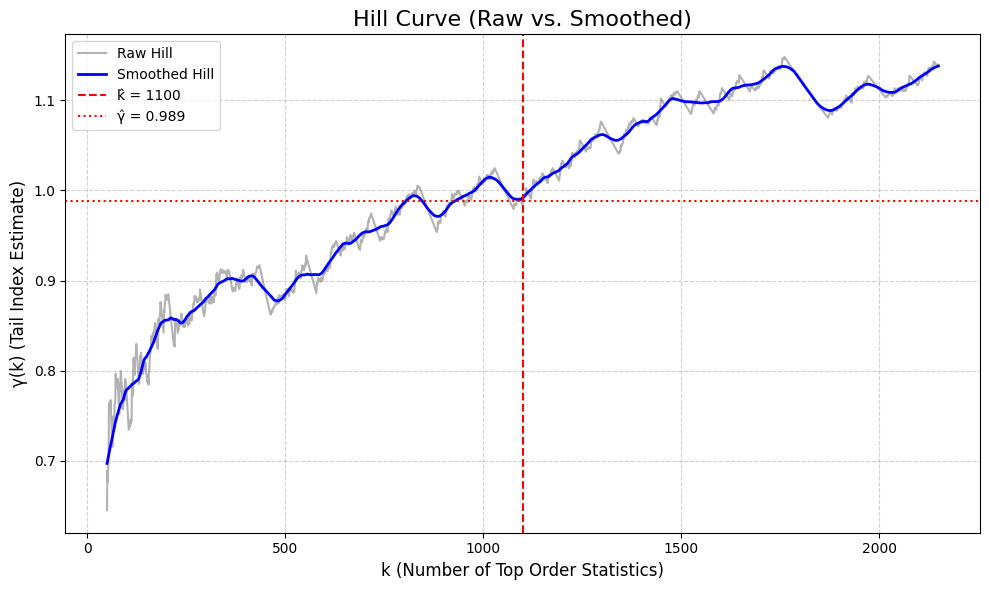

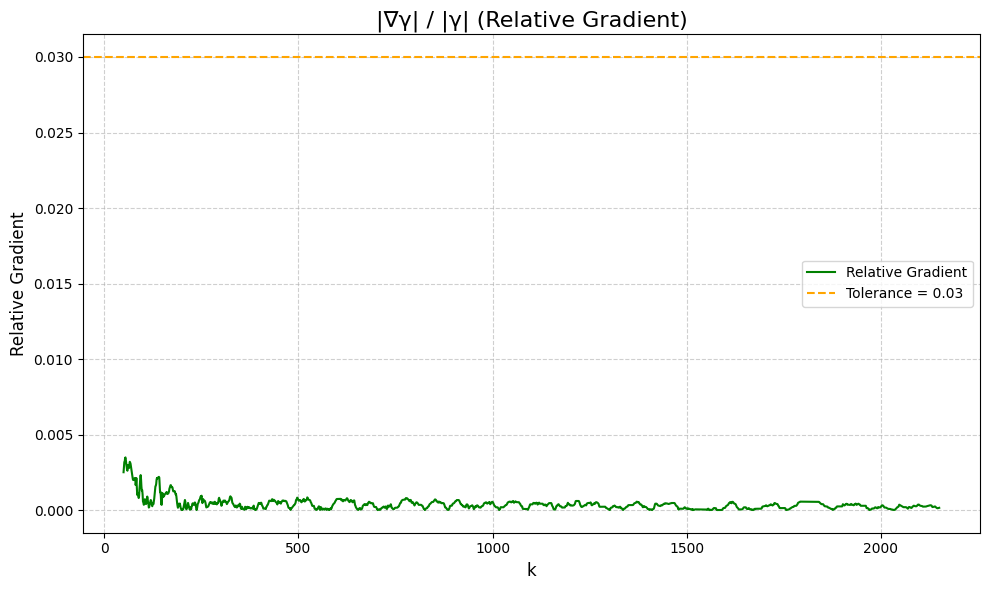

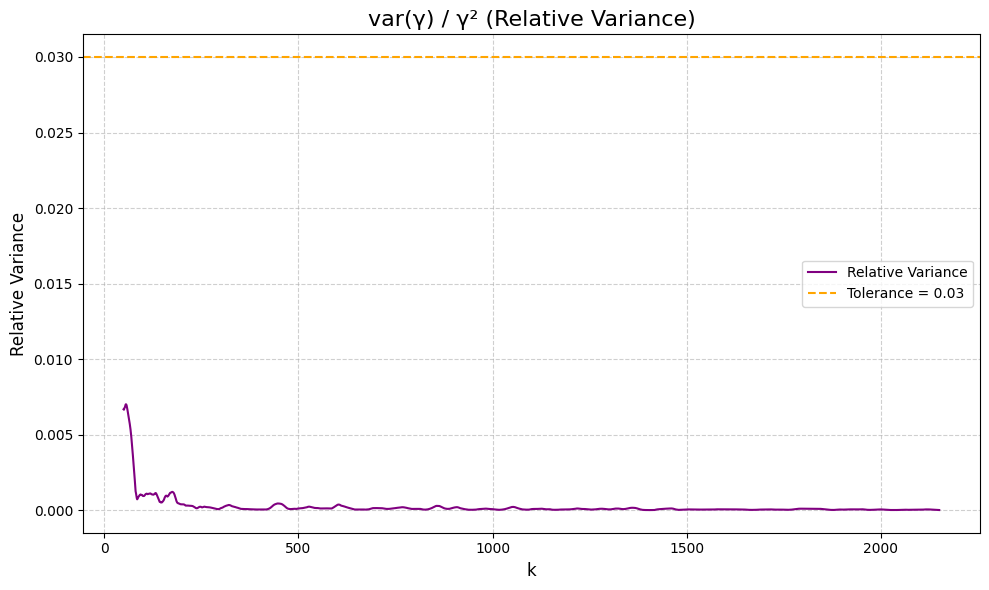

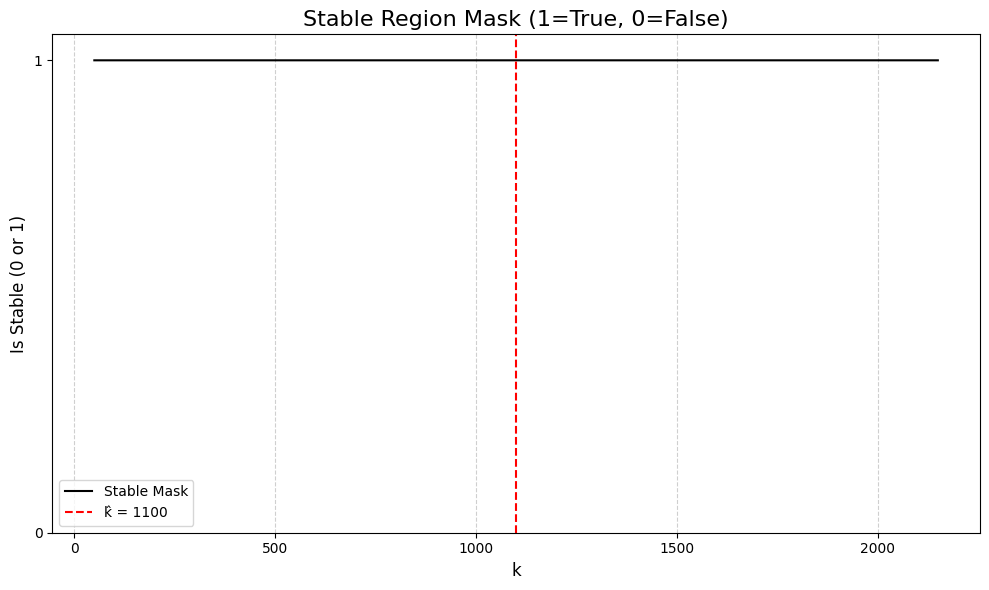


--- Results ---
Estimated Threshold (u_hat): 194.0000
Number of Exceedances (k_hat): 1100
Estimated Tail Index (gamma_hat): 0.9888
----------------


In [ ]:
# hill_plots.py ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple, Dict, Any

# It's assumed that the 'thresholding' module you created is in the same folder.
from hill_plot_new_patched import select_threshold, HillDiag

def _compute_hill_raw_curve(y: np.ndarray, ks: np.ndarray) -> np.ndarray:
    """
    Computes the raw (unsmoothed) Hill curve.
    γ_k = mean( log Y_(1..k) - log Y_(k+1) ), where Y are sorted positive values.
    """
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    y_desc = np.sort(y)[::-1]
    y_pos = y_desc[y_desc > 0]
    if y_pos.size < 2 or ks.size == 0: # Need at least 2 points to compute log-differences
        return np.array([])

    # Ensure k does not exceed valid index
    max_k = y_pos.size - 1
    valid_ks = ks[ks < max_k]
    if valid_ks.size == 0:
        return np.array([])

    return np.array([np.mean(np.log(y_pos[:k]) - np.log(y_pos[k])) for k in valid_ks], dtype=float)

def plot_hill_curve(
    y: np.ndarray,
    diag: HillDiag,
    k_hat: int,
    gamma_hat: float,
    *,
    title: str = "Hill Curve (Raw vs. Smoothed)",
) -> None:
    """
    Plots the Hill curve (raw vs. smoothed) and the estimated point (k_hat, gamma_hat).
    """
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot Hill curve.")
        return

    gamma_raw = _compute_hill_raw_curve(y, diag.k_grid)

    plt.figure(figsize=(10, 6))
    if gamma_raw.size:
        # Match raw curve to its valid k-grid
        max_k_raw = y.size - 1
        valid_ks_raw = diag.k_grid[diag.k_grid < max_k_raw]
        plt.plot(valid_ks_raw, gamma_raw, label="Raw Hill", alpha=0.6, color='gray')

    plt.plot(diag.k_grid, diag.gamma_hat, label="Smoothed Hill", color='blue', linewidth=2)
    plt.axvline(k_hat, linestyle="--", color='red', label=f"k̂ = {k_hat}")
    plt.axhline(gamma_hat, linestyle=":", color='red', label=f"γ̂ = {gamma_hat:.3f}")

    plt.title(title, fontsize=16)
    # CHANGED: Korean -> English
    plt.xlabel("k (Number of Top Order Statistics)", fontsize=12)
    plt.ylabel("γ(k) (Tail Index Estimate)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_grad_norm(
    diag: HillDiag,
    *,
    rel_grad_tol: float,
    title: str = "|∇γ| / |γ| (Relative Gradient)"
) -> None:
    """Plots the relative gradient and the tolerance line."""
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot grad_norm.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(diag.k_grid, diag.grad_norm, label="Relative Gradient", color='green')
    plt.axhline(rel_grad_tol, linestyle="--", color='orange', label=f"Tolerance = {rel_grad_tol}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Relative Gradient", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_var_rel(
    diag: HillDiag,
    *,
    rel_var_tol: float,
    title: str = "var(γ) / γ² (Relative Variance)"
) -> None:
    """Plots the relative variance and the tolerance line."""
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot var_rel.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(diag.k_grid, diag.var_rel, label="Relative Variance", color='purple')
    plt.axhline(rel_var_tol, linestyle="--", color='orange', label=f"Tolerance = {rel_var_tol}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Relative Variance", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_stable_mask(
    diag: HillDiag,
    *,
    rel_grad_tol: float,
    rel_var_tol: float,
    gamma_min: float,
    k_hat: int,
    title: str = "Stable Region Mask (1=True, 0=False)"
) -> None:
    """
    Visualizes the stable region mask:
    stable = (grad_norm < rel_grad_tol) & (var_rel < rel_var_tol) & (gamma_hat > gamma_min)
    """
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot stable mask.")
        return

    stable = (diag.grad_norm < rel_grad_tol) & (diag.var_rel < rel_var_tol) & (diag.gamma_hat > gamma_min)

    plt.figure(figsize=(10, 6))
    plt.step(diag.k_grid, stable.astype(int), where="mid", label="Stable Mask", color='black')
    plt.axvline(k_hat, linestyle="--", color='red', label=f"k̂ = {k_hat}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Is Stable (0 or 1)", fontsize=12)
    plt.yticks([0, 1])
    plt.legend()
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_hill_diagnostics(
    y: np.ndarray,
    *,
    # Parameters for thresholding._auto_hill
    k_min: int = 50,
    k_max_prop: float = 0.1,
    window: int = 61,
    rel_grad_tol: float = 0.04,
    rel_var_tol: float = 0.03,
    gamma_min: float = 0.02,
    min_plateau_len: int = 10,
    plateau_strategy: str = "longest",
    min_excess: Optional[int] = None,
    max_excess: Optional[int] = None,
    # Optional titles for individual plots
    titles: Optional[Dict[str, str]] = None,
    # For passing extra args to select_threshold
    extra_hill_kwargs: Optional[Dict[str, Any]] = None,
) -> Tuple[float, int, float, HillDiag]:
    """
    In a single call, this function:
      1) Runs select_threshold to get (u_hat, k_hat, gamma_hat, diag).
      2) Generates separate plots for Hill curve, grad_norm, var_rel, and stable mask.

    Returns: (u_hat, k_hat, gamma_hat, diag)
    """
    if titles is None:
        titles = {}
    if extra_hill_kwargs is None:
        extra_hill_kwargs = {}

    # Call select_threshold requesting the diagnostic data
    u_hat, k_hat, gamma_hat, diag = select_threshold(
        y,
        return_diag=True,
        k_min=k_min,
        k_max_prop=k_max_prop,
        window=window,
        rel_grad_tol=rel_grad_tol,
        rel_var_tol=rel_var_tol,
        gamma_min=gamma_min,
        min_plateau_len=min_plateau_len,
        plateau_strategy=plateau_strategy,
        min_excess=min_excess,
        max_excess=max_excess,
        **extra_hill_kwargs,
    )

    # 1) Hill Curve
    plot_hill_curve(
        y, diag, k_hat, gamma_hat,
        title=titles.get("hill", "Hill Curve (Raw vs. Smoothed)")
    )

    # 2) grad_norm
    plot_grad_norm(
        diag,
        rel_grad_tol=rel_grad_tol,
        title=titles.get("grad", "|∇γ| / |γ| (Relative Gradient)")
    )

    # 3) var_rel
    plot_var_rel(
        diag,
        rel_var_tol=rel_var_tol,
        title=titles.get("var", "var(γ) / γ² (Relative Variance)")
    )

    # 4) stable mask
    plot_stable_mask(
        diag,
        rel_grad_tol=rel_grad_tol,
        rel_var_tol=rel_var_tol,
        gamma_min=gamma_min,
        k_hat=k_hat,
        title=titles.get("stable", "Stable Region Mask (1=True, 0=False)")
    )

    return u_hat, k_hat, gamma_hat, diag


if __name__ == "__main__":

    # Run the diagnostic plotting function
    u_hat, k_hat, gamma_hat, diag = plot_hill_diagnostics(
        df_merged['Exceedance'],
        k_min=50,
        k_max_prop=0.1, # Use a larger proportion for better visualization
        window=61,
        rel_grad_tol=0.03,
        rel_var_tol=0.03, # Loosen var tolerance slightly for demo
        gamma_min=0.02,
        min_plateau_len=20,
        plateau_strategy="longest",
    )

    print("\n--- Results ---")
    print(f"Estimated Threshold (u_hat): {u_hat:.4f}")
    print(f"Number of Exceedances (k_hat): {k_hat}")
    print(f"Estimated Tail Index (gamma_hat): {gamma_hat:.4f}")
    print("----------------")

In [ ]:
n = len(df_merged['Exceedance'])
top_percent = (k_hat / n) * 100
print(f"Top {top_percent:.2f}% of data exceed threshold {u_hat:.2f}")


Top 5.11% of data exceed threshold 194.00


#ADF

##Comparision

In [ ]:

df = df_merged.copy()

# 1) 연도 만들기
if not pd.api.types.is_integer_dtype(df['Date']):
    df['Year'] = pd.to_datetime(df['Date']).dt.year
else:
    df['Year'] = df['Date']

# 2) 대상/피처/카테고리 정의
target_col = 'Exceedance'  # 타깃은 연도 총합으로 집계
base_vars = ['10_2','House Price Index','M1','CPI','Unemployment Rate',
             'Close','Close_diff','Three_Component_Index',
             'News_Based_Policy_Uncert_Index','1. Economic Policy Uncertainty',
             '2. Monetary policy','Fiscal Policy (Taxes OR Spending)','3. Taxes',
             '4. Government spending','5. Health care','6. National security',
             '7. Entitlement programs','8. Regulation','Financial Regulation',
             '9. Trade policy','10. Sovereign debt, currency crises','cpu_index']

# 이미 차분된 컬럼(예: Close_diff)은 이중 차분 방지를 위해 제외 권장
base_vars_clean = [c for c in base_vars if c in df.columns and not c.endswith('_diff') and c != target_col]
cat_cols = [c for c in df.columns if c.startswith('Category_')]

# 3) 집계 규칙: 타깃=sum, 매크로(이미 연평균된 값)=first, 카테고리 더미=max
agg_dict = {
    target_col: 'sum',
    **{c: 'first' for c in base_vars_clean},
    **{c: 'max' for c in cat_cols}
}

# 4) 연도 단위로 집계 -> 정렬 -> 인덱스 리셋
df_year = (df.groupby('Year', as_index=False)
             .agg(agg_dict)
             .sort_values('Year')
             .reset_index(drop=True))

# 4-1) 연도별 사건 수(N_t) 계산 후 병합 (원하면 나중에 그랜저에 포함해서 테스트 가능)
cnt = df.groupby('Year').size().rename('N_t').reset_index()
df_year = df_year.merge(cnt, on='Year', how='left')

# 5) 타깃 안정화 (합은 스케일이 커서 log1p 권장; 음수 없을 때만)
if (df_year[target_col] >= 0).all():
    df_year[target_col] = np.log1p(df_year[target_col])

# 6) 숫자형 보정 및 결측 제거(Granger는 NaN 불가)
cols_to_numeric = [target_col] + base_vars_clean + cat_cols + ['N_t']
for col in cols_to_numeric:
    if col in df_year.columns:
        df_year[col] = pd.to_numeric(df_year[col], errors='coerce')

# 그랜저에 쓸 핵심 컬럼만 NaN 제거
df_granger = df_year.dropna(subset=[target_col] + base_vars_clean)

# 7) 그랜저 파이프라인 실행 (연 단위이므로 max_lag를 3으로 낮춤 권장)
res = granger_analysis.run_granger_analysis_pipeline(
    df_granger,
    base_vars=base_vars_clean,      # N_t도 원하면 base_vars에 추가해서 N_t→타깃 테스트 가능
    target_col=target_col,
    transform='auto',
    max_lag=3
)

summary_df = recent_lag.get_most_recent_granger_lags(
    granger_df=res,
    target_variable=target_col
)

print("--- 변수별 가장 빠른 유의미한 시차 (Lag) 요약 ---")
print(summary_df)


--- 1. Starting Analysis Pipeline ---

--- 2. Checking variable stationarity (ADF Test) ---
Stationary variables: ['10_2', '1. Economic Policy Uncertainty', '2. Monetary policy', 'Fiscal Policy (Taxes OR Spending)', '3. Taxes', '4. Government spending', '6. National security', '8. Regulation', '10. Sovereign debt, currency crises']
Non-stationary variables to be differenced: ['House Price Index', 'M1', 'CPI', 'Unemployment Rate', 'Close', 'Three_Component_Index', 'News_Based_Policy_Uncert_Index', '5. Health care', '7. Entitlement programs', 'Financial Regulation', '9. Trade policy', 'cpu_index', 'Exceedance']

--- 3. Applying 'auto' differencing ---

--- 4. Running Granger Causality Test on processed data ---
Base variables: ['10_2', 'House Price Index_diff', 'M1_diff', 'CPI_diff', 'Unemployment Rate_diff', 'Close_diff', 'Three_Component_Index_diff', 'News_Based_Policy_Uncert_Index_diff', '1. Economic Policy Uncertainty', '2. Monetary policy', 'Fiscal Policy (Taxes OR Spending)', '3. T

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul


--- 5. Analysis Complete ---
'Exceedance'에 영향을 미치는 유의미한 변수를 찾지 못했습니다.
--- 변수별 가장 빠른 유의미한 시차 (Lag) 요약 ---
Empty DataFrame
Columns: [Causal_Var, Most_Recent_Lag]
Index: []


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


#Trainning

In [ ]:
import numpy as np
from scipy.optimize import minimize
from scipy import stats
from scipy.interpolate import BSpline
import warnings
from sklearn.preprocessing import StandardScaler

def create_bspline_basis(x, n_knots=10, degree=3):
    """
    Create B-spline basis functions for a variable

    Args:
        x: input variable (1D array)
        n_knots: number of interior knots
        degree: spline degree (3 for cubic splines)

    Returns:
        basis_matrix: (n_samples, n_basis) matrix of basis functions
        knots: knot positions
    """
    x_min, x_max = x.min(), x.max()

    # Create interior knots at quantiles
    interior_knots = np.quantile(x, np.linspace(0, 1, n_knots + 2)[1:-1])

    # Add boundary knots
    knots = np.concatenate([
        [x_min] * (degree + 1),
        interior_knots,
        [x_max] * (degree + 1)
    ])

    # Number of basis functions
    n_basis = len(knots) - degree - 1

    # Create basis matrix
    basis_matrix = np.zeros((len(x), n_basis))

    for i in range(n_basis):
        # Create a coefficient vector with 1 at position i
        c = np.zeros(n_basis)
        c[i] = 1.0

        # Create B-spline object
        spline = BSpline(knots, c, degree)
        basis_matrix[:, i] = spline(x)

    return basis_matrix, knots

def gpd_gam_comparison_spline(X_tail, y_tail, gpd_tail_tree_pruned, feature_names_list, u_threshold):
    """
    Accurate GPD GAM comparison using actual splines (not linear functions)
    """

    print("\n" + "="*70)
    print("GPD MODEL COMPARISON - WITH PROPER GAM IMPLEMENTATION")
    print("="*70)

    results = {}
    n_tail = len(y_tail)

    # 1. Classical GPD (baseline)
    print(f"\n1. Classical GPD (no covariates, n={n_tail}):")

    def objective_classical(params):
        sigma, gamma = params
        return l1_l2_gpd_patched_new_catprune.gpd_nll(y_tail, sigma, gamma)

    try:
        init_params = l1_l2_gpd_patched_new_catprune.fit_gpd_mle(y_tail)
        bounds = [(1e-6, None), (0.01, 3.0)]

        result = minimize(objective_classical, init_params, method='L-BFGS-B', bounds=bounds)

        if result.success:
            sigma_classical, gamma_classical = result.x
            ll_classical = -result.fun
            aic_classical = 2 * 2 - 2 * ll_classical

            print(f"   σ̂ = {sigma_classical:.0f}")
            print(f"   γ̂ = {gamma_classical:.3f}")
            print(f"   Log-likelihood: {ll_classical:.1f}")
            print(f"   AIC: {aic_classical:.0f}")

            results['Classical GPD'] = {
                'LL': ll_classical,
                'AIC': aic_classical,
                'n_params': 2,
                'sigma': sigma_classical,
                'gamma': gamma_classical
            }
    except Exception as e:
        print(f"   Classical GPD fitting failed: {e}")
        results['Classical GPD'] = {'LL': -np.inf, 'AIC': np.inf}

    # 2. GPD GLM (linear - for comparison)
    print(f"\n2. GPD GLM (linear covariates):")

    try:
        X_std = StandardScaler().fit_transform(X_tail)
        X_design_linear = np.column_stack([np.ones(len(X_std)), X_std])
        n_features_linear = X_design_linear.shape[1]

        def objective_glm(params):
            log_sigma_params = params[:n_features_linear]
            gamma_params = params[n_features_linear:]

            log_sigma = X_design_linear @ log_sigma_params
            gamma = X_design_linear @ gamma_params

            sigma = np.exp(np.clip(log_sigma, -10, 10))
            gamma = np.clip(gamma, 0.01, 3.0)

            total_nll = 0
            for i in range(len(y_tail)):
                nll_i = l1_l2_gpd_patched_new_catprune.gpd_nll(
                    np.array([y_tail[i]]), sigma[i], gamma[i]
                )
                if np.isfinite(nll_i):
                    total_nll += nll_i
                else:
                    return 1e10

            return total_nll

        init_params_glm = np.concatenate([
            [np.log(sigma_classical)] + [0.01] * (n_features_linear-1),
            [gamma_classical] + [0.01] * (n_features_linear-1)
        ])

        result_glm = minimize(objective_glm, init_params_glm, method='L-BFGS-B')

        if result_glm.success:
            ll_glm = -result_glm.fun
            n_params_glm = 2 * n_features_linear
            aic_glm = 2 * n_params_glm - 2 * ll_glm

            print(f"   Log-likelihood: {ll_glm:.1f}")
            print(f"   AIC: {aic_glm:.0f}")
            print(f"   Parameters: {n_params_glm}")

            results['GPD GLM'] = {
                'LL': ll_glm,
                'AIC': aic_glm,
                'n_params': n_params_glm
            }
    except Exception as e:
        print(f"   GPD GLM fitting failed: {e}")
        results['GPD GLM'] = {'LL': -np.inf, 'AIC': np.inf}

    # 3. GPD GAM with SPLINES (proper implementation)
    print(f"\n3. GPD GAM (with spline smoothing):")

    try:
        # Create spline basis for each continuous variable
        n_knots = 5  # Adjust based on sample size
        degree = 3   # Cubic splines

        basis_matrices = []
        total_basis = 1  # intercept

        print(f"   Creating spline basis (degree={degree}, knots={n_knots})...")

        for j in range(X_tail.shape[1]):
            if len(np.unique(X_tail[:, j])) > 5:  # Continuous variable
                basis, knots = create_bspline_basis(X_tail[:, j], n_knots=n_knots, degree=degree)
                basis_matrices.append(basis)
                total_basis += basis.shape[1]
                print(f"   - Variable {j}: {basis.shape[1]} basis functions")
            else:  # Categorical or binary
                # One-hot encode
                unique_vals = np.unique(X_tail[:, j])
                dummies = np.zeros((len(X_tail), len(unique_vals)-1))
                for k, val in enumerate(unique_vals[1:]):
                    dummies[:, k] = (X_tail[:, j] == val).astype(float)
                basis_matrices.append(dummies)
                total_basis += dummies.shape[1]
                print(f"   - Variable {j}: {dummies.shape[1]} dummy variables")

        # Combine all basis functions
        X_design_gam = np.column_stack([np.ones(len(X_tail))] + basis_matrices)
        n_basis_total = X_design_gam.shape[1]

        print(f"   Total basis functions: {n_basis_total}")

        def objective_gam(params):
            # Add L2 penalty for smoothness
            lambda_smooth = 0.1  # Smoothing parameter (could be optimized via CV)

            log_sigma_params = params[:n_basis_total]
            gamma_params = params[n_basis_total:]

            log_sigma = X_design_gam @ log_sigma_params
            gamma = X_design_gam @ gamma_params

            sigma = np.exp(np.clip(log_sigma, -10, 10))
            gamma = np.clip(gamma, 0.01, 3.0)

            # Negative log-likelihood
            total_nll = 0
            for i in range(len(y_tail)):
                nll_i = l1_l2_gpd_patched_new_catprune.gpd_nll(
                    np.array([y_tail[i]]), sigma[i], gamma[i]
                )
                if np.isfinite(nll_i):
                    total_nll += nll_i
                else:
                    return 1e10

            # Add smoothness penalty (excluding intercept)
            penalty = lambda_smooth * (np.sum(log_sigma_params[1:]**2) +
                                      np.sum(gamma_params[1:]**2))

            return total_nll + penalty

        # Initialize with small random values for smooth functions
        np.random.seed(42)
        init_params_gam = np.concatenate([
            [np.log(sigma_classical)] + 0.01 * np.random.randn(n_basis_total-1),
            [gamma_classical] + 0.01 * np.random.randn(n_basis_total-1)
        ])

        result_gam = minimize(objective_gam, init_params_gam,
                             method='L-BFGS-B',
                             options={'maxiter': 1000})

        if result_gam.success or result_gam.status == 2:  # Status 2 = max iterations
            # Calculate log-likelihood without penalty
            log_sigma_params = result_gam.x[:n_basis_total]
            gamma_params = result_gam.x[n_basis_total:]

            log_sigma = X_design_gam @ log_sigma_params
            gamma = X_design_gam @ gamma_params

            sigma = np.exp(np.clip(log_sigma, -10, 10))
            gamma = np.clip(gamma, 0.01, 3.0)

            ll_gam = 0
            for i in range(len(y_tail)):
                nll_i = l1_l2_gpd_patched_new_catprune.gpd_nll(
                    np.array([y_tail[i]]), sigma[i], gamma[i]
                )
                if np.isfinite(nll_i):
                    ll_gam -= nll_i

            # Effective degrees of freedom (approximate)
            # In practice, this would be computed using the hat matrix
            edf = n_basis_total * 0.7  # Rough approximation
            aic_gam = 2 * edf - 2 * ll_gam

            print(f"   Fitted σ range: [{sigma.min():.0f}, {sigma.max():.0f}]")
            print(f"   Fitted γ range: [{gamma.min():.3f}, {gamma.max():.3f}]")
            print(f"   Log-likelihood: {ll_gam:.1f}")
            print(f"   Effective parameters: {edf:.1f}")
            print(f"   AIC: {aic_gam:.0f}")

            results['GPD GAM (splines)'] = {
                'LL': ll_gam,
                'AIC': aic_gam,
                'n_params': edf,
                'actual_params': n_basis_total * 2
            }

    except Exception as e:
        print(f"   GPD GAM fitting failed: {e}")
        results['GPD GAM (splines)'] = {'LL': -np.inf, 'AIC': np.inf}

    # 4. GPD CART (existing tree)
    print(f"\n4. GPD CART (regression tree):")

    try:
        ll_cart = calculate_tree_loglikelihood_accurate(gpd_tail_tree_pruned, X_tail, y_tail)
        n_leaves = count_tree_leaves(gpd_tail_tree_pruned)
        n_params_cart = 2 * n_leaves
        aic_cart = 2 * n_params_cart - 2 * ll_cart

        print(f"   Number of leaves: {n_leaves}")
        print(f"   Parameters: {n_params_cart} (2 per leaf)")
        print(f"   Log-likelihood: {ll_cart:.1f}")
        print(f"   AIC: {aic_cart:.0f}")

        results['GPD CART'] = {
            'LL': ll_cart,
            'AIC': aic_cart,
            'n_params': n_params_cart,
            'n_leaves': n_leaves
        }

    except Exception as e:
        print(f"   GPD CART evaluation failed: {e}")
        results['GPD CART'] = {'LL': -np.inf, 'AIC': np.inf}

    # 5. Summary Table
    print("\n" + "="*70)
    print("COMPARISON SUMMARY")
    print("="*70)
    print(f"{'Method':<20} {'Parameters':<12} {'LL':<12} {'AIC':<12}")
    print("-" * 70)

    for method, res in results.items():
        if 'LL' in res and res['LL'] != -np.inf:
            n_params = res.get('n_params', 'N/A')
            if isinstance(n_params, float):
                params_str = f"{n_params:.1f}"
            else:
                params_str = str(n_params)
            print(f"{method:<20} {params_str:<12} {res['LL']:<12.1f} {res['AIC']:<12.1f}")

    # Best model
    valid_results = {k: v for k, v in results.items()
                    if 'AIC' in v and np.isfinite(v['AIC'])}

    if valid_results:
        best_method = min(valid_results.keys(), key=lambda k: valid_results[k]['AIC'])
        print(f"\nBest model by AIC: {best_method}")

        if 'Classical GPD' in results:
            improvement = results['Classical GPD']['AIC'] - valid_results[best_method]['AIC']
            print(f"AIC improvement over Classical GPD: {improvement:.1f}")

    return results

# Helper functions remain the same
def calculate_tree_loglikelihood_accurate(tree, X, y_excess):
    """Calculate log-likelihood for GPD tree"""
    if tree is None or len(y_excess) == 0:
        return -np.inf

    total_ll = 0.0

    for i in range(len(X)):
        leaf = l1_l2_gpd_patched_new_catprune.find_leaf(tree, X[i])

        if hasattr(leaf, 'gpd_params') and leaf.gpd_params is not None:
            sigma, gamma = leaf.gpd_params
            nll_i = l1_l2_gpd_patched_new_catprune.gpd_nll(
                np.array([y_excess[i]]), sigma, gamma
            )
            if np.isfinite(nll_i):
                total_ll -= nll_i
            else:
                return -np.inf
        else:
            return -np.inf

    return total_ll

def count_tree_leaves(node):
    """Count leaves in tree"""
    if node is None:
        return 0

    if hasattr(node, 'is_leaf') and node.is_leaf:
        return 1

    left_count = count_tree_leaves(getattr(node, 'left', None))
    right_count = count_tree_leaves(getattr(node, 'right', None))

    return left_count + right_count

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from typing import Callable, List, Any, Optional, Tuple, Dict

# ---------------------------------------------------------------------
# API 타입: 외부 트리 모듈의 함수를 주입받아 의존성/이름충돌 제거
# find_leaf(tree, x) -> leaf
# get_leaves(tree)   -> List[leaf]
# leaf 속성:
#   - for LN:  lognorm_mu, lognorm_sigma, n_samples
#   - for GPD: gpd_params=(sigma, gamma), n_samples
# ---------------------------------------------------------------------

# 1) Truncated LogNormal logpdf (bulk 구간)
def ln_trunc_logpdf(y: float, mu: float, sigma: float,
                    trunc_left: float = 0.0,
                    trunc_right: Optional[float] = None) -> float:
    if y <= 0:
        return -np.inf
    cdf_l = 0.0 if trunc_left <= 0 else stats.lognorm.cdf(trunc_left, s=sigma, scale=np.exp(mu))
    cdf_r = 1.0 if trunc_right is None else stats.lognorm.cdf(trunc_right, s=sigma, scale=np.exp(mu))
    norm_const = max(cdf_r - cdf_l, 1e-12)
    return stats.lognorm.logpdf(y, s=sigma, scale=np.exp(mu)) - np.log(norm_const)

# 2) 한 점 log-likelihood
def point_loglik_ln_only(y: float, ln_leaf: Any) -> float:
    if y <= 0:
        return -np.inf
    return stats.lognorm.logpdf(y, s=ln_leaf.lognorm_sigma, scale=np.exp(ln_leaf.lognorm_mu))

def point_loglik_ln_gpd(y: float, u: float, ln_leaf: Any, gpd_leaf: Optional[Any]) -> float:
    if y <= u:
        # 🔧 수정: 바디 구간은 "무절단" logpdf 그대로 사용
        return stats.lognorm.logpdf(
            y, s=ln_leaf.lognorm_sigma, scale=np.exp(ln_leaf.lognorm_mu)
        )
    # y > u: tail
    if (gpd_leaf is None) or (getattr(gpd_leaf, "gpd_params", None) is None):
        return -np.inf
    excess = y - u
    sigma, gamma = gpd_leaf.gpd_params
    if sigma <= 0:
        return -np.inf
    # 조건부 tail 질량: 1 - F_B(u | leaf of bulk)
    log_tail_weight = np.log(
        1.0 - stats.lognorm.cdf(u, s=ln_leaf.lognorm_sigma, scale=np.exp(ln_leaf.lognorm_mu))
    )
    log_gpd = stats.genpareto.logpdf(excess, c=gamma, scale=sigma)
    return log_tail_weight + log_gpd


# 3) 모델 전체 logL / AIC / BIC
def model_loglik_aic_bic(
    tree_ln: Any,
    tree_gpd: Optional[Any],
    X_bulk: np.ndarray, y_bulk: np.ndarray,
    X_tail: np.ndarray, y_tail_raw: np.ndarray,
    u_threshold: float,
    *,
    find_leaf: Callable[[Any, np.ndarray], Any],
    get_leaves: Callable[[Any], List[Any]]
) -> Tuple[float, int, float, float]:
    """
    LN-only인 경우 tree_gpd=None로 호출.
    y_tail_raw: 원자료(초과치가 아니라 원값). 내부에서 excess=y-u 사용.
    """
    loglik = 0.0

    # bulk 구간
    for xi, yi in zip(X_bulk, y_bulk):
        ln_leaf = find_leaf(tree_ln, xi)
        if tree_gpd is None:   # LN-only
            loglik += point_loglik_ln_only(float(yi), ln_leaf)
        else:
            loglik += point_loglik_ln_gpd(float(yi), u_threshold, ln_leaf, None)

    # tail 구간
    for xi, yi in zip(X_tail, y_tail_raw):
        if tree_gpd is None:   # LN-only
            ln_leaf = find_leaf(tree_ln, xi)
            loglik += point_loglik_ln_only(float(yi), ln_leaf)
        else:
            ln_leaf  = find_leaf(tree_ln,  xi)
            gpd_leaf = find_leaf(tree_gpd, xi)
            loglik  += point_loglik_ln_gpd(float(yi), u_threshold, ln_leaf, gpd_leaf)

    # 파라미터 수 (리프당 2개씩: LN(μ,σ), GPD(σ,γ))
    n_ln_params  = 2 * len(get_leaves(tree_ln))
    n_gpd_params = 0 if tree_gpd is None else 2 * len(get_leaves(tree_gpd))
    k = n_ln_params + n_gpd_params

    n = len(y_bulk) + len(y_tail_raw)
    aic = 2 * k - 2 * loglik
    bic = np.log(max(n, 1)) * k - 2 * loglik
    return float(loglik), int(k), float(aic), float(bic)

# 4) 무조건부 VaR/ES (LN-only)
def unconditional_var_ln(
    tree_ln: Any, *,
    get_leaves: Callable[[Any], List[Any]],
    alpha: float = 0.99, n_sim: int = 1_000_00
) -> float:
    leaves = get_leaves(tree_ln)
    if not leaves:
        return np.nan
    w = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves], dtype=float)
    if w.sum() <= 0:
        return np.nan
    w /= w.sum()
    # 샘플링 (혼합 LN)
    sizes = np.maximum(1, np.floor(w * n_sim).astype(int))
    draws = [np.exp(lf.lognorm_mu + lf.lognorm_sigma * np.random.normal(size=s))
             for lf, s in zip(leaves, sizes)]
    samples = np.concatenate(draws)
    return float(np.quantile(samples, alpha))

def unconditional_es_ln(
    tree_ln: Any, *,
    get_leaves: Callable[[Any], List[Any]],
    alpha: float = 0.99, n_sim: int = 1_000_00
) -> float:
    leaves = get_leaves(tree_ln)
    if not leaves:
        return np.nan
    w = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves], dtype=float)
    if w.sum() <= 0:
        return np.nan
    w /= w.sum()
    sizes = np.maximum(1, np.floor(w * n_sim).astype(int))
    draws = [np.exp(lf.lognorm_mu + lf.lognorm_sigma * np.random.normal(size=s))
             for lf, s in zip(leaves, sizes)]
    samples = np.concatenate(draws)
    var_a = np.quantile(samples, alpha)
    tail = samples[samples >= var_a]
    return float(np.mean(tail)) if tail.size else np.nan

# 5) 무조건부 VaR/ES (LN+GPD 혼합) — 효율적 절단 LN 샘플링 + GPD 샘플링
def _ln_bulk_mass_per_leaf(leaves_ln: List[Any], u: float) -> Tuple[np.ndarray, np.ndarray, float]:
    """각 LN 리프의 F_i(u)와 가중치 w_i(샘플비중) → p_bulk = Σ w_i F_i(u)"""
    w = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves_ln], dtype=float)
    if w.sum() <= 0:
        w = np.ones(len(leaves_ln), dtype=float)
    w /= w.sum()
    F_u = np.array([
        stats.lognorm.cdf(u, s=lf.lognorm_sigma, scale=np.exp(lf.lognorm_mu))
        for lf in leaves_ln
    ], dtype=float)
    p_bulk = float(np.clip(np.sum(w * F_u), 0.0, 1.0))
    return F_u, w, p_bulk

def _sample_truncated_lognorm_per_leaf(lf: Any, u: float, n: int) -> np.ndarray:
    """각 리프에서 U~Unif(0, F(u)) 후 PPF(U)로 절단 LN 샘플 n개."""
    F_u = stats.lognorm.cdf(u, s=lf.lognorm_sigma, scale=np.exp(lf.lognorm_mu))
    F_u = float(np.clip(F_u, 1e-12, 1.0 - 1e-12))
    u_unif = np.random.uniform(low=0.0, high=F_u, size=n)
    return stats.lognorm.ppf(u_unif, s=lf.lognorm_sigma, scale=np.exp(lf.lognorm_mu))

def unconditional_var_mix(
    tree_ln: Any, tree_gpd: Any, u: float, *,
    get_leaves: Callable[[Any], List[Any]],
    alpha: float = 0.99, n_sim: int = 400_000
) -> float:
    leaves_ln  = get_leaves(tree_ln)
    leaves_gpd = get_leaves(tree_gpd)
    if (not leaves_ln) or (not leaves_gpd):
        return np.nan

    # (1) bulk 질량 p_bulk (LN 혼합만으로 계산)
    F_u, w_ln, p_bulk = _ln_bulk_mass_per_leaf(leaves_ln, u)

    if alpha <= p_bulk:
        # bulk 내부 분위수: 절단 LN 혼합에서 샘플링(역변환)
        # 리프별 조건부 가중치: w_i' ∝ w_i * F_i(u)
        weights_bulk = w_ln * F_u
        if weights_bulk.sum() <= 0:
            return u  # 극단 케이스
        weights_bulk /= weights_bulk.sum()
        counts = np.maximum(1, np.floor(weights_bulk * n_sim).astype(int))
        samples = [ _sample_truncated_lognorm_per_leaf(lf, u, n)
                    for lf, n in zip(leaves_ln, counts) ]
        samples = np.concatenate(samples)
        target_q = alpha / p_bulk
        return float(np.quantile(samples, target_q))

    # (2) tail 분위수: α_tail = (α - p_bulk) / (1 - p_bulk)
    alpha_tail = (alpha - p_bulk) / max(1.0 - p_bulk, 1e-12)
    w_g = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves_gpd], dtype=float)
    if w_g.sum() <= 0:
        w_g = np.ones(len(leaves_gpd), dtype=float)
    w_g /= w_g.sum()
    counts = np.maximum(1, np.floor(w_g * n_sim).astype(int))
    g_draws = []
    for lf, n in zip(leaves_gpd, counts):
        sigma, gamma = lf.gpd_params
        if sigma <= 0:
            continue
        exc = stats.genpareto.ppf(np.random.uniform(size=n), c=gamma, scale=sigma)
        g_draws.append(exc + u)
    if not g_draws:
        return np.nan
    tail_samples = np.concatenate(g_draws)
    return float(np.quantile(tail_samples, alpha_tail))

def unconditional_es_mix(
    tree_ln: Any, tree_gpd: Any, u: float, *,
    get_leaves: Callable[[Any], List[Any]],
    alpha: float = 0.99, n_sim: int = 400_000
) -> float:
    leaves_ln  = get_leaves(tree_ln)
    leaves_gpd = get_leaves(tree_gpd)
    if (not leaves_ln) or (not leaves_gpd):
        return np.nan

    # bulk 질량
    F_u, w_ln, p_bulk = _ln_bulk_mass_per_leaf(leaves_ln, u)

    # 🔧 추가: α가 테일에서 결정되고, γ≥1 리프가 양의 비중이면 ES는 ∞
    if alpha > p_bulk:
        w_g = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves_gpd], dtype=float)
        if w_g.sum() <= 0:
            w_g = np.ones(len(leaves_gpd), dtype=float)
        w_g /= w_g.sum()
        if any((getattr(lf, "gpd_params", (None, None))[1] is not None) and
               (lf.gpd_params[1] >= 1.0 - 1e-12) and
               (wg > 0) for lf, wg in zip(leaves_gpd, w_g)):
            return float("inf")  # ← 보고 단계에서 플래그 처리 권장

    # (이하 기존 샘플링 로직 유지)
    n_bulk = int(np.round(p_bulk * n_sim))
    n_tail = max(1, n_sim - n_bulk)

    # bulk 샘플
    weights_bulk = w_ln * F_u
    if weights_bulk.sum() > 0:
        weights_bulk /= weights_bulk.sum()
        counts_b = np.maximum(1, np.floor(weights_bulk * n_bulk).astype(int))
        b_draws = [ _sample_truncated_lognorm_per_leaf(lf, u, nb)
                    for lf, nb in zip(leaves_ln, counts_b) ]
        bulk_samples = np.concatenate(b_draws) if b_draws else np.empty(0)
    else:
        bulk_samples = np.empty(0)

    # tail 샘플
    w_g = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves_gpd], dtype=float)
    if w_g.sum() <= 0:
        w_g = np.ones(len(leaves_gpd), dtype=float)
    w_g /= w_g.sum()
    counts_t = np.maximum(1, np.floor(w_g * n_tail).astype(int))
    t_draws = []
    for lf, nt in zip(leaves_gpd, counts_t):
        sigma, gamma = lf.gpd_params
        if sigma <= 0:
            continue
        exc = stats.genpareto.rvs(c=gamma, scale=sigma, size=nt)
        t_draws.append(exc + u)
    tail_samples = np.concatenate(t_draws) if t_draws else np.empty(0)

    samples = np.concatenate([bulk_samples, tail_samples]) if (bulk_samples.size or tail_samples.size) else np.empty(0)
    if samples.size == 0:
        return np.nan
    var_a = np.quantile(samples, alpha)
    tail = samples[samples >= var_a]
    return float(np.mean(tail)) if tail.size else np.nan


# 6) GPD 리프별 GOF (KS & AD) — DataFrame 반환
def gpd_gof_leafwise(
    tree_gpd: Any,
    X_tail: np.ndarray, y_tail_excess: np.ndarray,   # excess = y - u
    *,
    find_leaf: Callable[[Any, np.ndarray], Any],
    get_leaves: Callable[[Any], List[Any]],
    method: str = "both"
) -> pd.DataFrame:
    leaves = get_leaves(tree_gpd)
    if not leaves:
        return pd.DataFrame(columns=["leaf_id","n","sigma","gamma","KS stat","KS p","AD stat","AD p"])

    # 각 tail 포인트를 리프에 매핑
    leaf_ids = [id(find_leaf(tree_gpd, xi)) for xi in X_tail]
    df_map = pd.DataFrame({"leaf_id": leaf_ids, "excess": y_tail_excess})

    rows = []
    for lf in leaves:
        lid = id(lf)
        ex = df_map.loc[df_map["leaf_id"] == lid, "excess"].to_numpy()
        if ex.size == 0:
            continue
        sigma, gamma = lf.gpd_params
        # 6.1 KS
        ks_stat, ks_p = np.nan, np.nan
        if method in ("ks", "both"):
            ks_stat, ks_p = stats.kstest(rvs=ex, cdf="genpareto", args=(gamma, 0, sigma))
        # 6.2 AD(Uniform 변환 후 Anderson–Darling)
        ad_stat, ad_p = np.nan, np.nan
        if method in ("ad", "both"):
            try:
                u = stats.genpareto.cdf(ex, c=gamma, scale=sigma)
                ad_stat, crit, sig = stats.anderson(u, dist="uniform")
                ad_p = float(np.interp(ad_stat, crit[::-1], (1 - sig/100)[::-1]))
            except Exception:
                # 간단 근사 (fallback)
                u = np.sort(stats.genpareto.cdf(ex, c=gamma, scale=sigma))
                n = len(u)
                i = np.arange(1, n+1)
                ad_stat = float(-n - np.sum((2*i - 1)/n * (np.log(u + 1e-12) + np.log(1 - u[::-1] + 1e-12))))
                ad_p = float(np.clip(np.exp(1.2937 - 5.709*ad_stat + 0.0186*ad_stat**2), 0, 1))

        rows.append({
            "leaf_id": lid,
            "n": int(ex.size),
            "sigma": float(sigma),
            "gamma": float(gamma),
            "KS stat": float(ks_stat),
            "KS p": float(ks_p),
            "AD stat": float(ad_stat),
            "AD p": float(ad_p),
        })
    return (pd.DataFrame(rows)
              .sort_values(["leaf_id"])
              .reset_index(drop=True))

# 7) 단일분포 적합 + 점수 + VaR/ES (비교 테이블용)
def compute_es_from_dist(dist, params, alpha=0.99, n_mc=300_000):
    var_a = dist.ppf(alpha, *params)
    samp  = dist.rvs(*params, size=n_mc)
    tail  = samp[samp >= var_a]
    return float(np.mean(tail)) if tail.size else np.nan

def fit_score_var_es(
    dist, data: np.ndarray, name: str,
    fix_loc0: bool = True, alpha: float = 0.99, n_es_mc: int = 300_000
) -> Dict[str, Any]:
    try:
        data = np.asarray(data, dtype=float)
        if fix_loc0:
            params = dist.fit(data, floc=0)
            k = len(params) - 1
        else:
            params = dist.fit(data)
            k = len(params)
        logpdf = dist.logpdf(data, *params)
        logpdf = logpdf[np.isfinite(logpdf)]
        logL = float(np.sum(logpdf))
        n = data.size
        aic = 2*k - 2*logL
        bic = np.log(max(n, 1)) * k - 2*logL
        var_a = float(dist.ppf(alpha, *params))
        es_a  = compute_es_from_dist(dist, params, alpha, n_es_mc)
        return {"Distribution": name, "k": int(k), "Log-Likelihood": logL,
                "AIC": float(aic), "BIC": float(bic),
                f"VaR {int(alpha*100)}%": var_a, f"ES  {int(alpha*100)}%": float(es_a)}
    except Exception as e:
        return {"Distribution": name, "k": np.nan, "Log-Likelihood": f"Fit failed: {e}",
                "AIC": np.nan, "BIC": np.nan,
                f"VaR {int(alpha*100)}%": np.nan, f"ES  {int(alpha*100)}%": np.nan}


In [ ]:
M = l1_l2_gpd_patched_new_catprune

# ---------- Main ----------
if __name__ == "__main__":

    # --- Configuration ---
    TARGET_VARIABLE = "Exceedance"
    DATE_COLUMN = "Date"
    START_YEAR = 1985


    selected_lags_dict = {

    }

    # Categorical features (assumed to be 0/1 dummy encoded)
    categorical_cols_list = [
'Category_Business Disruption and System Failures',
       'Category_Clients, Products & Business Practices',
       'Category_Damage to Physical Assets',
       'Category_Employment Practices and Workplace Safety',
       'Category_Execution, Delivery & Process Management',
       'Category_External Fraud', 'Category_Internal Fraud',
       'Category_Accommodation & Food Services',
       'Category_Admin & Support, Waste Mgmt',
       'Category_Agriculture, Forestry, Fishing & Hunting',
       'Category_Arts, Entertainment & Recreation',
       'Category_Asset & Wealth Mgmt', 'Category_Asset Servicing & Trust',
       'Category_Banking', 'Category_Brokerage & Advisory',
       'Category_Construction', 'Category_Educational Services',
       'Category_Health Care & Social Assistance', 'Category_Information',
       'Category_Insurance', 'Category_Investment Banking',
       'Category_Manufacturing', 'Category_Markets & Treasury',
       'Category_Mgmt of Companies & Enterprises', 'Category_Mining',
       'Category_Non-Profit', 'Category_Other Services', 'Category_Others',
       'Category_Professional Services', 'Category_Public Administration',
       'Category_Real Estate, Rental & Leasing', 'Category_Retail Trade',
       'Category_Transportation & Warehousing', 'Category_Utilities',
       'Category_Wholesale Trade'
    ]

    # --- Data Loading and Preparation ---
    # If df_merged is not defined, make a synthetic demo
    if 'df_merged' not in locals() or not isinstance(df_merged, pd.DataFrame):
        l1_l2_gpd_patched_new_catprune.logging.warning("'df_merged' DataFrame not found. Generating synthetic data.")
        n_years = 40
        dates = pd.date_range(start='1980-01-01', periods=n_years, freq='YS')
        data = {'Date': dates}
        all_needed_cols = list(selected_lags_dict.keys()) + categorical_cols_list + [TARGET_VARIABLE]
        rng = np.random.default_rng(42)
        for col in all_needed_cols:
            if col == TARGET_VARIABLE:  # positive, heavy-tailed-ish
                data[col] = rng.pareto(a=1.5, size=n_years) * 1000 + 1.0
            elif col.startswith("Category_"):
                data[col] = rng.integers(0, 2, size=n_years)
            else:
                data[col] = rng.standard_normal(n_years).cumsum() + 100.0
        df_merged = pd.DataFrame(data)

    # Create the dataset with lagged features
    try:
        df_model_ready, feature_names_list = l1_l2_gpd_patched_new_catprune.create_lagged_features(
            df=df_merged,
            target_col=TARGET_VARIABLE,
            lag_config=selected_lags_dict,
            date_col=DATE_COLUMN,
            start_year=START_YEAR,
            additional_features=categorical_cols_list
        )
    except Exception as e:
        l1_l2_gpd_patched_new_catprune.logging.error(f"Error creating lagged features: {e}")
        raise

    if df_model_ready.empty:
        l1_l2_gpd_patched_new_catprune.logging.error(
            "Resulting DataFrame is empty after processing. Check input data and parameters."
        )
        raise SystemExit(1)

        # ---------- Matrix build ----------
    features_df = (
        df_model_ready[feature_names_list]
          .apply(pd.to_numeric, errors='coerce')           # "0"/"1" → 0/1, non-numeric → NaN
          .replace([np.inf, -np.inf], np.nan)
    )

    # 간단한 결측 처리(중앙값 대체). 필요 시 본인 로직으로 교체 가능
    if features_df.isna().any().any():
        features_df = features_df.fillna(features_df.median(numeric_only=True))

    # 최종 설계: float 행렬로 강제
    X_all_data = features_df.to_numpy(dtype=float)

    # 타깃도 안전 변환
    y_all_data = (
        pd.to_numeric(df_model_ready[TARGET_VARIABLE], errors='coerce')
          .replace([np.inf, -np.inf], np.nan)
          .fillna(df_model_ready[TARGET_VARIABLE].median())
          .to_numpy(dtype=float)
    )

    # (선택) 디버그: 여전히 object가 섞였는지 체크
    if X_all_data.dtype != float:
        raise TypeError(f"Design matrix dtype must be float, got {X_all_data.dtype}")

    # ---------- Threshold (AS-IS from user) ----------
    # Do NOT touch user's threshold estimator; we expect u_hat to be defined by user.
    u_threshold = u_hat  # <-- as requested: use user-supplied threshold

    # ---------- Bulk / Tail split ----------
    mask_bulk = y_all_data <= u_threshold
    mask_tail = ~mask_bulk

    X_bulk, y_bulk = X_all_data[mask_bulk], y_all_data[mask_bulk]
    X_tail = X_all_data[mask_tail]
    y_tail = y_all_data[mask_tail] - u_threshold  # excesses for GPD

    l1_l2_gpd_patched_new_catprune.logging.info(
        f"Data split: Bulk = {len(y_bulk)} samples, Tail (Excesses) = {len(y_tail)} samples."
    )

    # Check tail size
    MIN_TAIL_SAMPLES = 50
    if len(y_tail) < MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            f"Tail dataset size ({len(y_tail)}) is small. GPD results may be unreliable."
        )

    # ---------- Model Fitting ----------

    # 1) L1 CART (Median) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L1 CART (Median) for Bulk Data...")
    l1_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
        X_bulk, y_bulk, feature_names_list, min_leaf=20, max_depth=3
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l1_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L1 CART (Bulk, Median-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l1_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l1_bulk_tree)

    # 2) L2 CART (Mean) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L2 CART (Mean) for Bulk Data...")
    l2_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l2(
        X_bulk, y_bulk, feature_names_list, min_leaf=30, max_depth=4
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l2_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L2 CART (Bulk, Mean-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l2_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l2_bulk_tree)

    # 3) GPD CART for Tail (Excesses)
    gpd_tail_tree_pruned = None
    if len(y_tail) >= MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.info("Fitting GPD CART for Tail Data (Excesses)...")

        # Grow initial large tree
        gpd_tail_tree_raw = l1_l2_gpd_patched_new_catprune.grow_tree_gpd(
            X_tail, y_tail, feature_names_list, min_leaf=max(30, int(0.05 * len(y_tail))), max_depth=4
        )

        # Repair, print, validate
        if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
            l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_raw)

        print("\n===== Raw GPD CART (Tail, Excesses) =====")
        l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_raw, feature_names_list)
        l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_raw, min_samples_leaf=10)

        # CV pruning
        l1_l2_gpd_patched_new_catprune.logging.info("Pruning GPD CART using Cross-Validation...")
        try:
            cv_folds = min(5, max(2, len(y_tail) // 10))
            gpd_tail_tree_pruned, best_alpha_gpd = l1_l2_gpd_patched_new_catprune.prune_gpd_with_cv(
                gpd_tail_tree_raw, X_tail, y_tail,
                n_folds=cv_folds,
                cv_min_leaf_ratio=0.02,
                cv_min_leaf_floor=max(20, int(0.05 * len(y_tail))),  # robust floor
                use_one_se=True,
                use_mean_nll=True,
                guard_root=True
            )
            l1_l2_gpd_patched_new_catprune.logging.info(
                f"GPD CART Pruning complete. Best alpha = {best_alpha_gpd:.4g}"
            )

            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)

            print("\n===== Pruned GPD CART (Tail, Excesses) =====")
            l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_pruned, feature_names_list)
            l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_pruned, min_samples_leaf=10)

        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.error(
                f"GPD Tree Pruning failed: {e}. Using raw tree."
            )
            gpd_tail_tree_pruned = gpd_tail_tree_raw
            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)
    else:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            "Skipping GPD CART fitting due to insufficient tail data."
        )

    # ---------- Diagnostics: Moments, CI, Importance ----------
    if gpd_tail_tree_pruned is not None:
        # Warn if some leaves imply infinite mean (gamma >= 1)
        if hasattr(l1_l2_gpd_patched_new_catprune, "warn_leaf_moments"):
            l1_l2_gpd_patched_new_catprune.warn_leaf_moments(gpd_tail_tree_pruned, mean_guard=1.0, near_tol=0.95)

        # Leaf-wise CI for gamma
        try:
            # Many implementations use callbacks; we pass module's helpers if present
            ci_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                ci_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            if hasattr(l1_l2_gpd_patched_new_catprune, "_get_all_leaves"):
                ci_kwargs["get_leaves"] = l1_l2_gpd_patched_new_catprune._get_all_leaves
            # Fallback getter for leaf params
            def _get_leaf_params(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    return (np.nan, np.nan)
                return (float(gp[0]), float(gp[1]))
            ci_kwargs.setdefault("get_leaf_params", _get_leaf_params)

            cis = l1_l2_gpd_patched_new_catprune.leaf_confidence_intervals(
                gpd_tail_tree_pruned, X_tail, y_tail, **ci_kwargs
            )
            l1_l2_gpd_patched_new_catprune.logging.info(f"Leaf γ 95% CI (sample): {cis[:5] if isinstance(cis, list) else cis}")
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Leaf CI computation skipped: {e}")

        # Permutation variable importance over tail
        try:
            imp_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                imp_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            def _get_leaf_params2(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    raise ValueError("Leaf has no GPD params")
                return (float(gp[0]), float(gp[1]))
            imp_kwargs["get_leaf_params"] = _get_leaf_params2

            importances = l1_l2_gpd_patched_new_catprune.permutation_variable_importance(
                gpd_tail_tree_pruned, X_tail, y_tail, feature_names_list, **imp_kwargs
            )
            # Sort & print top-10
            try:
                importances_sorted = sorted(importances, key=lambda t: t[1], reverse=True)
                topk = importances_sorted[:10]
                print("\n===== Permutation Variable Importance (Tail, top-10) =====")
                for name, score in topk:
                    print(f"{name:>40s} : {score: .6f}")
            except Exception:
                print("\n===== Permutation Variable Importance (Tail) =====")
                print(importances)
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Permutation importance skipped: {e}")

    l1_l2_gpd_patched_new_catprune.logging.info("Script finished.")



    ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
            X_all_data, y_all_data, feature_names_list,
            min_leaf=30, max_depth=4)
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
            ln_only_tree, X_all_data, y_all_data, trunc_right=0.0)
    if gpd_tail_tree_pruned is not None:
      comparison_results =gpd_gam_comparison_spline(X_tail, y_tail, gpd_tail_tree_pruned, feature_names_list, u_threshold)


===== L1 CART (Bulk, Median-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=4975.623) N=20407
  [Category_Damage to Physical Assets ≤ 0.5] (Gain=935.560) N=9889
    [Category_Employment Practices and Workplace Safety ≤ 0.5] (Gain=466.512) N=7299
      Leaf: N=6064, median=1.45, LN(mu=0.53, sigma=1.68)
      Leaf: N=1235, median=3.50, LN(mu=1.39, sigma=1.57)
    [Category_Utilities ≤ 0.5] (Gain=37.300) N=2590
      Leaf: N=2228, median=4.00, LN(mu=1.58, sigma=1.49)
      Leaf: N=362, median=5.30, LN(mu=1.94, sigma=1.82)
  [Category_Brokerage & Advisory ≤ 0.5] (Gain=1715.472) N=10518
    [Category_Manufacturing ≤ 0.5] (Gain=416.710) N=9587
      Leaf: N=6994, median=6.50, LN(mu=2.03, sigma=1.86)
      Leaf: N=2593, median=9.50, LN(mu=2.38, sigma=1.64)
    Leaf: N=931, median=1.49, LN(mu=0.63, sigma=1.93)

===== L2 CART (Bulk, Mean-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=621479.403) N=20407
  [Category_Banking ≤ 0.5] (Gain=100


===== Pruned GPD CART (Tail, Excesses) =====
[Category_Damage to Physical Assets ≤ 0.5] (PenalizedGain=6.007) N=1100
  [Category_Markets & Treasury ≤ 0.5] (PenalizedGain=3.380) N=964
    [Category_Banking ≤ 0.5] (PenalizedGain=3.781) N=820
      [Category_Manufacturing ≤ 0.5] (PenalizedGain=4.267) N=693
        Leaf: N=433, GPD(σ=171.195, γ=0.835), NLL=3021.2
        Leaf: N=260, GPD(σ=267.855, γ=0.535), NLL=1852.7
      Leaf: N=127, GPD(σ=289.040, γ=0.829), NLL=951.9
    Leaf: N=144, GPD(σ=300.485, γ=0.789), NLL=1079.2
  Leaf: N=136, GPD(σ=210.834, γ=1.330), NLL=1044.6

===== Permutation Variable Importance (Tail) =====
[{'name': 'Category_Damage to Physical Assets', 'importance': 0.001351179220124477}, {'name': 'Category_Markets & Treasury', 'importance': 0.0013255873543638753}, {'name': 'Category_Banking', 'importance': 0.0011503898013633042}, {'name': 'Category_Manufacturing', 'importance': 0.0008556693152464741}, {'name': 'Category_Business Disruption and System Failures', 'impor

In [ ]:
graphs.gp_tree_lrt(gpd_tail_tree_pruned, X_tail, y_tail)

GP 트리 vs 단일 GP 적합 LRT 결과:
  GP 트리 로그우도 합: -7949.64
  단일 GP 로그우도: -8958.28
  LRT statistic = 2017.27 (df = 8)
  p‑value = 0.000e+00 -> reject single GP model
  AIC (GP 트리) = 15919.28, AIC (단일 GP) = 17920.55


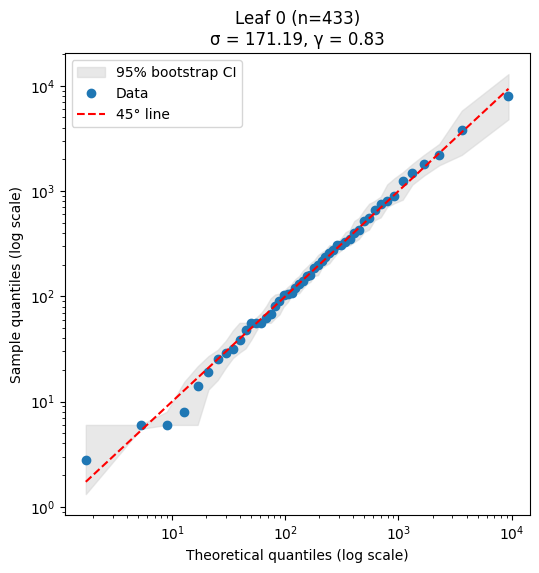

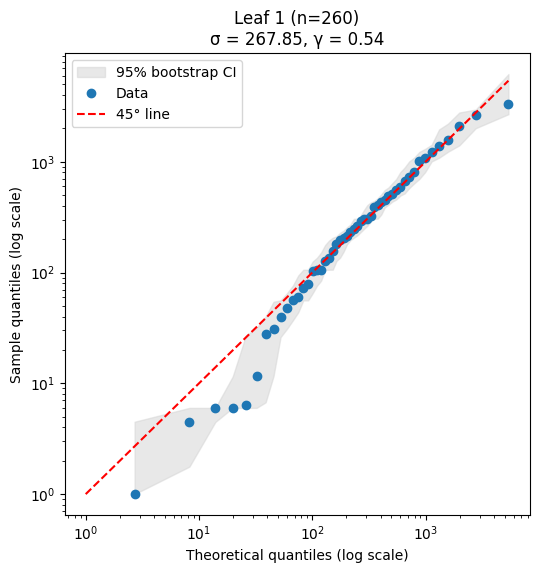

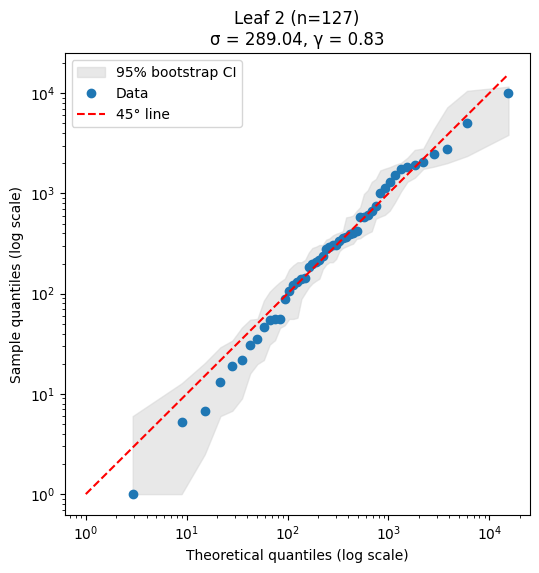

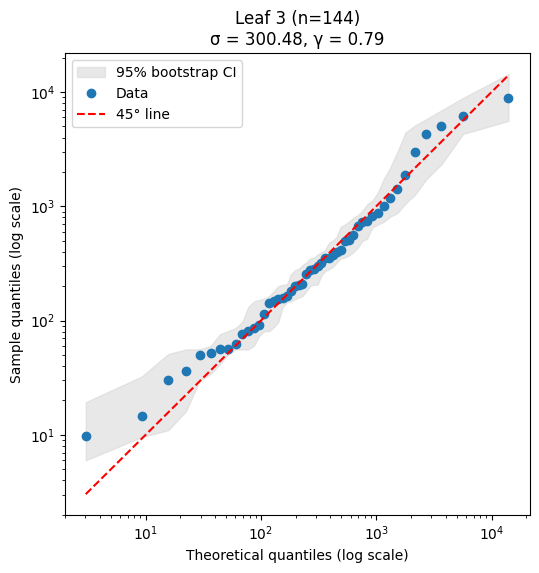

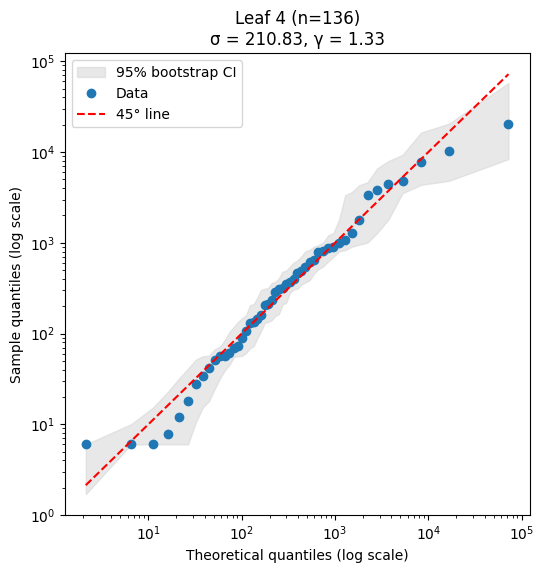

In [ ]:
graphs.plot_gp_tree_qq(gpd_tail_tree_pruned, X_tail, y_tail)


In [ ]:
importance=pd.DataFrame(importances)
importance.head()

,name,importance
0,Category_Damage to Physical Assets,0.001351
1,Category_Markets & Treasury,0.001326
2,Category_Banking,0.001150
3,Category_Manufacturing,0.000856
4,Category_Business Disruption and System Failures,0.000000


In [ ]:
# 모듈 헬퍼 준비
find_leaf = M.find_leaf
get_leaves = M._get_all_leaves

def _get_leaf_params(leaf):
    gp = getattr(leaf, "gpd_params", None)
    return (np.nan, np.nan) if gp is None else (float(gp[0]), float(gp[1]))

# CI 계산
cis = M.leaf_confidence_intervals(
    gpd_tail_tree_pruned, X_tail, y_tail,
    find_leaf=find_leaf, get_leaves=get_leaves, get_leaf_params=_get_leaf_params
)

# 보기 좋게 출력 (+ 리프별 샘플 수)
leaf_objs = np.array([find_leaf(gpd_tail_tree_pruned, X_tail[i]) for i in range(len(X_tail))], dtype=object)
leaves = get_leaves(gpd_tail_tree_pruned)

print("\n===== Leaf-wise γ 95% CI =====")
for i, rec in enumerate(cis):
    gamma = rec.get("gamma", np.nan)
    lo, hi = (rec.get("ci_95", [np.nan, np.nan]) + [np.nan, np.nan])[:2]
    n_i = int(np.sum(leaf_objs == leaves[i])) if i < len(leaves) else 0
    print(f"Leaf#{i:02d}  N={n_i:4d}   γ={gamma: .3f}   CI95=[{lo: .3f}, {hi: .3f}]")



===== Leaf-wise γ 95% CI =====
Leaf#00  N= 433   γ= 0.835   CI95=[ 0.658,  1.012]
Leaf#01  N= 260   γ= 0.535   CI95=[ 0.327,  0.744]
Leaf#02  N= 127   γ= 0.829   CI95=[ 0.482,  1.176]
Leaf#03  N= 144   γ= 0.789   CI95=[ 0.508,  1.070]
Leaf#04  N= 136   γ= 1.330   CI95=[ 0.913,  1.747]


In [ ]:
import numpy as np
import scipy.stats as st

def hill_ci(gamma_hat, n_exceed, alpha=0.05):
    """Asymptotic normal CI for Hill estimator"""
    se = gamma_hat / np.sqrt(n_exceed)
    z = st.norm.ppf(1 - alpha/2)
    return gamma_hat - z*se, gamma_hat + z*se

print("\n===== Leaf-wise γ 95% CI (Asymptotic) =====")
for i, rec in enumerate(cis):
    gamma = rec.get("gamma", np.nan)
    n_i = int(np.sum(leaf_objs == leaves[i])) if i < len(leaves) else 0
    if np.isnan(gamma) or n_i < 30:  # 샘플 적으면 skip
        lo, hi = np.nan, np.nan
    else:
        lo, hi = hill_ci(gamma, n_i, alpha=0.05)
    print(f"Leaf#{i:02d}  N={n_i:4d}   γ={gamma: .3f}   CI95=[{lo: .3f}, {hi: .3f}]")



===== Leaf-wise γ 95% CI (Asymptotic) =====
Leaf#00  N= 433   γ= 0.835   CI95=[ 0.756,  0.913]
Leaf#01  N= 260   γ= 0.535   CI95=[ 0.470,  0.600]
Leaf#02  N= 127   γ= 0.829   CI95=[ 0.685,  0.973]
Leaf#03  N= 144   γ= 0.789   CI95=[ 0.660,  0.918]
Leaf#04  N= 136   γ= 1.330   CI95=[ 1.106,  1.553]


##AIC

In [ ]:
# ================== POST-FIT EVAL: AIC/BIC, VaR, ES, GOF ==================

# ★ 1) raw y (초과치 아님) 준비
y_tail_raw = y_all_data[mask_tail]        # raw tail values
y_tail_excess = y_tail                    # (이미 있음) excess = y - u_threshold

# ★ 2) 네임스페이스 통일 (patched 모듈 함수 바인딩)
find_leaf_fn  = l1_l2_gpd_patched_new_catprune.find_leaf
get_leaves_fn = l1_l2_gpd_patched_new_catprune._get_all_leaves

# ★ 3) LN-only 트리도 patched 모듈로 생성 + 파라미터 부여
ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
    X_all_data, y_all_data, feature_names_list, min_leaf=30, max_depth=4
)
l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
    ln_only_tree, X_all_data, y_all_data, trunc_right=None
)

# 4) (선택) Bulk 모델로는 L2 트리 사용한 혼합 ln+gpd 성능을 보고 싶다면
tree_ln_for_mix  = l2_bulk_tree                      # bulk용 LN 트리
tree_gpd_for_mix = gpd_tail_tree_pruned              # tail용 GPD 트리 (없으면 None)

# 5) 모델 로그가능도/정보기준
ll_ln, k_ln, aic_ln, bic_ln = model_loglik_aic_bic(
    ln_only_tree, None,
    X_all_data, y_all_data,                      # LN-only: bulk=전체
    np.empty((0, X_all_data.shape[1])), np.empty(0),  # tail 없음
    u_threshold,
    find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
)

if tree_gpd_for_mix is not None:
    ll_mix, k_mix, aic_mix, bic_mix = model_loglik_aic_bic(
        tree_ln_for_mix, tree_gpd_for_mix,
        X_bulk, y_bulk,                         # bulk set
        X_tail, y_tail_raw,                     # ★ raw tail 필요!
        u_threshold,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
    )
else:
    ll_mix, k_mix, aic_mix, bic_mix = (np.nan, np.nan, np.nan, np.nan)

print(f"[LN Only]  logL={ll_ln:.1f}, k={k_ln}, AIC={aic_ln:.1f}, BIC={bic_ln:.1f}")
if tree_gpd_for_mix is not None:
    print(f"[LN+GPD]  logL={ll_mix:.1f}, k={k_mix}, AIC={aic_mix:.1f}, BIC={bic_mix:.1f}")
else:
    print("[LN+GPD]  (tail 표본 부족으로 GPD 트리 없음)")

# 6) VaR / ES
var_ln  = unconditional_var_ln(ln_only_tree, get_leaves=get_leaves_fn, alpha=0.99)
es_ln   = unconditional_es_ln(ln_only_tree,  get_leaves=get_leaves_fn, alpha=0.99)

if tree_gpd_for_mix is not None:
    var_mix = unconditional_var_mix(tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    es_mix  = unconditional_es_mix (tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    print(f"99% VaR | LN Only = {var_ln:,.0f}   LN+GPD = {var_mix:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}   LN+GPD = {es_mix:,.0f}")
else:
    print(f"99% VaR | LN Only = {var_ln:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}")

# 7) GPD 리프별 GOF (KS/AD) — excess 필요
if tree_gpd_for_mix is not None:
    gof_df = gpd_gof_leafwise(
        tree_gpd_for_mix, X_tail, y_tail_excess,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn, method="both"
    )
    pd.set_option('display.float_format', '{:,.3f}'.format)
    print("\n=== GPD Leaf-wise KS / AD Results ===")
    print(gof_df.to_string(index=False))


[LN Only]  logL=-79047.5, k=22, AIC=158139.1, BIC=158314.5
[LN+GPD]  logL=-79129.6, k=32, AIC=158323.1, BIC=158578.4
99% VaR | LN Only = 635   LN+GPD = 470
99% ES  | LN Only = 2,761   LN+GPD = inf

=== GPD Leaf-wise KS / AD Results ===
        leaf_id   n   sigma  gamma  KS stat  KS p  AD stat  AD p
140440541385920 136 210.834  1.330    0.058 0.725    0.655 0.087
140440541389632 433 171.195  0.835    0.033 0.720    0.529 0.179
140440541392576 144 300.485  0.789    0.057 0.716    0.592 0.125
140440541393344 260 267.855  0.535    0.074 0.110    2.293 0.000
140440541394240 127 289.040  0.829    0.072 0.507    0.822 0.034


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# ──────────────────────────────────────────────
# 0) Monte-Carlo 기반 VaR/ES 계산 (ppf 사용 안 함)
# ──────────────────────────────────────────────
def mc_var_es(dist, params, alpha=0.99, n_mc=300_000, random_state=42):
    """
    dist   : scipy.stats 배포( .rvs 가능 )
    params : dist.fit(...) 결과 파라미터 (튜플)
    alpha  : 신뢰수준 (예: 0.99)
    n_mc   : MC 표본 수
    """
    rng = np.random.default_rng(random_state)
    samples = dist.rvs(*params, size=n_mc, random_state=rng)

    # 샘플 기반 VaR/ES
    var_alpha = np.quantile(samples, alpha)
    tail = samples[samples >= var_alpha]
    # tail이 비면 방어적 처리
    if tail.size == 0:
        k = max(1, int(np.ceil(0.001 * n_mc)))
        tail = np.partition(samples, -k)[-k:]
    es_alpha = float(tail.mean())
    return float(var_alpha), es_alpha

# ──────────────────────────────────────────────
# 1) 적합 + AIC/BIC + (MC) VaR + (MC) ES
# ──────────────────────────────────────────────
def fit_score_var_es(dist, data, name,
                     fix_loc0=True,    # NIG에는 False 권장
                     alpha=0.99,
                     n_es_mc=300_000,
                     random_state=42):
    """
    dist, data, name, alpha 동일.
    n_es_mc : ES/ VaR 추정을 위한 MC 표본 수
    """
    try:
        data = np.asarray(data, dtype=float)
        data = data[np.isfinite(data)]
        if data.size == 0:
            raise ValueError("No valid data points.")

        # ① 분포 적합 (MLE)
        if fix_loc0:
            params = dist.fit(data, floc=0)   # loc을 0으로 고정 (NIG에는 비권장)
            k = len(params) - 1
        else:
            params = dist.fit(data)           # loc/scale/shape 모두 추정
            k = len(params)

        # ② 로그 가능도
        logpdf = dist.logpdf(data, *params)
        logpdf = logpdf[np.isfinite(logpdf)]
        logL   = float(logpdf.sum())
        n      = int(data.size)

        # ③ AIC / BIC
        aic = 2*k - 2*logL
        bic = np.log(n)*k - 2*logL

        # ④~⑤ VaR/ES (모두 MC로 계산 → ppf 사용 안 함)
        var_alpha, es_alpha = mc_var_es(dist, params, alpha, n_es_mc, random_state)

        return {
            "Distribution": name,
            "Log-Likelihood": logL,
            "AIC": aic,
            "BIC": bic,
            f"VaR {int(alpha*100)}%": var_alpha,
            f"ES  {int(alpha*100)}%": es_alpha
        }

    except Exception as e:
        return {
            "Distribution": name,
            "Log-Likelihood": f"Fit failed: {e}",
            "AIC": np.nan,
            "BIC": np.nan,
            f"VaR {int(alpha*100)}%": np.nan,
            f"ES  {int(alpha*100)}%": np.nan
        }

# ──────────────────────────────────────────────
# 2) 후보 분포 지정 & 실행
# ──────────────────────────────────────────────
candidates = {
    "Log-Normal":     (stats.lognorm,     True),
    "Gamma":          (stats.gamma,       True),
    "Weibull":        (stats.weibull_min, True),
    # NIG는 scipy.stats.norminvgauss (shape: a, b; loc, scale)
    # ★ floc=0 고정하지 마세요 → 수치 불안정 완화
    "NIG":            (stats.norminvgauss, False),
}

alpha = 0.99
results = [fit_score_var_es(dist, y_all_data, name,
                            fix_loc0=fix_loc0,   # NIG는 False
                            alpha=alpha,
                            n_es_mc=300_000,
                            random_state=42)
           for name, (dist, fix_loc0) in candidates.items()]

results_df = (pd.DataFrame(results)
                .sort_values("AIC", key=lambda s: s.fillna(np.inf))
                .reset_index(drop=True))

print(results_df)


  Distribution  Log-Likelihood         AIC         BIC   VaR 99%   ES  99%
0   Log-Normal     -80,961.164 161,926.328 161,942.280   595.305 1,805.594
1          NIG     -82,196.707 164,401.415 164,433.319 1,379.933 3,511.355
2      Weibull     -84,044.929 168,093.858 168,109.811   437.448   700.840
3        Gamma     -89,332.277 178,668.554 178,684.507   608.906   810.125



================  Model Comparison  ================

  Distribution  Log-Likelihood         AIC         BIC   VaR 99%   ES  99%  \
0       LN+GPD     -79,129.558 158,323.116 158,578.352   469.603       inf   
1   Log-Normal     -80,961.164 161,926.328 161,942.280   595.305 1,805.594   
2          NIG     -82,196.707 164,401.415 164,433.319 1,379.933 3,511.355   
3      Weibull     -84,044.929 168,093.858 168,109.811   437.448   700.840   
4        Gamma     -89,332.277 178,668.554 178,684.507   608.906   810.125   

       k  
0 32.000  
1    NaN  
2    NaN  
3    NaN  
4    NaN  


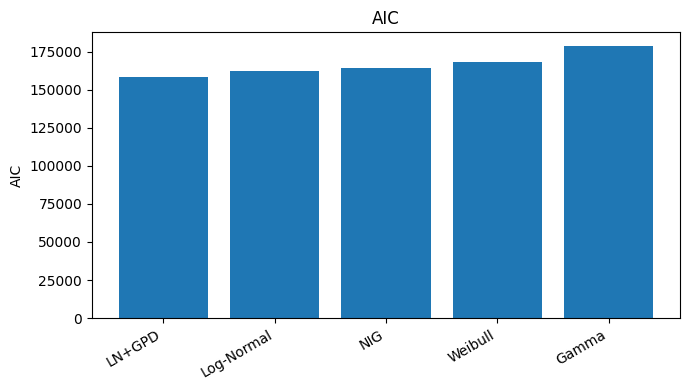

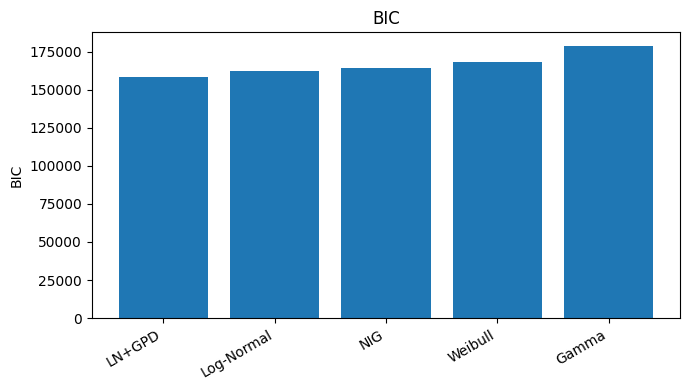

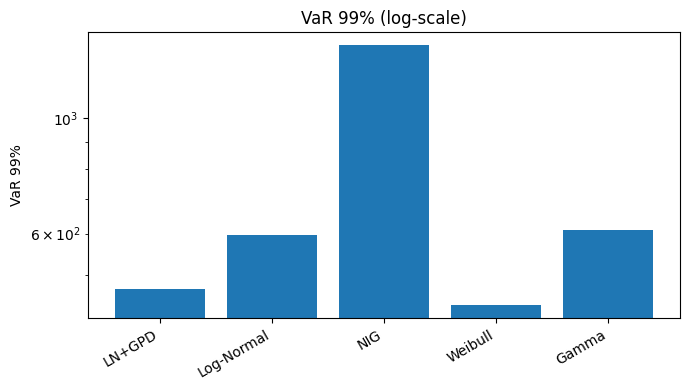

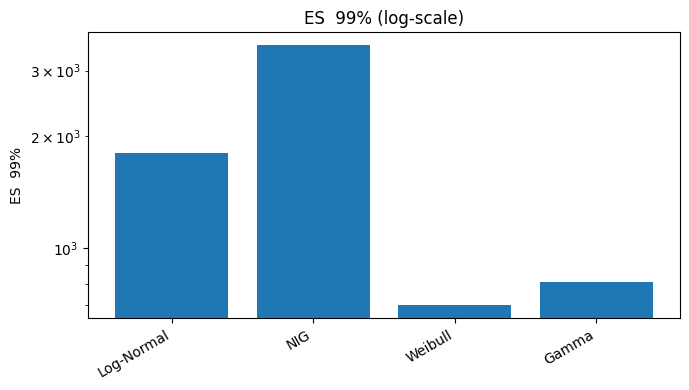

In [ ]:
# ──────────────────────────────────────────────
# 0) Tree 모델 행을 만들어 results_df 와 합치기
# ──────────────────────────────────────────────
tree_rows = pd.DataFrame([
#    {"Distribution": "LN‑Tree",  "Log-Likelihood": ll_ln,  "k": k_ln,
#     "AIC": aic_ln,  "BIC": bic_ln,
 #    "VaR 99%": var_ln,  "ES  99%": es_ln},
    {"Distribution": "LN+GPD",   "Log-Likelihood": ll_mix, "k": k_mix,
     "AIC": aic_mix, "BIC": bic_mix,
     "VaR 99%": var_mix, "ES  99%": es_mix}
])

full_df = (pd.concat([results_df, tree_rows], ignore_index=True)
             .sort_values("AIC")
             .reset_index(drop=True))

print("\n================  Model Comparison  ================\n")
print(full_df)

# ──────────────────────────────────────────────
# 1) AIC / BIC   (로그축 X)
# ──────────────────────────────────────────────
import matplotlib.pyplot as plt

for metric in ["AIC", "BIC"]:
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], full_df[metric])
    plt.title(f"{metric}")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

# ──────────────────────────────────────────────
# 2) VaR / ES   (log‑scale로 값 차이를 보기 좋게)
# ──────────────────────────────────────────────
for metric in ["VaR 99%", "ES  99%"]:
    y = pd.to_numeric(full_df[metric], errors="coerce").to_numpy(dtype=float)
    y_plot = np.where(np.isfinite(y) & (y > 0), y, np.nan)  # 🔧 inf/<=0 → NaN
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], y_plot)
    plt.yscale("log")
    plt.title(f"{metric} (log-scale)")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()



In [ ]:
import pickle

# --- __main__ 블록 마지막에 추가 ---
save_path = '/content/drive/MyDrive/Operational_risk/'
# 1) 저장할 객체들 모으기
output = {
    # Bulk 트리
    'l1_bulk_tree' : l1_bulk_tree,
    'l2_bulk_tree' : l2_bulk_tree,
    # Tail 트리
    'gpd_raw_tree' : gpd_tail_tree_raw,
    'gpd_pruned_tree' : gpd_tail_tree_pruned,
    # 데이터
    'X_bulk'       : X_bulk,
    'y_bulk'       : y_bulk,
    'X_tail'       : X_tail,
    'y_tail'       : y_tail,
    'X_all_data'   : X_all_data,
    'y_all_data'   : y_all_data,
    'df_model_ready':df_model_ready,
    # (선택) 피처 이름
    'feature_names': feature_names_list,
    # (선택) 임계값
    'u_threshold'  : u_threshold
}

# 2) 피클 파일로 저장
with open(save_path + 'EPU_Total.pkl', 'wb') as f:
    pickle.dump(output, f)



#Category by Loss

In [ ]:
df=df1.copy()

In [ ]:
us_df = df[df['Country of Incident'] == 'United States']
loss_df = us_df[['First Year of Event','Industry Sector Code','Basel Business Line - Level 2','Event Risk Category','Loss Amount ($M)']].copy()
loss_df.rename(columns={'First Year of Event':'Date', 'Loss Amount ($M)':'Current Value of Loss'}, inplace=True)
loss_df['Date'] = pd.to_datetime(loss_df['Date']).dt.strftime('%Y')
loss_df.sort_values(by='Date', inplace=True)
loss_df = loss_df[loss_df['Date'] >= '1979']


In [ ]:
loss_df_finance=loss_df

In [ ]:
loss_df['Event Risk Category'].unique()

array(['Clients, Products & Business Practices',
       'Employment Practices and Workplace Safety',
       'Damage to Physical Assets', 'Internal Fraud', 'External Fraud',
       'Execution, Delivery & Process Management',
       'Business Disruption and System Failures'], dtype=object)

In [ ]:
loss_df_finance.rename(columns={"Basel Business Line - Level 2":"Business"},inplace=True)
loss_df_finance.drop(columns=['Industry Sector Code'],inplace=True)

In [ ]:
import re
import pandas as pd

# 입력 컬럼
SOURCE_COL = 'Business'

def _norm(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    # 정규화: & -> and, / -> space, -, , -> space, 괄호 제거, 다중공백 축소
    s = s.replace('&', ' and ')
    s = re.sub(r'[\/,\-]', ' ', s)
    s = re.sub(r'[\(\)\[\]]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    # 특수 케이스 보정
    s = s.replace('foodservices', 'food services')
    s = s.replace('non discretionary', 'non-discretionary')
    return s

# -------------------------------
# 1) 금융 도메인 상위 라인 매핑
# -------------------------------
FIN_MAP = {
    # Banking
    'retail banking': 'Banking',
    'commercial banking': 'Banking',
    'private banking': 'Banking',
    'card services': 'Banking',
    # Markets & Treasury
    'market making': 'Markets & Treasury',
    'sales': 'Markets & Treasury',
    'proprietary positions': 'Markets & Treasury',
    'treasury': 'Markets & Treasury',
    # Investment Banking
    'corporate finance': 'Investment Banking',
    'municipal government finance': 'Investment Banking',  # 슬래시 정규화 반영
    # Brokerage & Advisory
    'retail brokerage': 'Brokerage & Advisory',
    'brokerage and advisory': 'Brokerage & Advisory',
    'advisory services': 'Brokerage & Advisory',
    # Asset & Wealth Mgmt
    'discretionary fund management': 'Asset & Wealth Mgmt',
    'non-discretionary fund management': 'Asset & Wealth Mgmt',
    'merchant banking': 'Asset & Wealth Mgmt',
    # Asset Servicing & Trust
    'custody': 'Asset Servicing & Trust',
    'corporate trust': 'Asset Servicing & Trust',
    # Insurance
    'property and casualty insurance': 'Insurance',
    'life insurance and benefit plans': 'Insurance',
    'health insurance': 'Insurance',
    'reinsurance': 'Insurance',
    'corporate agency': 'Insurance',
    'professional liability fidelity coverage': 'Insurance',
    # Others
    'external clients': 'Others',
    'others': 'Others',
}

# -------------------------------
# 2) 비금융(NAICS류) 상위 그룹 매핑
# -------------------------------
NONFIN_MAP = {
    'manufacturing': 'Manufacturing',
    'construction': 'Construction',
    'utilities': 'Utilities',
    'mining': 'Mining',
    'retail trade': 'Retail Trade',
    'wholesale trade': 'Wholesale Trade',
    'transportation and warehousing': 'Transportation & Warehousing',
    'information': 'Information',
    'educational services': 'Educational Services',
    'health care and social assistance': 'Health Care & Social Assistance',
    'agriculture forestry fishing and hunting': 'Agriculture, Forestry, Fishing & Hunting',
    'real estate rental and leasing': 'Real Estate, Rental & Leasing',
    'accommodation and food services': 'Accommodation & Food Services',
    'arts entertainment and recreation': 'Arts, Entertainment & Recreation',
    'public administration': 'Public Administration',
    'professional scientific and technical services': 'Professional Services',
    'administrative and support waste management and remediation services': 'Admin & Support, Waste Mgmt',
    'management of companies and enterprises': 'Mgmt of Companies & Enterprises',
    'other services except public administration': 'Other Services',
    'non-profit organizations': 'Non-Profit',
}

# -------------------------------
# 3) 키워드 휴리스틱 (미지정 값 보조 분류)
# -------------------------------
def _heuristic_fin(key: str):
    if any(w in key for w in ['bank', 'card']):
        return 'Banking'
    if any(w in key for w in ['market making', 'treasury', 'proprietary', 'sales']):
        return 'Markets & Treasury'
    if any(w in key for w in ['broker', 'advisory']):
        return 'Brokerage & Advisory'
    if any(w in key for w in ['fund', 'asset', 'merchant banking', 'wealth']):
        return 'Asset & Wealth Mgmt'
    if any(w in key for w in ['custody', 'trust']):
        return 'Asset Servicing & Trust'
    if 'insurance' in key or 'reinsurance' in key or 'liability' in key:
        return 'Insurance'
    if 'finance' in key:
        return 'Investment Banking'
    return None

def _heuristic_nonfin(key: str):
    # 순서 중요(특정성이 높은 것부터)
    if 'retail trade' in key or (('retail' in key) and ('trade' in key)):
        return 'Retail Trade'
    if 'wholesale' in key:
        return 'Wholesale Trade'
    if 'manufactur' in key:
        return 'Manufacturing'
    if 'construction' in key:
        return 'Construction'
    if 'transportation' in key or 'warehousing' in key:
        return 'Transportation & Warehousing'
    if 'utilities' in key:
        return 'Utilities'
    if any(w in key for w in ['agriculture','forestry','fishing','hunting']):
        return 'Agriculture, Forestry, Fishing & Hunting'
    if 'information' in key:
        return 'Information'
    if 'educational' in key or 'education' in key:
        return 'Educational Services'
    if 'health care' in key or 'social assistance' in key or 'healthcare' in key:
        return 'Health Care & Social Assistance'
    if 'real estate' in key or 'rental' in key or 'leasing' in key:
        return 'Real Estate, Rental & Leasing'
    if 'accommodation' in key or 'food services' in key:
        return 'Accommodation & Food Services'
    if any(w in key for w in ['arts','entertainment','recreation']):
        return 'Arts, Entertainment & Recreation'
    if 'public administration' in key:
        return 'Public Administration'
    if 'professional scientific' in key or 'technical services' in key:
        return 'Professional Services'
    if 'administrative and support' in key or 'waste management' in key or 'remediation' in key:
        return 'Admin & Support, Waste Mgmt'
    if 'management of companies' in key:
        return 'Mgmt of Companies & Enterprises'
    if 'non profit' in key or 'nonprofit' in key:
        return 'Non-Profit'
    if 'other services' in key:
        return 'Other Services'
    return None

# -------------------------------
# 4) 최종 분류 함수
# -------------------------------
def classify_sector_and_line(val):
    key = _norm(val)
    if key is None or key == '':
        return pd.Series(['Unknown', 'Others'])

    # 1) 직접 매핑
    if key in FIN_MAP:
        return pd.Series(['Finance', FIN_MAP[key]])
    if key in NONFIN_MAP:
        return pd.Series(['Non-Finance', NONFIN_MAP[key]])

    # 2) 휴리스틱(금융 → 비금융 순서)
    fin_guess = _heuristic_fin(key)
    if fin_guess:
        return pd.Series(['Finance', fin_guess])
    nonfin_guess = _heuristic_nonfin(key)
    if nonfin_guess:
        return pd.Series(['Non-Finance', nonfin_guess])

    # 3) 최종 기본값
    return pd.Series(['Unknown', 'Others'])

# 적용: 두 컬럼 생성
loss_df_finance[['SectorType', 'Business_line']] = (
    loss_df_finance[SOURCE_COL].apply(classify_sector_and_line)
)


In [ ]:
loss_df_finance=loss_df_finance.drop(columns=['Business','SectorType'])

In [ ]:
loss_df_finance['Business_line'].value_counts()

,count
Business_line,
Manufacturing,4957
Banking,4891
Insurance,1968
Brokerage & Advisory,1598
Markets & Treasury,1230
Information,959
Utilities,958
Health Care & Social Assistance,816
Retail Trade,709


In [ ]:
loss_df_finance['Event Risk Category'].value_counts()

,count
Event Risk Category,
"Clients, Products & Business Practices",12355
Damage to Physical Assets,3132
External Fraud,2835
Internal Fraud,2667
Employment Practices and Workplace Safety,1358
"Execution, Delivery & Process Management",846
Business Disruption and System Failures,105


##Banking

In [ ]:
loss_business_line = loss_df_finance[['Date', 'Current Value of Loss', 'Business_line']]

loss_by_business = (
    loss_business_line
    .groupby('Business_line', as_index=False)
    .agg({'Current Value of Loss': 'sum'}).sort_values('Current Value of Loss',ascending=False)  # Date 제외
)

print(loss_by_business)


                               Business_line  Current Value of Loss
14                             Manufacturing          408048.336600
6                                    Banking          244757.059903
15                        Markets & Treasury          187109.660354
17                                    Mining           87567.747000
12                                 Insurance           82097.384000
26                                 Utilities           69634.625000
11                               Information           69519.931000
4                        Asset & Wealth Mgmt           60363.880000
7                       Brokerage & Advisory           38945.919138
20                                    Others           37755.515000
13                        Investment Banking           32326.020000
21                     Professional Services           32234.573012
10           Health Care & Social Assistance           25834.333000
24                              Retail Trade    

In [ ]:
loss_manufacturing= loss_df_finance[loss_df_finance['Business_line'] == 'Banking'].copy()


In [ ]:
loss_manufacturing.head()

,Date,Event Risk Category,Current Value of Loss,Business_line
1799,1979,"Clients, Products & Business Practices",4.0,Banking
1282,1979,Internal Fraud,1.2,Banking
1654,1979,Internal Fraud,6.2,Banking
1707,1979,"Clients, Products & Business Practices",3.0,Banking
7302,1979,"Clients, Products & Business Practices",4.5,Banking


In [ ]:
loss_manufacturing['Event Risk Category'].value_counts()

,count
Event Risk Category,
External Fraud,1880
"Clients, Products & Business Practices",1449
Internal Fraud,1282
Employment Practices and Workplace Safety,131
"Execution, Delivery & Process Management",103
Damage to Physical Assets,40
Business Disruption and System Failures,6


In [ ]:
loss_manufacturing.head()

,Date,Event Risk Category,Current Value of Loss,Business_line
1799,1979,"Clients, Products & Business Practices",4.0,Banking
1282,1979,Internal Fraud,1.2,Banking
1654,1979,Internal Fraud,6.2,Banking
1707,1979,"Clients, Products & Business Practices",3.0,Banking
7302,1979,"Clients, Products & Business Practices",4.5,Banking


In [ ]:
# Encode 'Event Risk Category'
df_encoded_a = pd.get_dummies(loss_manufacturing, columns=['Event Risk Category'], prefix='Category')

# Use the result of the first encoding as input for the second encoding


# Final encoded DataFrame
loss_manufacturing = df_encoded_a.copy()


In [ ]:
loss_manufacturing.drop(columns=['Business_line'],inplace=True)
loss_manufacturing.head()

,Date,Current Value of Loss,Category_Business Disruption and System Failures,"Category_Clients, Products & Business Practices",Category_Damage to Physical Assets,Category_Employment Practices and Workplace Safety,"Category_Execution, Delivery & Process Management",Category_External Fraud,Category_Internal Fraud
1799,1979,4.0,False,True,False,False,False,False,False
1282,1979,1.2,False,False,False,False,False,False,True
1654,1979,6.2,False,False,False,False,False,False,True
1707,1979,3.0,False,True,False,False,False,False,False
7302,1979,4.5,False,True,False,False,False,False,False


In [ ]:
import re

# ① CSV 읽기
cpu = pd.read_csv('/content/drive/MyDrive/CPU index.csv')[['date', 'cpu_index']]

# ② 전처리 ── 공백 제거
cpu['date'] = cpu['date'].str.strip()

# ③ 'YY-Mon' → 'Mon-YY' 로 재배열
cpu['date'] = cpu['date'].str.replace(
    r'^(\d{2})-([A-Za-z]{3})$',   # 2자리 연도-3자리 월
    r'\2-\1',                     # 월-연도로 바꾸기
    regex=True, flags=re.IGNORECASE
)

# ④ datetime 파싱
cpu['date'] = pd.to_datetime(cpu['date'], format='%b-%y', errors='coerce')

# ⑤ 원하는 포맷(문자열)으로 출력하거나, 월 Period 로도 사용 가능
cpu['date'] = cpu['date'].dt.strftime('%Y-%m')      # 문자열 형태


In [ ]:
import pandas as pd
import numpy as np
from functools import reduce

file_paths = {
    "us_cpi": "/content/drive/MyDrive/us_cpi.csv",
    "us_unemp": "/content/drive/MyDrive/us_unemp.csv",
    "us_vix": "/content/drive/MyDrive/us_vix.csv",
    "us_m2": "/content/drive/MyDrive/us_m2.csv",
    "us_home_price": "/content/drive/MyDrive/us_home price index.csv",
    "us_T10Y2Y": "/content/drive/MyDrive/us_T10Y2Y.csv",
    "sp500": "/content/drive/MyDrive/sp500_monthly.csv",
}

# Load
us_cpi = pd.read_csv(file_paths["us_cpi"])
us_unemp = pd.read_csv(file_paths["us_unemp"])
us_m2 = pd.read_csv(file_paths["us_m2"])
us_home_price = pd.read_csv(file_paths["us_home_price"])
us_T10Y2Y = pd.read_csv(file_paths["us_T10Y2Y"])
sp500 = pd.read_csv(file_paths["sp500"], skiprows=2)

# Rename columns
us_T10Y2Y.rename(columns={'T10Y2Y': '10_2'}, inplace=True)
us_home_price.rename(columns={'USSTHPI': 'House Price Index'}, inplace=True)
us_m2.rename(columns={'WM2NS': 'M2'}, inplace=True)
us_cpi.rename(columns={'CPIAUCSL': 'CPI'}, inplace=True)
us_unemp.rename(columns={'UNRATE': 'Unemployment Rate'}, inplace=True)
sp500.rename(columns={'Unnamed: 1': 'Close'}, inplace=True)
sp500 = sp500.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4", "Unnamed: 5"])
cpu.rename(columns={'date': 'Date'}, inplace=True)


# Date 처리 및 연 단위 평균
for df in [us_cpi, us_unemp, us_m2, us_home_price, us_T10Y2Y, sp500,cpu]:
    df.rename(columns={df.columns[0]: "Date"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"]).dt.year

us_T10Y2Y = us_T10Y2Y.groupby("Date").mean().reset_index()
us_home_price = us_home_price.groupby("Date").mean().reset_index()
us_m2 = us_m2.groupby("Date").mean().reset_index()
us_cpi = us_cpi.groupby("Date").mean().reset_index()
us_unemp = us_unemp.groupby("Date").mean().reset_index()
sp500 = sp500.groupby("Date").mean().reset_index()
cpu = cpu.groupby("Date").mean().reset_index()


# log-diff 처리
macro_dfs = {

    'Close_diff': (sp500, 'Close'),
}

# diff 열 추가
for diff_col, (df, col) in macro_dfs.items():
    df[diff_col] = np.log(df[col]).diff()

# sp500의 첫 번째 NaN만 특정 값으로 채움
sp500['Close_diff'].fillna(0.1635259493925565, inplace=True)

# 병합
dfs = [us_T10Y2Y, us_home_price, us_m2, us_cpi, us_unemp, sp500,cpu]
df_merged_macro = reduce(lambda left, right: pd.merge(left, right, on="Date", how="inner"), dfs)

# 최종 lag 데이터
df_merged_macro_lag = df_merged_macro[df_merged_macro["Date"] >= 1980].copy()
df_merged_macro_lag['Date'] = df_merged_macro_lag['Date'].astype(str)


/tmp/ipython-input-3402856144.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sp500['Close_diff'].fillna(0.1635259493925565, inplace=True)


In [ ]:
import numpy as np
import pandas as pd
from functools import reduce
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import minimize
from scipy.stats import genpareto
import copy
#1986부터 사용
#############################################
# 1. 데이터 전처리 (연 단위)
#############################################
# (1) 엑셀 파일 읽기 및 날짜 정리
# 실제 파일 경로로 수정하세요.

epu_kr_path = '/content/drive/MyDrive/Korea_Overall_EPU.xlsx'
epu_kr_cat_path = '/content/drive/MyDrive/Korea_Categorical_PU_Indices.xlsx'
epu_usa_path = '/content/drive/MyDrive/US_Policy_Uncertainty_Data.xlsx'
epu_usa_cat_path = '/content/drive/MyDrive/Categorical_EPU_Data.xlsx'


# 미국 EPU 데이터
epu_usa = pd.read_excel(epu_usa_path)
epu_usa_cat = pd.read_excel(epu_usa_cat_path)
# 연도만 추출 (datetime 변환 후 정수형으로)
epu_usa['Year'] = pd.to_datetime(epu_usa['Year'], format='%Y').dt.year.astype(int)
epu_usa_cat['Year'] = pd.to_datetime(epu_usa_cat['Year'], format='%Y').dt.year.astype(int)
# 연도 필터링 (1985~2022)
epu_usa_cl = epu_usa[(epu_usa['Year'] < 2023)].copy()
epu_usa_cat_cl = epu_usa_cat[ (epu_usa_cat['Year'] < 2023)].copy()
# 최종적으로 'Date' 컬럼에 연도만(문자형) 저장
epu_usa_cl['Date'] = epu_usa_cl['Year'].astype(str)
epu_usa_cat_cl['Date'] = epu_usa_cat_cl['Year'].astype(str)
epu_usa_cl_lag = epu_usa_cl.copy()
epu_usa_cat_cl_lag = epu_usa_cat_cl.copy()


epu_usa_cl['Date'] = epu_usa_cl['Year'].astype(str)

epu_overall = (
    epu_usa_cl
    .groupby('Date')[['Three_Component_Index','News_Based_Policy_Uncert_Index']]
    .mean()
    .reset_index()
)

# 2) 범주형 EPU 연평균 집계
# ————————
cat_cols = [
    '1. Economic Policy Uncertainty','2. Monetary policy',
    'Fiscal Policy (Taxes OR Spending)','3. Taxes',
    '4. Government spending','5. Health care',
    '6. National security','7. Entitlement programs',
    '8. Regulation','Financial Regulation',
    '9. Trade policy','10. Sovereign debt, currency crises'
]
epu_usa_cat_cl['Date'] = epu_usa_cat_cl['Year'].astype(str)

epu_cats = (
    epu_usa_cat_cl
    .groupby('Date')[cat_cols]
    .mean()
    .reset_index()
)

# 3) 매크로 + EPU(전체+범주) 병합
# ———————————————
df_macro_epu = (
    df_merged_macro_lag
    .merge(epu_overall, on='Date', how='inner')
    .merge(epu_cats,    on='Date', how='inner')
)

# 4) 최종: 이벤트 손실(≈433행)과 1:1 병합
# ——————————————————————
final_df = df_macro_epu.merge(loss_manufacturing, on='Date', how='inner')




In [ ]:
df_merged=final_df.copy()
df_merged['Exceedance']=df_merged['Current Value of Loss']

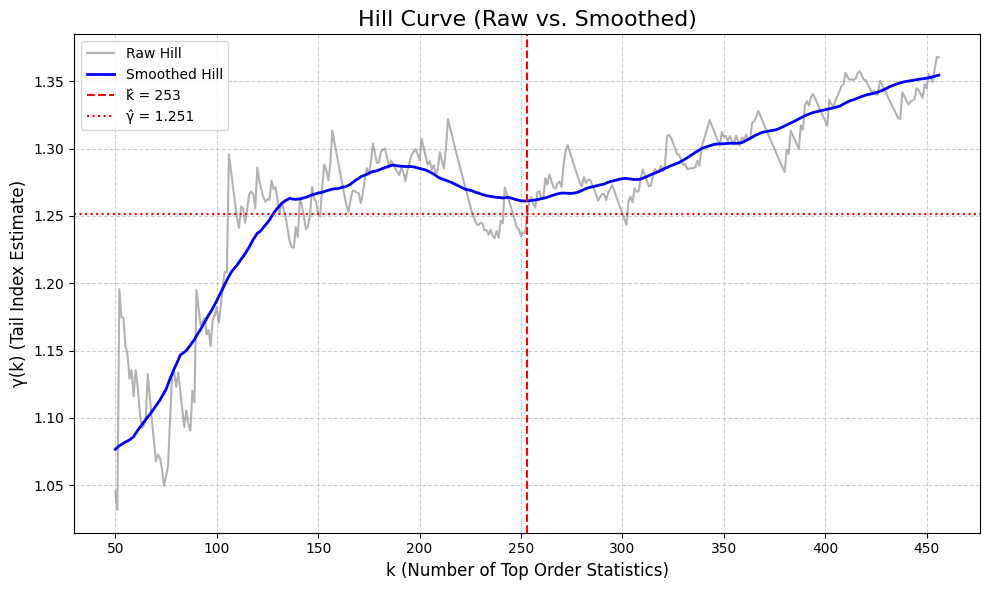

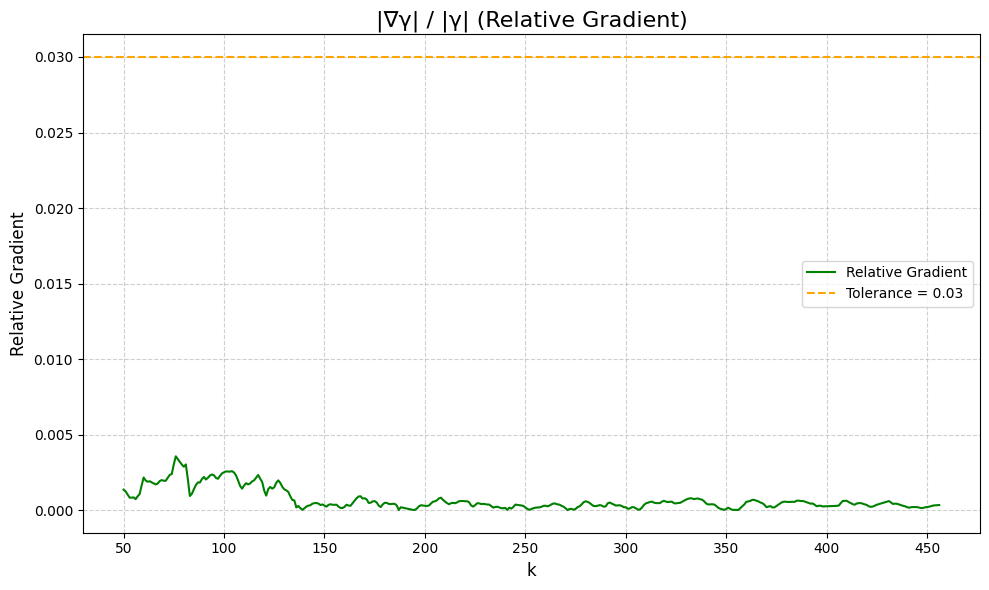

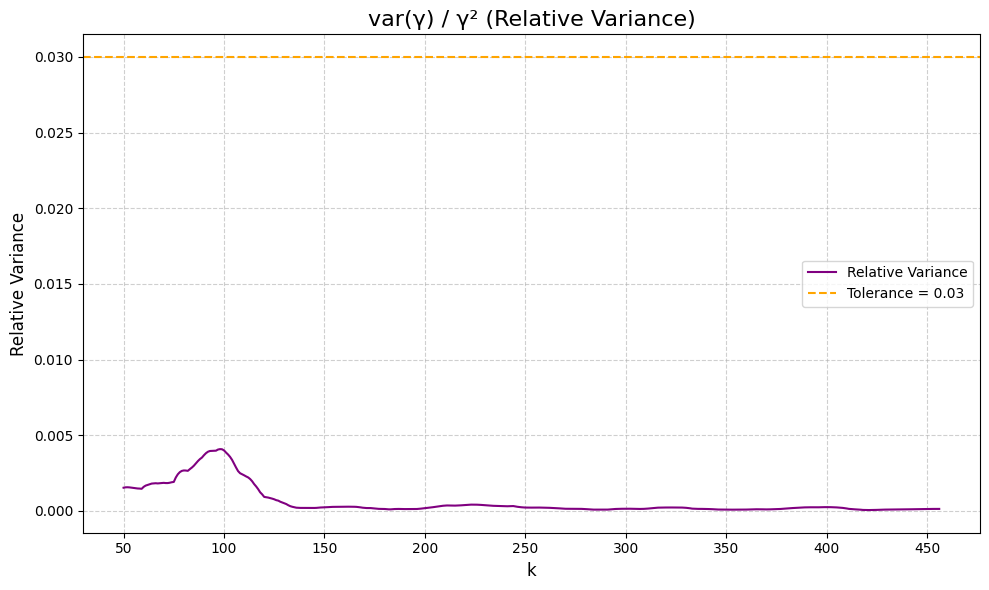

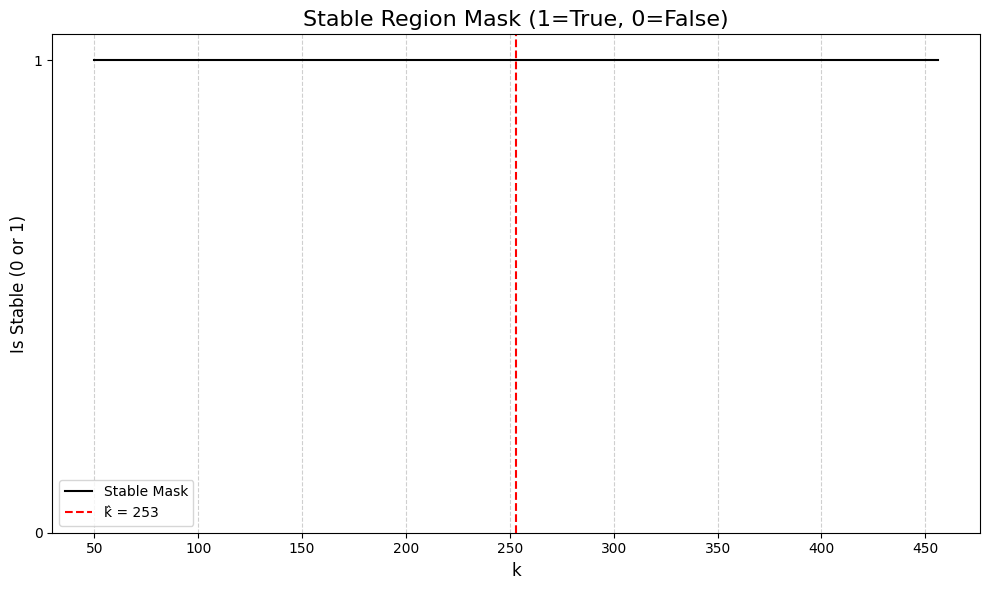


--- Results ---
Estimated Threshold (u_hat): 86.9600
Number of Exceedances (k_hat): 253
Estimated Tail Index (gamma_hat): 1.2511
----------------


In [ ]:
# hill_plots.py ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple, Dict, Any

# It's assumed that the 'thresholding' module you created is in the same folder.
from hill_plot_new_patched import select_threshold, HillDiag

def _compute_hill_raw_curve(y: np.ndarray, ks: np.ndarray) -> np.ndarray:
    """
    Computes the raw (unsmoothed) Hill curve.
    γ_k = mean( log Y_(1..k) - log Y_(k+1) ), where Y are sorted positive values.
    """
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    y_desc = np.sort(y)[::-1]
    y_pos = y_desc[y_desc > 0]
    if y_pos.size < 2 or ks.size == 0: # Need at least 2 points to compute log-differences
        return np.array([])

    # Ensure k does not exceed valid index
    max_k = y_pos.size - 1
    valid_ks = ks[ks < max_k]
    if valid_ks.size == 0:
        return np.array([])

    return np.array([np.mean(np.log(y_pos[:k]) - np.log(y_pos[k])) for k in valid_ks], dtype=float)

def plot_hill_curve(
    y: np.ndarray,
    diag: HillDiag,
    k_hat: int,
    gamma_hat: float,
    *,
    title: str = "Hill Curve (Raw vs. Smoothed)",
) -> None:
    """
    Plots the Hill curve (raw vs. smoothed) and the estimated point (k_hat, gamma_hat).
    """
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot Hill curve.")
        return

    gamma_raw = _compute_hill_raw_curve(y, diag.k_grid)

    plt.figure(figsize=(10, 6))
    if gamma_raw.size:
        # Match raw curve to its valid k-grid
        max_k_raw = y.size - 1
        valid_ks_raw = diag.k_grid[diag.k_grid < max_k_raw]
        plt.plot(valid_ks_raw, gamma_raw, label="Raw Hill", alpha=0.6, color='gray')

    plt.plot(diag.k_grid, diag.gamma_hat, label="Smoothed Hill", color='blue', linewidth=2)
    plt.axvline(k_hat, linestyle="--", color='red', label=f"k̂ = {k_hat}")
    plt.axhline(gamma_hat, linestyle=":", color='red', label=f"γ̂ = {gamma_hat:.3f}")

    plt.title(title, fontsize=16)
    # CHANGED: Korean -> English
    plt.xlabel("k (Number of Top Order Statistics)", fontsize=12)
    plt.ylabel("γ(k) (Tail Index Estimate)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_grad_norm(
    diag: HillDiag,
    *,
    rel_grad_tol: float,
    title: str = "|∇γ| / |γ| (Relative Gradient)"
) -> None:
    """Plots the relative gradient and the tolerance line."""
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot grad_norm.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(diag.k_grid, diag.grad_norm, label="Relative Gradient", color='green')
    plt.axhline(rel_grad_tol, linestyle="--", color='orange', label=f"Tolerance = {rel_grad_tol}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Relative Gradient", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_var_rel(
    diag: HillDiag,
    *,
    rel_var_tol: float,
    title: str = "var(γ) / γ² (Relative Variance)"
) -> None:
    """Plots the relative variance and the tolerance line."""
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot var_rel.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(diag.k_grid, diag.var_rel, label="Relative Variance", color='purple')
    plt.axhline(rel_var_tol, linestyle="--", color='orange', label=f"Tolerance = {rel_var_tol}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Relative Variance", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_stable_mask(
    diag: HillDiag,
    *,
    rel_grad_tol: float,
    rel_var_tol: float,
    gamma_min: float,
    k_hat: int,
    title: str = "Stable Region Mask (1=True, 0=False)"
) -> None:
    """
    Visualizes the stable region mask:
    stable = (grad_norm < rel_grad_tol) & (var_rel < rel_var_tol) & (gamma_hat > gamma_min)
    """
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot stable mask.")
        return

    stable = (diag.grad_norm < rel_grad_tol) & (diag.var_rel < rel_var_tol) & (diag.gamma_hat > gamma_min)

    plt.figure(figsize=(10, 6))
    plt.step(diag.k_grid, stable.astype(int), where="mid", label="Stable Mask", color='black')
    plt.axvline(k_hat, linestyle="--", color='red', label=f"k̂ = {k_hat}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Is Stable (0 or 1)", fontsize=12)
    plt.yticks([0, 1])
    plt.legend()
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_hill_diagnostics(
    y: np.ndarray,
    *,
    # Parameters for thresholding._auto_hill
    k_min: int = 50,
    k_max_prop: float = 0.1,
    window: int = 61,
    rel_grad_tol: float = 0.04,
    rel_var_tol: float = 0.03,
    gamma_min: float = 0.02,
    min_plateau_len: int = 10,
    plateau_strategy: str = "longest",
    min_excess: Optional[int] = None,
    max_excess: Optional[int] = None,
    # Optional titles for individual plots
    titles: Optional[Dict[str, str]] = None,
    # For passing extra args to select_threshold
    extra_hill_kwargs: Optional[Dict[str, Any]] = None,
) -> Tuple[float, int, float, HillDiag]:
    """
    In a single call, this function:
      1) Runs select_threshold to get (u_hat, k_hat, gamma_hat, diag).
      2) Generates separate plots for Hill curve, grad_norm, var_rel, and stable mask.

    Returns: (u_hat, k_hat, gamma_hat, diag)
    """
    if titles is None:
        titles = {}
    if extra_hill_kwargs is None:
        extra_hill_kwargs = {}

    # Call select_threshold requesting the diagnostic data
    u_hat, k_hat, gamma_hat, diag = select_threshold(
        y,
        return_diag=True,
        k_min=k_min,
        k_max_prop=k_max_prop,
        window=window,
        rel_grad_tol=rel_grad_tol,
        rel_var_tol=rel_var_tol,
        gamma_min=gamma_min,
        min_plateau_len=min_plateau_len,
        plateau_strategy=plateau_strategy,
        min_excess=min_excess,
        max_excess=max_excess,
        **extra_hill_kwargs,
    )

    # 1) Hill Curve
    plot_hill_curve(
        y, diag, k_hat, gamma_hat,
        title=titles.get("hill", "Hill Curve (Raw vs. Smoothed)")
    )

    # 2) grad_norm
    plot_grad_norm(
        diag,
        rel_grad_tol=rel_grad_tol,
        title=titles.get("grad", "|∇γ| / |γ| (Relative Gradient)")
    )

    # 3) var_rel
    plot_var_rel(
        diag,
        rel_var_tol=rel_var_tol,
        title=titles.get("var", "var(γ) / γ² (Relative Variance)")
    )

    # 4) stable mask
    plot_stable_mask(
        diag,
        rel_grad_tol=rel_grad_tol,
        rel_var_tol=rel_var_tol,
        gamma_min=gamma_min,
        k_hat=k_hat,
        title=titles.get("stable", "Stable Region Mask (1=True, 0=False)")
    )

    return u_hat, k_hat, gamma_hat, diag


if __name__ == "__main__":

    # Run the diagnostic plotting function
    u_hat, k_hat, gamma_hat, diag = plot_hill_diagnostics(
        df_merged['Exceedance'],
        k_min=50,
        k_max_prop=0.1, # Use a larger proportion for better visualization
        window=61,
        rel_grad_tol=0.03,
        rel_var_tol=0.03, # Loosen var tolerance slightly for demo
        gamma_min=0.02,
        min_plateau_len=20,
        plateau_strategy="longest",
    )

    print("\n--- Results ---")
    print(f"Estimated Threshold (u_hat): {u_hat:.4f}")
    print(f"Number of Exceedances (k_hat): {k_hat}")
    print(f"Estimated Tail Index (gamma_hat): {gamma_hat:.4f}")
    print("----------------")

In [ ]:
n = len(df_merged['Exceedance'])
top_percent = (k_hat / n) * 100
print(f"Top {top_percent:.2f}% of data exceed threshold {u_hat:.2f}")


Top 5.55% of data exceed threshold 86.96


In [ ]:

df = df_merged.copy()

# 1) 연도 만들기
if not pd.api.types.is_integer_dtype(df['Date']):
    df['Year'] = pd.to_datetime(df['Date']).dt.year
else:
    df['Year'] = df['Date']

# 2) 대상/피처/카테고리 정의
target_col = 'Exceedance'  # 타깃은 연도 총합으로 집계
base_vars = ['10_2','House Price Index','M1','CPI','Unemployment Rate',
             'Close','Close_diff','Three_Component_Index',
             'News_Based_Policy_Uncert_Index','1. Economic Policy Uncertainty',
             '2. Monetary policy','Fiscal Policy (Taxes OR Spending)','3. Taxes',
             '4. Government spending','5. Health care','6. National security',
             '7. Entitlement programs','8. Regulation','Financial Regulation',
             '9. Trade policy','10. Sovereign debt, currency crises','cpu_index']

# 이미 차분된 컬럼(예: Close_diff)은 이중 차분 방지를 위해 제외 권장
base_vars_clean = [c for c in base_vars if c in df.columns and not c.endswith('_diff') and c != target_col]
cat_cols = [c for c in df.columns if c.startswith('Category_')]

# 3) 집계 규칙: 타깃=sum, 매크로(이미 연평균된 값)=first, 카테고리 더미=max
agg_dict = {
    target_col: 'sum',
    **{c: 'first' for c in base_vars_clean},
    **{c: 'max' for c in cat_cols}
}

# 4) 연도 단위로 집계 -> 정렬 -> 인덱스 리셋
df_year = (df.groupby('Year', as_index=False)
             .agg(agg_dict)
             .sort_values('Year')
             .reset_index(drop=True))

# 4-1) 연도별 사건 수(N_t) 계산 후 병합 (원하면 나중에 그랜저에 포함해서 테스트 가능)
cnt = df.groupby('Year').size().rename('N_t').reset_index()
df_year = df_year.merge(cnt, on='Year', how='left')

# 5) 타깃 안정화 (합은 스케일이 커서 log1p 권장; 음수 없을 때만)
if (df_year[target_col] >= 0).all():
    df_year[target_col] = np.log1p(df_year[target_col])

# 6) 숫자형 보정 및 결측 제거(Granger는 NaN 불가)
cols_to_numeric = [target_col] + base_vars_clean + cat_cols + ['N_t']
for col in cols_to_numeric:
    if col in df_year.columns:
        df_year[col] = pd.to_numeric(df_year[col], errors='coerce')

# 그랜저에 쓸 핵심 컬럼만 NaN 제거
df_granger = df_year.dropna(subset=[target_col] + base_vars_clean)

# 7) 그랜저 파이프라인 실행 (연 단위이므로 max_lag를 3으로 낮춤 권장)
res = granger_analysis.run_granger_analysis_pipeline(
    df_granger,
    base_vars=base_vars_clean,      # N_t도 원하면 base_vars에 추가해서 N_t→타깃 테스트 가능
    target_col=target_col,
    transform='auto',
    max_lag=3
)

summary_df = recent_lag.get_most_recent_granger_lags(
    granger_df=res,
    target_variable=target_col
)

print("--- 변수별 가장 빠른 유의미한 시차 (Lag) 요약 ---")
print(summary_df)


--- 1. Starting Analysis Pipeline ---

--- 2. Checking variable stationarity (ADF Test) ---
Stationary variables: ['10_2', '1. Economic Policy Uncertainty', '2. Monetary policy', 'Fiscal Policy (Taxes OR Spending)', '3. Taxes', '4. Government spending', '6. National security', '8. Regulation', '10. Sovereign debt, currency crises', 'Exceedance']
Non-stationary variables to be differenced: ['House Price Index', 'CPI', 'Unemployment Rate', 'Close', 'Three_Component_Index', 'News_Based_Policy_Uncert_Index', '5. Health care', '7. Entitlement programs', 'Financial Regulation', '9. Trade policy', 'cpu_index']

--- 3. Applying 'auto' differencing ---

--- 4. Running Granger Causality Test on processed data ---
Base variables: ['10_2', 'House Price Index_diff', 'CPI_diff', 'Unemployment Rate_diff', 'Close_diff', 'Three_Component_Index_diff', 'News_Based_Policy_Uncert_Index_diff', '1. Economic Policy Uncertainty', '2. Monetary policy', 'Fiscal Policy (Taxes OR Spending)', '3. Taxes', '4. Govern

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul


--- 5. Analysis Complete ---
--- 변수별 가장 빠른 유의미한 시차 (Lag) 요약 ---
                          Causal_Var  Most_Recent_Lag
0     1. Economic Policy Uncertainty                1
1                           3. Taxes                1
2                      8. Regulation                1
3  Fiscal Policy (Taxes OR Spending)                1


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul

In [ ]:
M = l1_l2_gpd_patched_new_catprune

# ---------- Main ----------
if __name__ == "__main__":

    # --- Configuration ---
    TARGET_VARIABLE = "Exceedance"
    DATE_COLUMN = "Date"
    START_YEAR = 1985


    # Granger Test based lags (example)
    selected_lags_dict = {
        '1. Economic Policy Uncertainty':[1],
        '3. Taxes':[1],
        '8. Regulation':[1],
        'Fiscal Policy (Taxes OR Spending)':[1]

    }

    # Categorical features (assumed to be 0/1 dummy encoded)
    categorical_cols_list = [
'Category_Business Disruption and System Failures',
       'Category_Clients, Products & Business Practices',
       'Category_Damage to Physical Assets',
       'Category_Employment Practices and Workplace Safety',
       'Category_Execution, Delivery & Process Management',
       'Category_External Fraud', 'Category_Internal Fraud'
    ]


    # --- Data Loading and Preparation ---
    # If df_merged is not defined, make a synthetic demo
    if 'df_merged' not in locals() or not isinstance(df_merged, pd.DataFrame):
        l1_l2_gpd_patched_new_catprune.logging.warning("'df_merged' DataFrame not found. Generating synthetic data.")
        n_years = 40
        dates = pd.date_range(start='1980-01-01', periods=n_years, freq='YS')
        data = {'Date': dates}
        all_needed_cols = list(selected_lags_dict.keys()) + categorical_cols_list + [TARGET_VARIABLE]
        rng = np.random.default_rng(42)
        for col in all_needed_cols:
            if col == TARGET_VARIABLE:  # positive, heavy-tailed-ish
                data[col] = rng.pareto(a=1.5, size=n_years) * 1000 + 1.0
            elif col.startswith("Category_"):
                data[col] = rng.integers(0, 2, size=n_years)
            else:
                data[col] = rng.standard_normal(n_years).cumsum() + 100.0
        df_merged = pd.DataFrame(data)

    # Create the dataset with lagged features
    try:
        df_model_ready, feature_names_list = l1_l2_gpd_patched_new_catprune.create_lagged_features(
            df=df_merged,
            target_col=TARGET_VARIABLE,
            lag_config=selected_lags_dict,
            date_col=DATE_COLUMN,
            start_year=START_YEAR,
            additional_features=categorical_cols_list
        )
    except Exception as e:
        l1_l2_gpd_patched_new_catprune.logging.error(f"Error creating lagged features: {e}")
        raise

    if df_model_ready.empty:
        l1_l2_gpd_patched_new_catprune.logging.error(
            "Resulting DataFrame is empty after processing. Check input data and parameters."
        )
        raise SystemExit(1)

        # ---------- Matrix build ----------
    features_df = (
        df_model_ready[feature_names_list]
          .apply(pd.to_numeric, errors='coerce')           # "0"/"1" → 0/1, non-numeric → NaN
          .replace([np.inf, -np.inf], np.nan)
    )

    # 간단한 결측 처리(중앙값 대체). 필요 시 본인 로직으로 교체 가능
    if features_df.isna().any().any():
        features_df = features_df.fillna(features_df.median(numeric_only=True))

    # 최종 설계: float 행렬로 강제
    X_all_data = features_df.to_numpy(dtype=float)

    # 타깃도 안전 변환
    y_all_data = (
        pd.to_numeric(df_model_ready[TARGET_VARIABLE], errors='coerce')
          .replace([np.inf, -np.inf], np.nan)
          .fillna(df_model_ready[TARGET_VARIABLE].median())
          .to_numpy(dtype=float)
    )

    # (선택) 디버그: 여전히 object가 섞였는지 체크
    if X_all_data.dtype != float:
        raise TypeError(f"Design matrix dtype must be float, got {X_all_data.dtype}")

    # ---------- Threshold (AS-IS from user) ----------
    # Do NOT touch user's threshold estimator; we expect u_hat to be defined by user.
    u_threshold = u_hat  # <-- as requested: use user-supplied threshold

    # ---------- Bulk / Tail split ----------
    mask_bulk = y_all_data <= u_threshold
    mask_tail = ~mask_bulk

    X_bulk, y_bulk = X_all_data[mask_bulk], y_all_data[mask_bulk]
    X_tail = X_all_data[mask_tail]
    y_tail = y_all_data[mask_tail] - u_threshold  # excesses for GPD

    l1_l2_gpd_patched_new_catprune.logging.info(
        f"Data split: Bulk = {len(y_bulk)} samples, Tail (Excesses) = {len(y_tail)} samples."
    )

    # Check tail size
    MIN_TAIL_SAMPLES = 50
    if len(y_tail) < MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            f"Tail dataset size ({len(y_tail)}) is small. GPD results may be unreliable."
        )

    # ---------- Model Fitting ----------

    # 1) L1 CART (Median) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L1 CART (Median) for Bulk Data...")
    l1_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
        X_bulk, y_bulk, feature_names_list, min_leaf=20, max_depth=3
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l1_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L1 CART (Bulk, Median-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l1_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l1_bulk_tree)

    # 2) L2 CART (Mean) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L2 CART (Mean) for Bulk Data...")
    l2_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l2(
        X_bulk, y_bulk, feature_names_list, min_leaf=30, max_depth=4
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l2_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L2 CART (Bulk, Mean-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l2_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l2_bulk_tree)

    # 3) GPD CART for Tail (Excesses)
    gpd_tail_tree_pruned = None
    if len(y_tail) >= MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.info("Fitting GPD CART for Tail Data (Excesses)...")

        # Grow initial large tree
        gpd_tail_tree_raw = l1_l2_gpd_patched_new_catprune.grow_tree_gpd(
            X_tail, y_tail, feature_names_list, min_leaf=max(30, int(0.05 * len(y_tail))), max_depth=4
        )

        # Repair, print, validate
        if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
            l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_raw)

        print("\n===== Raw GPD CART (Tail, Excesses) =====")
        l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_raw, feature_names_list)
        l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_raw, min_samples_leaf=10)

        # CV pruning
        l1_l2_gpd_patched_new_catprune.logging.info("Pruning GPD CART using Cross-Validation...")
        try:
            cv_folds = min(5, max(2, len(y_tail) // 10))
            gpd_tail_tree_pruned, best_alpha_gpd = l1_l2_gpd_patched_new_catprune.prune_gpd_with_cv(
                gpd_tail_tree_raw, X_tail, y_tail,
                n_folds=cv_folds,
                cv_min_leaf_ratio=0.02,
                cv_min_leaf_floor=max(20, int(0.05 * len(y_tail))),  # robust floor
                use_one_se=True,
                use_mean_nll=True,
                guard_root=True
            )
            l1_l2_gpd_patched_new_catprune.logging.info(
                f"GPD CART Pruning complete. Best alpha = {best_alpha_gpd:.4g}"
            )

            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)

            print("\n===== Pruned GPD CART (Tail, Excesses) =====")
            l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_pruned, feature_names_list)
            l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_pruned, min_samples_leaf=10)

        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.error(
                f"GPD Tree Pruning failed: {e}. Using raw tree."
            )
            gpd_tail_tree_pruned = gpd_tail_tree_raw
            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)
    else:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            "Skipping GPD CART fitting due to insufficient tail data."
        )

    # ---------- Diagnostics: Moments, CI, Importance ----------
    if gpd_tail_tree_pruned is not None:
        # Warn if some leaves imply infinite mean (gamma >= 1)
        if hasattr(l1_l2_gpd_patched_new_catprune, "warn_leaf_moments"):
            l1_l2_gpd_patched_new_catprune.warn_leaf_moments(gpd_tail_tree_pruned, mean_guard=1.0, near_tol=0.95)

        # Leaf-wise CI for gamma
        try:
            # Many implementations use callbacks; we pass module's helpers if present
            ci_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                ci_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            if hasattr(l1_l2_gpd_patched_new_catprune, "_get_all_leaves"):
                ci_kwargs["get_leaves"] = l1_l2_gpd_patched_new_catprune._get_all_leaves
            # Fallback getter for leaf params
            def _get_leaf_params(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    return (np.nan, np.nan)
                return (float(gp[0]), float(gp[1]))
            ci_kwargs.setdefault("get_leaf_params", _get_leaf_params)

            cis = l1_l2_gpd_patched_new_catprune.leaf_confidence_intervals(
                gpd_tail_tree_pruned, X_tail, y_tail, **ci_kwargs
            )
            l1_l2_gpd_patched_new_catprune.logging.info(f"Leaf γ 95% CI (sample): {cis[:5] if isinstance(cis, list) else cis}")
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Leaf CI computation skipped: {e}")

        # Permutation variable importance over tail
        try:
            imp_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                imp_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            def _get_leaf_params2(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    raise ValueError("Leaf has no GPD params")
                return (float(gp[0]), float(gp[1]))
            imp_kwargs["get_leaf_params"] = _get_leaf_params2

            importances = l1_l2_gpd_patched_new_catprune.permutation_variable_importance(
                gpd_tail_tree_pruned, X_tail, y_tail, feature_names_list, **imp_kwargs
            )
            # Sort & print top-10
            try:
                importances_sorted = sorted(importances, key=lambda t: t[1], reverse=True)
                topk = importances_sorted[:10]
                print("\n===== Permutation Variable Importance (Tail, top-10) =====")
                for name, score in topk:
                    print(f"{name:>40s} : {score: .6f}")
            except Exception:
                print("\n===== Permutation Variable Importance (Tail) =====")
                print(importances)
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Permutation importance skipped: {e}")

    l1_l2_gpd_patched_new_catprune.logging.info("Script finished.")



    ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
            X_all_data, y_all_data, feature_names_list,
            min_leaf=30, max_depth=4)
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
            ln_only_tree, X_all_data, y_all_data, trunc_right=0.0)
    if gpd_tail_tree_pruned is not None:
      comparison_results =gpd_gam_comparison_spline(X_tail, y_tail, gpd_tail_tree_pruned, feature_names_list, u_threshold)


===== L1 CART (Bulk, Median-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=1276.061) N=4308
  [Category_Employment Practices and Workplace Safety ≤ 0.5] (Gain=75.794) N=3194
    [Category_Internal Fraud ≤ 0.5] (Gain=52.059) N=3074
      Leaf: N=1925, median=1.40, LN(mu=0.44, sigma=1.52)
      Leaf: N=1149, median=0.83, LN(mu=-0.02, sigma=1.53)
    [1. Economic Policy Uncertainty_lag1 ≤ 126.7] (Gain=10.360) N=120
      Leaf: N=96, median=3.00, LN(mu=1.23, sigma=1.44)
      Leaf: N=24, median=5.70, LN(mu=1.91, sigma=1.88)
  [1. Economic Policy Uncertainty_lag1 ≤ 58.93] (Gain=44.800) N=1114
    [1. Economic Policy Uncertainty_lag1 ≤ 57.31] (Gain=7.620) N=118
      Leaf: N=59, median=5.00, LN(mu=2.06, sigma=2.01)
      Leaf: N=59, median=3.10, LN(mu=1.15, sigma=1.35)
    [Fiscal Policy (Taxes OR Spending)_lag1 ≤ 72.11] (Gain=42.570) N=996
      Leaf: N=287, median=7.90, LN(mu=2.26, sigma=1.79)
      Leaf: N=709, median=5.57, LN(mu=1.91, sigma=1.68)



===== L2 CART (Bulk, Mean-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=62496.789) N=4308
  [1. Economic Policy Uncertainty_lag1 ≤ 136.5] (Gain=4047.092) N=3194
    [Category_Execution, Delivery & Process Management ≤ 0.5] (Gain=2391.304) N=3154
      [Category_Employment Practices and Workplace Safety ≤ 0.5] (Gain=1677.897) N=3058
        Leaf: N=2940, mean=4.22, LN(mu=0.23, sigma=1.52)
        Leaf: N=118, mean=8.06, LN(mu=1.27, sigma=1.47)
      [1. Economic Policy Uncertainty_lag1 ≤ 121.5] (Gain=222.082) N=96
        Leaf: N=65, mean=8.38, LN(mu=1.06, sigma=1.82)
        Leaf: N=31, mean=11.63, LN(mu=1.48, sigma=1.95)
    Leaf: N=40, mean=14.64, LN(mu=1.74, sigma=1.84)
  [8. Regulation_lag1 ≤ 51.78] (Gain=2735.545) N=1114
    Leaf: N=69, mean=19.44, LN(mu=3.50, sigma=2.91)
    [3. Taxes_lag1 ≤ 138.1] (Gain=2379.636) N=1045
      [1. Economic Policy Uncertainty_lag1 ≤ 128.4] (Gain=2090.318) N=782
        Leaf: N=718, mean=12.55, LN(mu=1.88, sigma=1.63)



===== Pruned GPD CART (Tail, Excesses) =====
[8. Regulation_lag1 ≤ 159.3] (PenalizedGain=3.801) N=253
  [1. Economic Policy Uncertainty_lag1 ≤ 118.3] (PenalizedGain=2.884) N=215
    [8. Regulation_lag1 ≤ 102.3] (PenalizedGain=2.250) N=172
      [Fiscal Policy (Taxes OR Spending)_lag1 ≤ 50.54] (PenalizedGain=0.982) N=133
        Leaf: N=35, GPD(σ=119.165, γ=0.697), NLL=226.7
        Leaf: N=98, GPD(σ=121.620, γ=1.183), NLL=684.4
      Leaf: N=39, GPD(σ=75.672, γ=0.764), NLL=237.5
    Leaf: N=43, GPD(σ=242.466, γ=0.726), NLL=310.3
  Leaf: N=38, GPD(σ=79.626, γ=2.178), NLL=287.1

===== Permutation Variable Importance (Tail) =====
[{'name': '8. Regulation_lag1', 'importance': 0.009773503949322648}, {'name': '1. Economic Policy Uncertainty_lag1', 'importance': 0.007518730470963911}, {'name': 'Fiscal Policy (Taxes OR Spending)_lag1', 'importance': 0.0006775898070018589}, {'name': '3. Taxes_lag1', 'importance': 0.0}, {'name': 'Category_Business Disruption and System Failures', 'importance': 

In [ ]:
graphs.gp_tree_lrt(gpd_tail_tree_pruned, X_tail, y_tail)

GP 트리 vs 단일 GP 적합 LRT 결과:
  GP 트리 로그우도 합: -1746.05
  단일 GP 로그우도: -1755.96
  LRT statistic = 19.83 (df = 8)
  p‑value = 1.099e-02 -> reject single GP model
  AIC (GP 트리) = 3512.10, AIC (단일 GP) = 3515.93


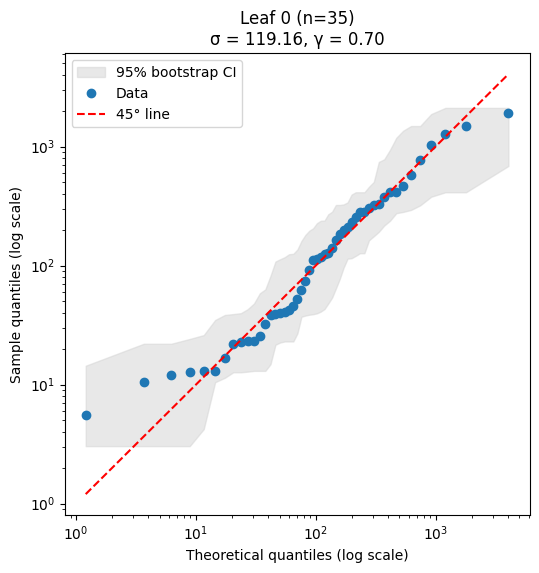

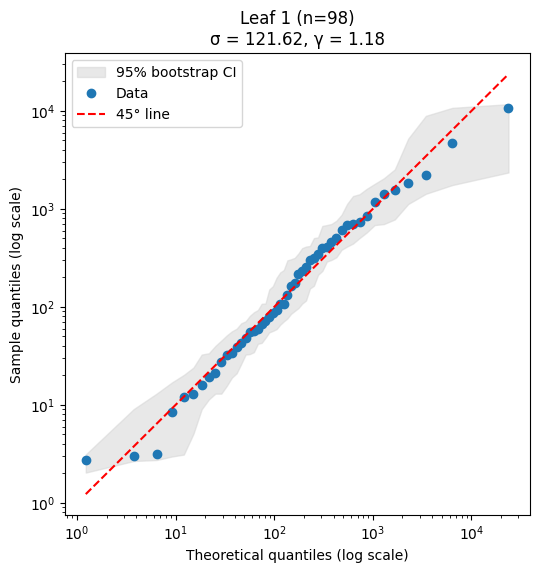

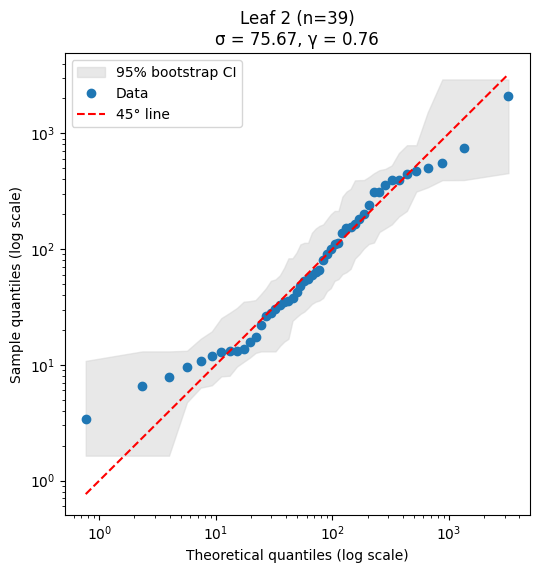

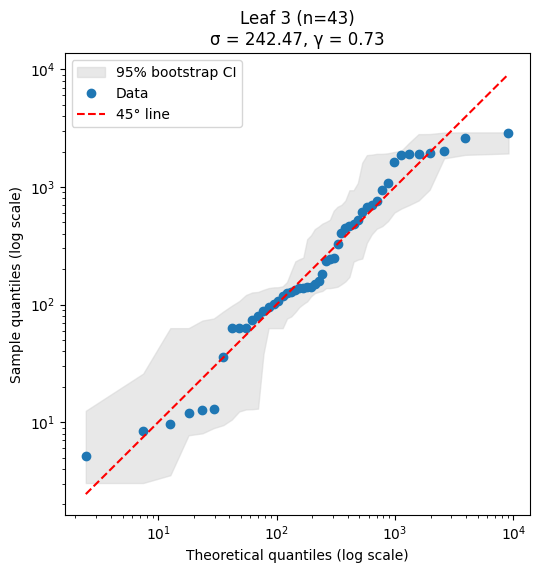

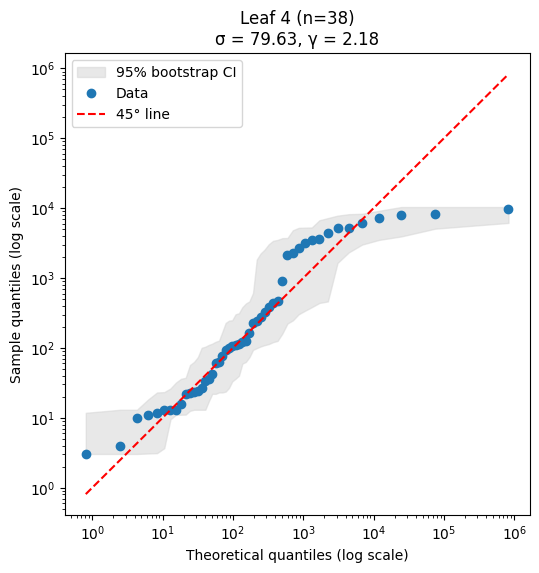

In [ ]:
graphs.plot_gp_tree_qq(gpd_tail_tree_pruned, X_tail, y_tail)


In [ ]:
importance=pd.DataFrame(importances)
importance.head()

,name,importance
0,8. Regulation_lag1,0.010
1,1. Economic Policy Uncertainty_lag1,0.008
2,Fiscal Policy (Taxes OR Spending)_lag1,0.001
3,3. Taxes_lag1,0.000
4,Category_Business Disruption and System Failures,0.000


In [ ]:
# 모듈 헬퍼 준비
find_leaf = M.find_leaf
get_leaves = M._get_all_leaves

def _get_leaf_params(leaf):
    gp = getattr(leaf, "gpd_params", None)
    return (np.nan, np.nan) if gp is None else (float(gp[0]), float(gp[1]))

# CI 계산
cis = M.leaf_confidence_intervals(
    gpd_tail_tree_pruned, X_tail, y_tail,
    find_leaf=find_leaf, get_leaves=get_leaves, get_leaf_params=_get_leaf_params
)

# 보기 좋게 출력 (+ 리프별 샘플 수)
leaf_objs = np.array([find_leaf(gpd_tail_tree_pruned, X_tail[i]) for i in range(len(X_tail))], dtype=object)
leaves = get_leaves(gpd_tail_tree_pruned)

print("\n===== Leaf-wise γ 95% CI =====")
for i, rec in enumerate(cis):
    gamma = rec.get("gamma", np.nan)
    lo, hi = (rec.get("ci_95", [np.nan, np.nan]) + [np.nan, np.nan])[:2]
    n_i = int(np.sum(leaf_objs == leaves[i])) if i < len(leaves) else 0
    print(f"Leaf#{i:02d}  N={n_i:4d}   γ={gamma: .3f}   CI95=[{lo: .3f}, {hi: .3f}]")



===== Leaf-wise γ 95% CI =====
Leaf#00  N=  35   γ= 0.697   CI95=[ 0.077,  1.316]
Leaf#01  N=  98   γ= 1.183   CI95=[ 0.717,  1.649]
Leaf#02  N=  39   γ= 0.764   CI95=[ 0.178,  1.349]
Leaf#03  N=  43   γ= 0.726   CI95=[ 0.148,  1.304]
Leaf#04  N=  38   γ= 2.178   CI95=[ 1.155,  3.201]


In [ ]:
import numpy as np
import scipy.stats as st

def hill_ci(gamma_hat, n_exceed, alpha=0.05):
    """Asymptotic normal CI for Hill estimator"""
    se = gamma_hat / np.sqrt(n_exceed)
    z = st.norm.ppf(1 - alpha/2)
    return gamma_hat - z*se, gamma_hat + z*se

print("\n===== Leaf-wise γ 95% CI (Asymptotic) =====")
for i, rec in enumerate(cis):
    gamma = rec.get("gamma", np.nan)
    n_i = int(np.sum(leaf_objs == leaves[i])) if i < len(leaves) else 0
    if np.isnan(gamma) or n_i < 30:  # 샘플 적으면 skip
        lo, hi = np.nan, np.nan
    else:
        lo, hi = hill_ci(gamma, n_i, alpha=0.05)
    print(f"Leaf#{i:02d}  N={n_i:4d}   γ={gamma: .3f}   CI95=[{lo: .3f}, {hi: .3f}]")



===== Leaf-wise γ 95% CI (Asymptotic) =====
Leaf#00  N=  35   γ= 0.697   CI95=[ 0.466,  0.928]
Leaf#01  N=  98   γ= 1.183   CI95=[ 0.949,  1.417]
Leaf#02  N=  39   γ= 0.764   CI95=[ 0.524,  1.003]
Leaf#03  N=  43   γ= 0.726   CI95=[ 0.509,  0.943]
Leaf#04  N=  38   γ= 2.178   CI95=[ 1.485,  2.870]


##AIC

In [ ]:
# ================== POST-FIT EVAL: AIC/BIC, VaR, ES, GOF ==================

# ★ 1) raw y (초과치 아님) 준비
y_tail_raw = y_all_data[mask_tail]        # raw tail values
y_tail_excess = y_tail                    # (이미 있음) excess = y - u_threshold

# ★ 2) 네임스페이스 통일 (patched 모듈 함수 바인딩)
find_leaf_fn  = l1_l2_gpd_patched_new_catprune.find_leaf
get_leaves_fn = l1_l2_gpd_patched_new_catprune._get_all_leaves

# ★ 3) LN-only 트리도 patched 모듈로 생성 + 파라미터 부여
ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
    X_all_data, y_all_data, feature_names_list, min_leaf=30, max_depth=4
)
l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
    ln_only_tree, X_all_data, y_all_data, trunc_right=None
)

# 4) (선택) Bulk 모델로는 L2 트리 사용한 혼합 ln+gpd 성능을 보고 싶다면
tree_ln_for_mix  = l2_bulk_tree                      # bulk용 LN 트리
tree_gpd_for_mix = gpd_tail_tree_pruned              # tail용 GPD 트리 (없으면 None)

# 5) 모델 로그가능도/정보기준
ll_ln, k_ln, aic_ln, bic_ln = model_loglik_aic_bic(
    ln_only_tree, None,
    X_all_data, y_all_data,                      # LN-only: bulk=전체
    np.empty((0, X_all_data.shape[1])), np.empty(0),  # tail 없음
    u_threshold,
    find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
)

if tree_gpd_for_mix is not None:
    ll_mix, k_mix, aic_mix, bic_mix = model_loglik_aic_bic(
        tree_ln_for_mix, tree_gpd_for_mix,
        X_bulk, y_bulk,                         # bulk set
        X_tail, y_tail_raw,                     # ★ raw tail 필요!
        u_threshold,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
    )
else:
    ll_mix, k_mix, aic_mix, bic_mix = (np.nan, np.nan, np.nan, np.nan)

print(f"[LN Only]  logL={ll_ln:.1f}, k={k_ln}, AIC={aic_ln:.1f}, BIC={bic_ln:.1f}")
if tree_gpd_for_mix is not None:
    print(f"[LN+GPD]  logL={ll_mix:.1f}, k={k_mix}, AIC={aic_mix:.1f}, BIC={bic_mix:.1f}")
else:
    print("[LN+GPD]  (tail 표본 부족으로 GPD 트리 없음)")

# 6) VaR / ES
var_ln  = unconditional_var_ln(ln_only_tree, get_leaves=get_leaves_fn, alpha=0.99)
es_ln   = unconditional_es_ln(ln_only_tree,  get_leaves=get_leaves_fn, alpha=0.99)

if tree_gpd_for_mix is not None:
    var_mix = unconditional_var_mix(tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    es_mix  = unconditional_es_mix (tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    print(f"99% VaR | LN Only = {var_ln:,.0f}   LN+GPD = {var_mix:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}   LN+GPD = {es_mix:,.0f}")
else:
    print(f"99% VaR | LN Only = {var_ln:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}")

# 7) GPD 리프별 GOF (KS/AD) — excess 필요
if tree_gpd_for_mix is not None:
    gof_df = gpd_gof_leafwise(
        tree_gpd_for_mix, X_tail, y_tail_excess,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn, method="both"
    )
    pd.set_option('display.float_format', '{:,.3f}'.format)
    print("\n=== GPD Leaf-wise KS / AD Results ===")
    print(gof_df.to_string(index=False))


[LN Only]  logL=-13161.0, k=28, AIC=26378.1, BIC=26558.0
[LN+GPD]  logL=-13271.3, k=30, AIC=26602.6, BIC=26795.3
99% VaR | LN Only = 499   LN+GPD = 316
99% ES  | LN Only = 2,753   LN+GPD = inf

=== GPD Leaf-wise KS / AD Results ===
        leaf_id  n   sigma  gamma  KS stat  KS p  AD stat  AD p
140440528703936 43 242.466  0.726    0.115 0.582    0.621 0.106
140440528705344 98 121.620  1.183    0.072 0.665    0.473 0.245
140440528706112 35 119.165  0.697    0.101 0.833    0.308 0.629
140440528707776 39  75.672  0.764    0.076 0.965    0.266 0.798
140440528711744 38  79.626  2.178    0.136 0.447    0.616 0.109


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# ──────────────────────────────────────────────
# 0) Monte-Carlo 기반 VaR/ES 계산 (ppf 사용 안 함)
# ──────────────────────────────────────────────
def mc_var_es(dist, params, alpha=0.99, n_mc=300_000, random_state=42):
    """
    dist   : scipy.stats 배포( .rvs 가능 )
    params : dist.fit(...) 결과 파라미터 (튜플)
    alpha  : 신뢰수준 (예: 0.99)
    n_mc   : MC 표본 수
    """
    rng = np.random.default_rng(random_state)
    samples = dist.rvs(*params, size=n_mc, random_state=rng)

    # 샘플 기반 VaR/ES
    var_alpha = np.quantile(samples, alpha)
    tail = samples[samples >= var_alpha]
    # tail이 비면 방어적 처리
    if tail.size == 0:
        k = max(1, int(np.ceil(0.001 * n_mc)))
        tail = np.partition(samples, -k)[-k:]
    es_alpha = float(tail.mean())
    return float(var_alpha), es_alpha

# ──────────────────────────────────────────────
# 1) 적합 + AIC/BIC + (MC) VaR + (MC) ES
# ──────────────────────────────────────────────
def fit_score_var_es(dist, data, name,
                     fix_loc0=True,    # NIG에는 False 권장
                     alpha=0.99,
                     n_es_mc=300_000,
                     random_state=42):
    """
    dist, data, name, alpha 동일.
    n_es_mc : ES/ VaR 추정을 위한 MC 표본 수
    """
    try:
        data = np.asarray(data, dtype=float)
        data = data[np.isfinite(data)]
        if data.size == 0:
            raise ValueError("No valid data points.")

        # ① 분포 적합 (MLE)
        if fix_loc0:
            params = dist.fit(data, floc=0)   # loc을 0으로 고정 (NIG에는 비권장)
            k = len(params) - 1
        else:
            params = dist.fit(data)           # loc/scale/shape 모두 추정
            k = len(params)

        # ② 로그 가능도
        logpdf = dist.logpdf(data, *params)
        logpdf = logpdf[np.isfinite(logpdf)]
        logL   = float(logpdf.sum())
        n      = int(data.size)

        # ③ AIC / BIC
        aic = 2*k - 2*logL
        bic = np.log(n)*k - 2*logL

        # ④~⑤ VaR/ES (모두 MC로 계산 → ppf 사용 안 함)
        var_alpha, es_alpha = mc_var_es(dist, params, alpha, n_es_mc, random_state)

        return {
            "Distribution": name,
            "Log-Likelihood": logL,
            "AIC": aic,
            "BIC": bic,
            f"VaR {int(alpha*100)}%": var_alpha,
            f"ES  {int(alpha*100)}%": es_alpha
        }

    except Exception as e:
        return {
            "Distribution": name,
            "Log-Likelihood": f"Fit failed: {e}",
            "AIC": np.nan,
            "BIC": np.nan,
            f"VaR {int(alpha*100)}%": np.nan,
            f"ES  {int(alpha*100)}%": np.nan
        }

# ──────────────────────────────────────────────
# 2) 후보 분포 지정 & 실행
# ──────────────────────────────────────────────
candidates = {
    "Log-Normal":     (stats.lognorm,     True),
    "Gamma":          (stats.gamma,       True),
    "Weibull":        (stats.weibull_min, True),
    # NIG는 scipy.stats.norminvgauss (shape: a, b; loc, scale)
    # ★ floc=0 고정하지 마세요 → 수치 불안정 완화
    "NIG":            (stats.norminvgauss, False),
}

alpha = 0.99
results = [fit_score_var_es(dist, y_all_data, name,
                            fix_loc0=fix_loc0,   # NIG는 False
                            alpha=alpha,
                            n_es_mc=300_000,
                            random_state=42)
           for name, (dist, fix_loc0) in candidates.items()]

results_df = (pd.DataFrame(results)
                .sort_values("AIC", key=lambda s: s.fillna(np.inf))
                .reset_index(drop=True))

print(results_df)


  Distribution  Log-Likelihood        AIC        BIC  VaR 99%   ES  99%
0   Log-Normal     -13,888.371 27,780.742 27,793.593  267.736   781.745
1          NIG     -14,171.156 28,350.313 28,376.014  948.184 3,381.910
2      Weibull     -14,772.099 29,548.197 29,561.048  261.643   431.947
3        Gamma     -16,244.744 32,493.487 32,506.338  491.907   661.547



================  Model Comparison  ================

  Distribution  Log-Likelihood        AIC        BIC  VaR 99%   ES  99%      k
0       LN+GPD     -13,271.284 26,602.569 26,795.328  316.289       inf 30.000
1   Log-Normal     -13,888.371 27,780.742 27,793.593  267.736   781.745    NaN
2          NIG     -14,171.156 28,350.313 28,376.014  948.184 3,381.910    NaN
3      Weibull     -14,772.099 29,548.197 29,561.048  261.643   431.947    NaN
4        Gamma     -16,244.744 32,493.487 32,506.338  491.907   661.547    NaN


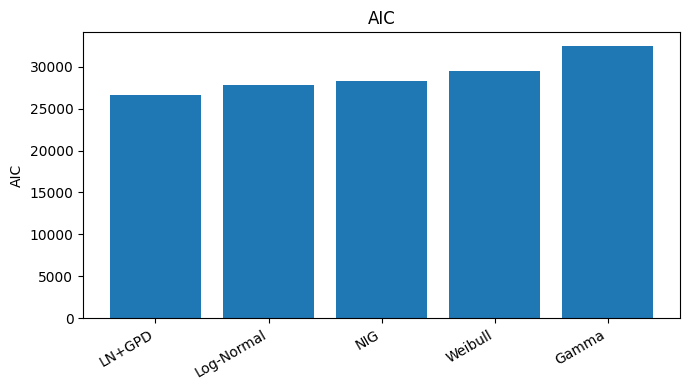

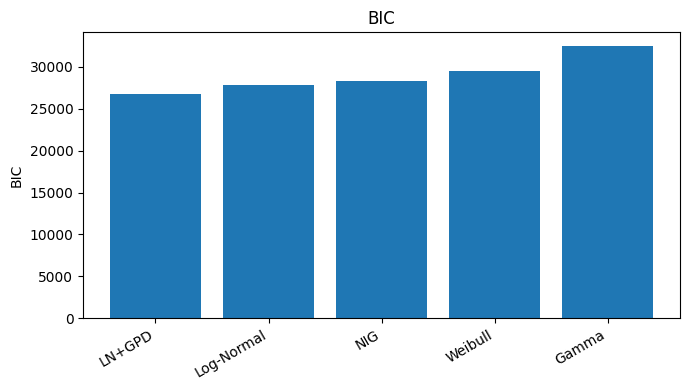

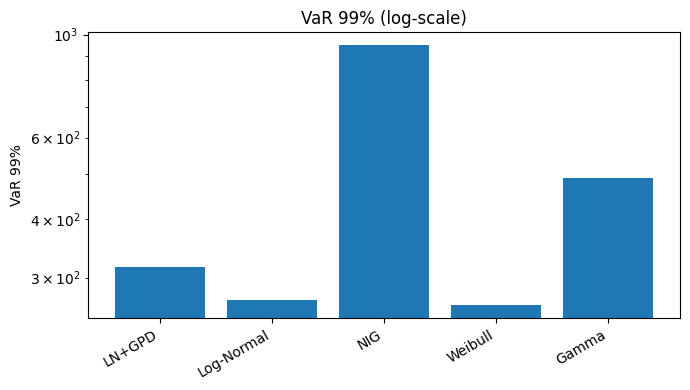

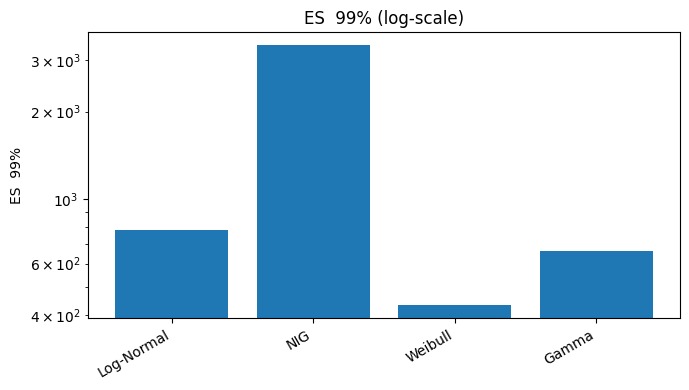

In [ ]:
# ──────────────────────────────────────────────
# 0) Tree 모델 행을 만들어 results_df 와 합치기
# ──────────────────────────────────────────────
tree_rows = pd.DataFrame([
#    {"Distribution": "LN‑Tree",  "Log-Likelihood": ll_ln,  "k": k_ln,
#     "AIC": aic_ln,  "BIC": bic_ln,
 #    "VaR 99%": var_ln,  "ES  99%": es_ln},
    {"Distribution": "LN+GPD",   "Log-Likelihood": ll_mix, "k": k_mix,
     "AIC": aic_mix, "BIC": bic_mix,
     "VaR 99%": var_mix, "ES  99%": es_mix}
])

full_df = (pd.concat([results_df, tree_rows], ignore_index=True)
             .sort_values("AIC")
             .reset_index(drop=True))

print("\n================  Model Comparison  ================\n")
print(full_df)

# ──────────────────────────────────────────────
# 1) AIC / BIC   (로그축 X)
# ──────────────────────────────────────────────
import matplotlib.pyplot as plt

for metric in ["AIC", "BIC"]:
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], full_df[metric])
    plt.title(f"{metric}")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

# ──────────────────────────────────────────────
# 2) VaR / ES   (log‑scale로 값 차이를 보기 좋게)
# ──────────────────────────────────────────────
for metric in ["VaR 99%", "ES  99%"]:
    y = pd.to_numeric(full_df[metric], errors="coerce").to_numpy(dtype=float)
    y_plot = np.where(np.isfinite(y) & (y > 0), y, np.nan)  # 🔧 inf/<=0 → NaN
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], y_plot)
    plt.yscale("log")
    plt.title(f"{metric} (log-scale)")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()



In [ ]:
import pickle

# --- __main__ 블록 마지막에 추가 ---
save_path = '/content/drive/MyDrive/Operational_risk/'
# 1) 저장할 객체들 모으기
output = {
    # Bulk 트리
    'l1_bulk_tree' : l1_bulk_tree,
    'l2_bulk_tree' : l2_bulk_tree,
    # Tail 트리
    'gpd_raw_tree' : gpd_tail_tree_raw,
    'gpd_pruned_tree' : gpd_tail_tree_pruned,
    # 데이터
    'X_bulk'       : X_bulk,
    'y_bulk'       : y_bulk,
    'X_tail'       : X_tail,
    'y_tail'       : y_tail,
    'X_all_data'   : X_all_data,
    'y_all_data'   : y_all_data,
    'df_model_ready':df_model_ready,
    # (선택) 피처 이름
    'feature_names': feature_names_list,
    # (선택) 임계값
    'u_threshold'  : u_threshold
}

# 2) 피클 파일로 저장
with open(save_path + 'EPU_Category_Banking.pkl', 'wb') as f:
    pickle.dump(output, f)



##Insurance+Banking

In [ ]:
loss_business_line = loss_df_finance[['Date', 'Current Value of Loss', 'Business_line']]

loss_by_business = (
    loss_business_line
    .groupby('Business_line', as_index=False)
    .agg({'Current Value of Loss': 'sum'}).sort_values('Current Value of Loss',ascending=False)  # Date 제외
)

print(loss_by_business)


                               Business_line  Current Value of Loss
14                             Manufacturing          408048.336600
6                                    Banking          244757.059903
15                        Markets & Treasury          187109.660354
17                                    Mining           87567.747000
12                                 Insurance           82097.384000
26                                 Utilities           69634.625000
11                               Information           69519.931000
4                        Asset & Wealth Mgmt           60363.880000
7                       Brokerage & Advisory           38945.919138
20                                    Others           37755.515000
13                        Investment Banking           32326.020000
21                     Professional Services           32234.573012
10           Health Care & Social Assistance           25834.333000
24                              Retail Trade    

In [ ]:
loss_manufacturing= loss_df_finance[loss_df_finance['Business_line'].isin(['Insurance','Banking'])].copy()

In [ ]:
loss_manufacturing.head()

,Date,Event Risk Category,Current Value of Loss,Business_line
1799,1979,"Clients, Products & Business Practices",4.0,Banking
4667,1979,"Clients, Products & Business Practices",2.0,Insurance
1282,1979,Internal Fraud,1.2,Banking
1654,1979,Internal Fraud,6.2,Banking
1707,1979,"Clients, Products & Business Practices",3.0,Banking


In [ ]:
loss_manufacturing['Event Risk Category'].value_counts()

,count
Event Risk Category,
"Clients, Products & Business Practices",2736
External Fraud,2255
Internal Fraud,1461
Employment Practices and Workplace Safety,191
"Execution, Delivery & Process Management",145
Damage to Physical Assets,56
Business Disruption and System Failures,15


In [ ]:
# Encode 'Event Risk Category'
df_encoded_a = pd.get_dummies(loss_manufacturing, columns=['Event Risk Category'], prefix='Category')

# Use the result of the first encoding as input for the second encoding
df_encoded_b = df_encoded_a.copy()
df_encoded_b.drop(columns=['Business_line'], inplace=True)

# Final encoded DataFrame
loss_manufacturing = df_encoded_b.copy()


In [ ]:
import re

# ① CSV 읽기
cpu = pd.read_csv('/content/drive/MyDrive/CPU index.csv')[['date', 'cpu_index']]

# ② 전처리 ── 공백 제거
cpu['date'] = cpu['date'].str.strip()

# ③ 'YY-Mon' → 'Mon-YY' 로 재배열
cpu['date'] = cpu['date'].str.replace(
    r'^(\d{2})-([A-Za-z]{3})$',   # 2자리 연도-3자리 월
    r'\2-\1',                     # 월-연도로 바꾸기
    regex=True, flags=re.IGNORECASE
)

# ④ datetime 파싱
cpu['date'] = pd.to_datetime(cpu['date'], format='%b-%y', errors='coerce')

# ⑤ 원하는 포맷(문자열)으로 출력하거나, 월 Period 로도 사용 가능
cpu['date'] = cpu['date'].dt.strftime('%Y-%m')      # 문자열 형태


In [ ]:
import pandas as pd
import numpy as np
from functools import reduce

file_paths = {
    "us_cpi": "/content/drive/MyDrive/us_cpi.csv",
    "us_unemp": "/content/drive/MyDrive/us_unemp.csv",
    "us_vix": "/content/drive/MyDrive/us_vix.csv",
    "us_m2": "/content/drive/MyDrive/us_m2.csv",
    "us_home_price": "/content/drive/MyDrive/us_home price index.csv",
    "us_T10Y2Y": "/content/drive/MyDrive/us_T10Y2Y.csv",
    "sp500": "/content/drive/MyDrive/sp500_monthly.csv",
}

# Load
us_cpi = pd.read_csv(file_paths["us_cpi"])
us_unemp = pd.read_csv(file_paths["us_unemp"])
us_m2 = pd.read_csv(file_paths["us_m2"])
us_home_price = pd.read_csv(file_paths["us_home_price"])
us_T10Y2Y = pd.read_csv(file_paths["us_T10Y2Y"])
sp500 = pd.read_csv(file_paths["sp500"], skiprows=2)

# Rename columns
us_T10Y2Y.rename(columns={'T10Y2Y': '10_2'}, inplace=True)
us_home_price.rename(columns={'USSTHPI': 'House Price Index'}, inplace=True)
us_m2.rename(columns={'WM2NS': 'M2'}, inplace=True)
us_cpi.rename(columns={'CPIAUCSL': 'CPI'}, inplace=True)
us_unemp.rename(columns={'UNRATE': 'Unemployment Rate'}, inplace=True)
sp500.rename(columns={'Unnamed: 1': 'Close'}, inplace=True)
sp500 = sp500.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4", "Unnamed: 5"])
cpu.rename(columns={'date': 'Date'}, inplace=True)


# Date 처리 및 연 단위 평균
for df in [us_cpi, us_unemp, us_m2, us_home_price, us_T10Y2Y, sp500,cpu]:
    df.rename(columns={df.columns[0]: "Date"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"]).dt.year

us_T10Y2Y = us_T10Y2Y.groupby("Date").mean().reset_index()
us_home_price = us_home_price.groupby("Date").mean().reset_index()
us_m2 = us_m2.groupby("Date").mean().reset_index()
us_cpi = us_cpi.groupby("Date").mean().reset_index()
us_unemp = us_unemp.groupby("Date").mean().reset_index()
sp500 = sp500.groupby("Date").mean().reset_index()
cpu = cpu.groupby("Date").mean().reset_index()


# log-diff 처리
macro_dfs = {

    'Close_diff': (sp500, 'Close'),
}

# diff 열 추가
for diff_col, (df, col) in macro_dfs.items():
    df[diff_col] = np.log(df[col]).diff()

# sp500의 첫 번째 NaN만 특정 값으로 채움
sp500['Close_diff'].fillna(0.1635259493925565, inplace=True)

# 병합
dfs = [us_T10Y2Y, us_home_price, us_m2, us_cpi, us_unemp, sp500,cpu]
df_merged_macro = reduce(lambda left, right: pd.merge(left, right, on="Date", how="inner"), dfs)

# 최종 lag 데이터
df_merged_macro_lag = df_merged_macro[df_merged_macro["Date"] >= 1980].copy()
df_merged_macro_lag['Date'] = df_merged_macro_lag['Date'].astype(str)


/tmp/ipython-input-3402856144.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sp500['Close_diff'].fillna(0.1635259493925565, inplace=True)


In [ ]:
import numpy as np
import pandas as pd
from functools import reduce
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import minimize
from scipy.stats import genpareto
import copy
#1986부터 사용
#############################################
# 1. 데이터 전처리 (연 단위)
#############################################
# (1) 엑셀 파일 읽기 및 날짜 정리
# 실제 파일 경로로 수정하세요.

epu_kr_path = '/content/drive/MyDrive/Korea_Overall_EPU.xlsx'
epu_kr_cat_path = '/content/drive/MyDrive/Korea_Categorical_PU_Indices.xlsx'
epu_usa_path = '/content/drive/MyDrive/US_Policy_Uncertainty_Data.xlsx'
epu_usa_cat_path = '/content/drive/MyDrive/Categorical_EPU_Data.xlsx'


# 미국 EPU 데이터
epu_usa = pd.read_excel(epu_usa_path)
epu_usa_cat = pd.read_excel(epu_usa_cat_path)
# 연도만 추출 (datetime 변환 후 정수형으로)
epu_usa['Year'] = pd.to_datetime(epu_usa['Year'], format='%Y').dt.year.astype(int)
epu_usa_cat['Year'] = pd.to_datetime(epu_usa_cat['Year'], format='%Y').dt.year.astype(int)
# 연도 필터링 (1985~2022)
epu_usa_cl = epu_usa[(epu_usa['Year'] < 2023)].copy()
epu_usa_cat_cl = epu_usa_cat[ (epu_usa_cat['Year'] < 2023)].copy()
# 최종적으로 'Date' 컬럼에 연도만(문자형) 저장
epu_usa_cl['Date'] = epu_usa_cl['Year'].astype(str)
epu_usa_cat_cl['Date'] = epu_usa_cat_cl['Year'].astype(str)
epu_usa_cl_lag = epu_usa_cl.copy()
epu_usa_cat_cl_lag = epu_usa_cat_cl.copy()


epu_usa_cl['Date'] = epu_usa_cl['Year'].astype(str)

epu_overall = (
    epu_usa_cl
    .groupby('Date')[['Three_Component_Index','News_Based_Policy_Uncert_Index']]
    .mean()
    .reset_index()
)

# 2) 범주형 EPU 연평균 집계
# ————————
cat_cols = [
    '1. Economic Policy Uncertainty','2. Monetary policy',
    'Fiscal Policy (Taxes OR Spending)','3. Taxes',
    '4. Government spending','5. Health care',
    '6. National security','7. Entitlement programs',
    '8. Regulation','Financial Regulation',
    '9. Trade policy','10. Sovereign debt, currency crises'
]
epu_usa_cat_cl['Date'] = epu_usa_cat_cl['Year'].astype(str)

epu_cats = (
    epu_usa_cat_cl
    .groupby('Date')[cat_cols]
    .mean()
    .reset_index()
)

# 3) 매크로 + EPU(전체+범주) 병합
# ———————————————
df_macro_epu = (
    df_merged_macro_lag
    .merge(epu_overall, on='Date', how='inner')
    .merge(epu_cats,    on='Date', how='inner')
)

# 4) 최종: 이벤트 손실(≈433행)과 1:1 병합
# ——————————————————————
final_df = df_macro_epu.merge(loss_manufacturing, on='Date', how='inner')




In [ ]:
df_merged=final_df.copy()
df_merged['Exceedance']=df_merged['Current Value of Loss']

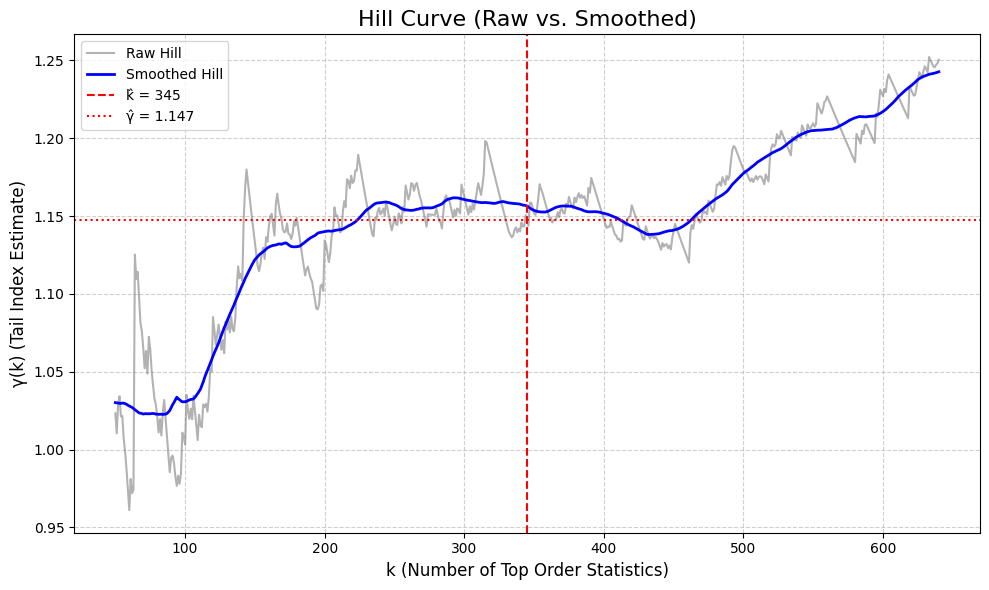

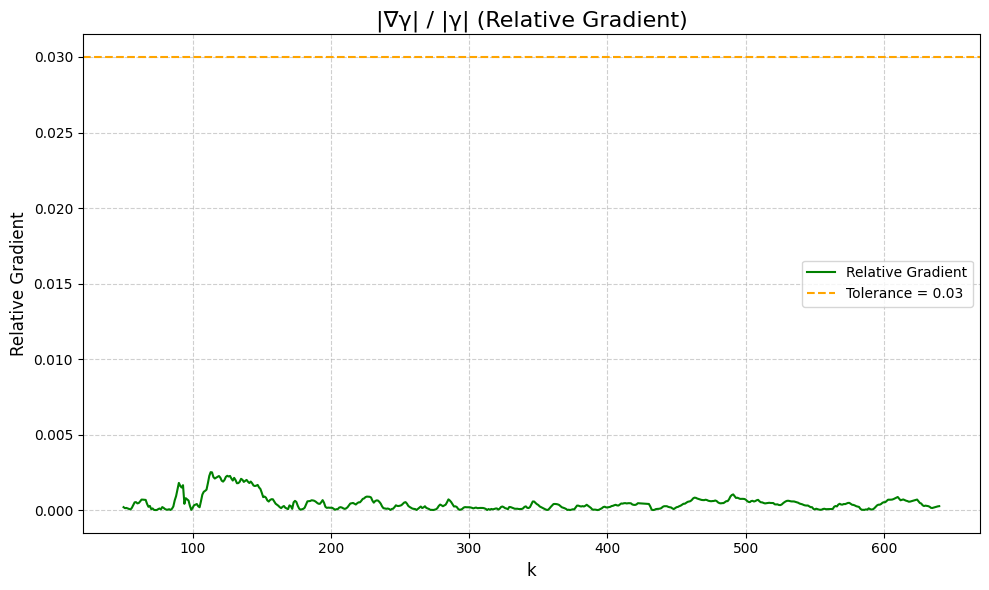

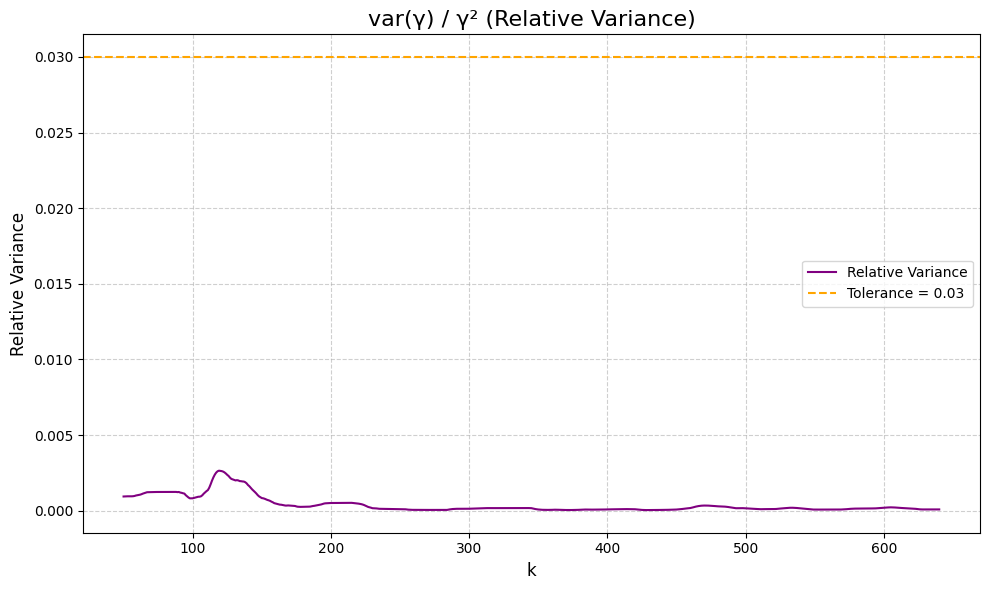

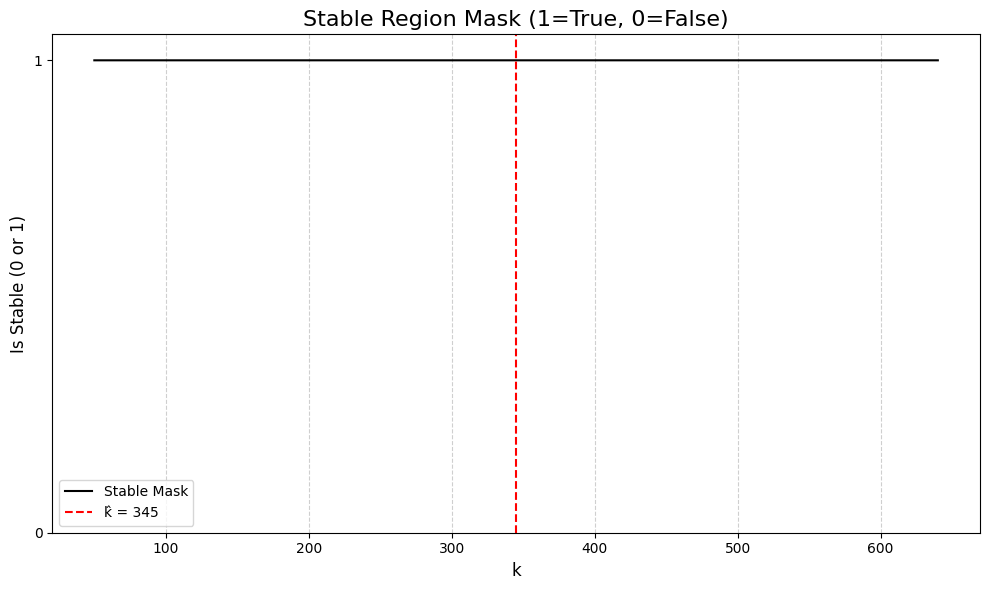


--- Results ---
Estimated Threshold (u_hat): 95.0000
Number of Exceedances (k_hat): 345
Estimated Tail Index (gamma_hat): 1.1472
----------------


In [ ]:
# hill_plots.py ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple, Dict, Any

# It's assumed that the 'thresholding' module you created is in the same folder.
from hill_plot_new_patched import select_threshold, HillDiag

def _compute_hill_raw_curve(y: np.ndarray, ks: np.ndarray) -> np.ndarray:
    """
    Computes the raw (unsmoothed) Hill curve.
    γ_k = mean( log Y_(1..k) - log Y_(k+1) ), where Y are sorted positive values.
    """
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    y_desc = np.sort(y)[::-1]
    y_pos = y_desc[y_desc > 0]
    if y_pos.size < 2 or ks.size == 0: # Need at least 2 points to compute log-differences
        return np.array([])

    # Ensure k does not exceed valid index
    max_k = y_pos.size - 1
    valid_ks = ks[ks < max_k]
    if valid_ks.size == 0:
        return np.array([])

    return np.array([np.mean(np.log(y_pos[:k]) - np.log(y_pos[k])) for k in valid_ks], dtype=float)

def plot_hill_curve(
    y: np.ndarray,
    diag: HillDiag,
    k_hat: int,
    gamma_hat: float,
    *,
    title: str = "Hill Curve (Raw vs. Smoothed)",
) -> None:
    """
    Plots the Hill curve (raw vs. smoothed) and the estimated point (k_hat, gamma_hat).
    """
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot Hill curve.")
        return

    gamma_raw = _compute_hill_raw_curve(y, diag.k_grid)

    plt.figure(figsize=(10, 6))
    if gamma_raw.size:
        # Match raw curve to its valid k-grid
        max_k_raw = y.size - 1
        valid_ks_raw = diag.k_grid[diag.k_grid < max_k_raw]
        plt.plot(valid_ks_raw, gamma_raw, label="Raw Hill", alpha=0.6, color='gray')

    plt.plot(diag.k_grid, diag.gamma_hat, label="Smoothed Hill", color='blue', linewidth=2)
    plt.axvline(k_hat, linestyle="--", color='red', label=f"k̂ = {k_hat}")
    plt.axhline(gamma_hat, linestyle=":", color='red', label=f"γ̂ = {gamma_hat:.3f}")

    plt.title(title, fontsize=16)
    # CHANGED: Korean -> English
    plt.xlabel("k (Number of Top Order Statistics)", fontsize=12)
    plt.ylabel("γ(k) (Tail Index Estimate)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_grad_norm(
    diag: HillDiag,
    *,
    rel_grad_tol: float,
    title: str = "|∇γ| / |γ| (Relative Gradient)"
) -> None:
    """Plots the relative gradient and the tolerance line."""
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot grad_norm.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(diag.k_grid, diag.grad_norm, label="Relative Gradient", color='green')
    plt.axhline(rel_grad_tol, linestyle="--", color='orange', label=f"Tolerance = {rel_grad_tol}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Relative Gradient", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_var_rel(
    diag: HillDiag,
    *,
    rel_var_tol: float,
    title: str = "var(γ) / γ² (Relative Variance)"
) -> None:
    """Plots the relative variance and the tolerance line."""
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot var_rel.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(diag.k_grid, diag.var_rel, label="Relative Variance", color='purple')
    plt.axhline(rel_var_tol, linestyle="--", color='orange', label=f"Tolerance = {rel_var_tol}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Relative Variance", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_stable_mask(
    diag: HillDiag,
    *,
    rel_grad_tol: float,
    rel_var_tol: float,
    gamma_min: float,
    k_hat: int,
    title: str = "Stable Region Mask (1=True, 0=False)"
) -> None:
    """
    Visualizes the stable region mask:
    stable = (grad_norm < rel_grad_tol) & (var_rel < rel_var_tol) & (gamma_hat > gamma_min)
    """
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot stable mask.")
        return

    stable = (diag.grad_norm < rel_grad_tol) & (diag.var_rel < rel_var_tol) & (diag.gamma_hat > gamma_min)

    plt.figure(figsize=(10, 6))
    plt.step(diag.k_grid, stable.astype(int), where="mid", label="Stable Mask", color='black')
    plt.axvline(k_hat, linestyle="--", color='red', label=f"k̂ = {k_hat}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Is Stable (0 or 1)", fontsize=12)
    plt.yticks([0, 1])
    plt.legend()
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_hill_diagnostics(
    y: np.ndarray,
    *,
    # Parameters for thresholding._auto_hill
    k_min: int = 50,
    k_max_prop: float = 0.1,
    window: int = 61,
    rel_grad_tol: float = 0.04,
    rel_var_tol: float = 0.03,
    gamma_min: float = 0.02,
    min_plateau_len: int = 10,
    plateau_strategy: str = "longest",
    min_excess: Optional[int] = None,
    max_excess: Optional[int] = None,
    # Optional titles for individual plots
    titles: Optional[Dict[str, str]] = None,
    # For passing extra args to select_threshold
    extra_hill_kwargs: Optional[Dict[str, Any]] = None,
) -> Tuple[float, int, float, HillDiag]:
    """
    In a single call, this function:
      1) Runs select_threshold to get (u_hat, k_hat, gamma_hat, diag).
      2) Generates separate plots for Hill curve, grad_norm, var_rel, and stable mask.

    Returns: (u_hat, k_hat, gamma_hat, diag)
    """
    if titles is None:
        titles = {}
    if extra_hill_kwargs is None:
        extra_hill_kwargs = {}

    # Call select_threshold requesting the diagnostic data
    u_hat, k_hat, gamma_hat, diag = select_threshold(
        y,
        return_diag=True,
        k_min=k_min,
        k_max_prop=k_max_prop,
        window=window,
        rel_grad_tol=rel_grad_tol,
        rel_var_tol=rel_var_tol,
        gamma_min=gamma_min,
        min_plateau_len=min_plateau_len,
        plateau_strategy=plateau_strategy,
        min_excess=min_excess,
        max_excess=max_excess,
        **extra_hill_kwargs,
    )

    # 1) Hill Curve
    plot_hill_curve(
        y, diag, k_hat, gamma_hat,
        title=titles.get("hill", "Hill Curve (Raw vs. Smoothed)")
    )

    # 2) grad_norm
    plot_grad_norm(
        diag,
        rel_grad_tol=rel_grad_tol,
        title=titles.get("grad", "|∇γ| / |γ| (Relative Gradient)")
    )

    # 3) var_rel
    plot_var_rel(
        diag,
        rel_var_tol=rel_var_tol,
        title=titles.get("var", "var(γ) / γ² (Relative Variance)")
    )

    # 4) stable mask
    plot_stable_mask(
        diag,
        rel_grad_tol=rel_grad_tol,
        rel_var_tol=rel_var_tol,
        gamma_min=gamma_min,
        k_hat=k_hat,
        title=titles.get("stable", "Stable Region Mask (1=True, 0=False)")
    )

    return u_hat, k_hat, gamma_hat, diag


if __name__ == "__main__":

    # Run the diagnostic plotting function
    u_hat, k_hat, gamma_hat, diag = plot_hill_diagnostics(
        df_merged['Exceedance'],
        k_min=50,
        k_max_prop=0.1, # Use a larger proportion for better visualization
        window=61,
        rel_grad_tol=0.03,
        rel_var_tol=0.03, # Loosen var tolerance slightly for demo
        gamma_min=0.02,
        min_plateau_len=20,
        plateau_strategy="longest",
    )

    print("\n--- Results ---")
    print(f"Estimated Threshold (u_hat): {u_hat:.4f}")
    print(f"Number of Exceedances (k_hat): {k_hat}")
    print(f"Estimated Tail Index (gamma_hat): {gamma_hat:.4f}")
    print("----------------")

In [ ]:
n = len(df_merged['Exceedance'])
top_percent = (k_hat / n) * 100
print(f"Top {top_percent:.2f}% of data exceed threshold {u_hat:.2f}")


Top 5.39% of data exceed threshold 95.00


In [ ]:

df = df_merged.copy()

# 1) 연도 만들기
if not pd.api.types.is_integer_dtype(df['Date']):
    df['Year'] = pd.to_datetime(df['Date']).dt.year
else:
    df['Year'] = df['Date']

# 2) 대상/피처/카테고리 정의
target_col = 'Exceedance'  # 타깃은 연도 총합으로 집계
base_vars = ['10_2','House Price Index','M1','CPI','Unemployment Rate',
             'Close','Close_diff','Three_Component_Index',
             'News_Based_Policy_Uncert_Index','1. Economic Policy Uncertainty',
             '2. Monetary policy','Fiscal Policy (Taxes OR Spending)','3. Taxes',
             '4. Government spending','5. Health care','6. National security',
             '7. Entitlement programs','8. Regulation','Financial Regulation',
             '9. Trade policy','10. Sovereign debt, currency crises','cpu_index']

# 이미 차분된 컬럼(예: Close_diff)은 이중 차분 방지를 위해 제외 권장
base_vars_clean = [c for c in base_vars if c in df.columns and not c.endswith('_diff') and c != target_col]
cat_cols = [c for c in df.columns if c.startswith('Category_')]

# 3) 집계 규칙: 타깃=sum, 매크로(이미 연평균된 값)=first, 카테고리 더미=max
agg_dict = {
    target_col: 'sum',
    **{c: 'first' for c in base_vars_clean},
    **{c: 'max' for c in cat_cols}
}

# 4) 연도 단위로 집계 -> 정렬 -> 인덱스 리셋
df_year = (df.groupby('Year', as_index=False)
             .agg(agg_dict)
             .sort_values('Year')
             .reset_index(drop=True))

# 4-1) 연도별 사건 수(N_t) 계산 후 병합 (원하면 나중에 그랜저에 포함해서 테스트 가능)
cnt = df.groupby('Year').size().rename('N_t').reset_index()
df_year = df_year.merge(cnt, on='Year', how='left')

# 5) 타깃 안정화 (합은 스케일이 커서 log1p 권장; 음수 없을 때만)
if (df_year[target_col] >= 0).all():
    df_year[target_col] = np.log1p(df_year[target_col])

# 6) 숫자형 보정 및 결측 제거(Granger는 NaN 불가)
cols_to_numeric = [target_col] + base_vars_clean + cat_cols + ['N_t']
for col in cols_to_numeric:
    if col in df_year.columns:
        df_year[col] = pd.to_numeric(df_year[col], errors='coerce')

# 그랜저에 쓸 핵심 컬럼만 NaN 제거
df_granger = df_year.dropna(subset=[target_col] + base_vars_clean)

# 7) 그랜저 파이프라인 실행 (연 단위이므로 max_lag를 3으로 낮춤 권장)
res = granger_analysis.run_granger_analysis_pipeline(
    df_granger,
    base_vars=base_vars_clean,      # N_t도 원하면 base_vars에 추가해서 N_t→타깃 테스트 가능
    target_col=target_col,
    transform='auto',
    max_lag=3
)

summary_df = recent_lag.get_most_recent_granger_lags(
    granger_df=res,
    target_variable=target_col
)

print("--- 변수별 가장 빠른 유의미한 시차 (Lag) 요약 ---")
print(summary_df)


--- 1. Starting Analysis Pipeline ---

--- 2. Checking variable stationarity (ADF Test) ---
Stationary variables: ['10_2', '1. Economic Policy Uncertainty', '2. Monetary policy', 'Fiscal Policy (Taxes OR Spending)', '3. Taxes', '4. Government spending', '6. National security', '8. Regulation', '10. Sovereign debt, currency crises']
Non-stationary variables to be differenced: ['House Price Index', 'CPI', 'Unemployment Rate', 'Close', 'Three_Component_Index', 'News_Based_Policy_Uncert_Index', '5. Health care', '7. Entitlement programs', 'Financial Regulation', '9. Trade policy', 'cpu_index', 'Exceedance']

--- 3. Applying 'auto' differencing ---

--- 4. Running Granger Causality Test on processed data ---
Base variables: ['10_2', 'House Price Index_diff', 'CPI_diff', 'Unemployment Rate_diff', 'Close_diff', 'Three_Component_Index_diff', 'News_Based_Policy_Uncert_Index_diff', '1. Economic Policy Uncertainty', '2. Monetary policy', 'Fiscal Policy (Taxes OR Spending)', '3. Taxes', '4. Govern

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul


--- 5. Analysis Complete ---
'Exceedance'에 영향을 미치는 유의미한 변수를 찾지 못했습니다.
--- 변수별 가장 빠른 유의미한 시차 (Lag) 요약 ---
Empty DataFrame
Columns: [Causal_Var, Most_Recent_Lag]
Index: []


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [ ]:
M = l1_l2_gpd_patched_new_catprune

# ---------- Main ----------
if __name__ == "__main__":

    # --- Configuration ---
    TARGET_VARIABLE = "Exceedance"
    DATE_COLUMN = "Date"
    START_YEAR = 1985

    # Granger Test based lags (example)
    selected_lags_dict = {


    }

    # Categorical features (assumed to be 0/1 dummy encoded)
    categorical_cols_list = [
'Category_Business Disruption and System Failures',
       'Category_Clients, Products & Business Practices',
       'Category_Damage to Physical Assets',
       'Category_Employment Practices and Workplace Safety',
       'Category_Execution, Delivery & Process Management',
       'Category_External Fraud', 'Category_Internal Fraud'
    ]


    # --- Data Loading and Preparation ---
    # If df_merged is not defined, make a synthetic demo
    if 'df_merged' not in locals() or not isinstance(df_merged, pd.DataFrame):
        l1_l2_gpd_patched_new_catprune.logging.warning("'df_merged' DataFrame not found. Generating synthetic data.")
        n_years = 40
        dates = pd.date_range(start='1980-01-01', periods=n_years, freq='YS')
        data = {'Date': dates}
        all_needed_cols = list(selected_lags_dict.keys()) + categorical_cols_list + [TARGET_VARIABLE]
        rng = np.random.default_rng(42)
        for col in all_needed_cols:
            if col == TARGET_VARIABLE:  # positive, heavy-tailed-ish
                data[col] = rng.pareto(a=1.5, size=n_years) * 1000 + 1.0
            elif col.startswith("Category_"):
                data[col] = rng.integers(0, 2, size=n_years)
            else:
                data[col] = rng.standard_normal(n_years).cumsum() + 100.0
        df_merged = pd.DataFrame(data)

    # Create the dataset with lagged features
    try:
        df_model_ready, feature_names_list = l1_l2_gpd_patched_new_catprune.create_lagged_features(
            df=df_merged,
            target_col=TARGET_VARIABLE,
            lag_config=selected_lags_dict,
            date_col=DATE_COLUMN,
            start_year=START_YEAR,
            additional_features=categorical_cols_list
        )
    except Exception as e:
        l1_l2_gpd_patched_new_catprune.logging.error(f"Error creating lagged features: {e}")
        raise

    if df_model_ready.empty:
        l1_l2_gpd_patched_new_catprune.logging.error(
            "Resulting DataFrame is empty after processing. Check input data and parameters."
        )
        raise SystemExit(1)

        # ---------- Matrix build ----------
    features_df = (
        df_model_ready[feature_names_list]
          .apply(pd.to_numeric, errors='coerce')           # "0"/"1" → 0/1, non-numeric → NaN
          .replace([np.inf, -np.inf], np.nan)
    )

    # 간단한 결측 처리(중앙값 대체). 필요 시 본인 로직으로 교체 가능
    if features_df.isna().any().any():
        features_df = features_df.fillna(features_df.median(numeric_only=True))

    # 최종 설계: float 행렬로 강제
    X_all_data = features_df.to_numpy(dtype=float)

    # 타깃도 안전 변환
    y_all_data = (
        pd.to_numeric(df_model_ready[TARGET_VARIABLE], errors='coerce')
          .replace([np.inf, -np.inf], np.nan)
          .fillna(df_model_ready[TARGET_VARIABLE].median())
          .to_numpy(dtype=float)
    )

    # (선택) 디버그: 여전히 object가 섞였는지 체크
    if X_all_data.dtype != float:
        raise TypeError(f"Design matrix dtype must be float, got {X_all_data.dtype}")

    # ---------- Threshold (AS-IS from user) ----------
    # Do NOT touch user's threshold estimator; we expect u_hat to be defined by user.
    u_threshold = u_hat  # <-- as requested: use user-supplied threshold

    # ---------- Bulk / Tail split ----------
    mask_bulk = y_all_data <= u_threshold
    mask_tail = ~mask_bulk

    X_bulk, y_bulk = X_all_data[mask_bulk], y_all_data[mask_bulk]
    X_tail = X_all_data[mask_tail]
    y_tail = y_all_data[mask_tail] - u_threshold  # excesses for GPD

    l1_l2_gpd_patched_new_catprune.logging.info(
        f"Data split: Bulk = {len(y_bulk)} samples, Tail (Excesses) = {len(y_tail)} samples."
    )

    # Check tail size
    MIN_TAIL_SAMPLES = 50
    if len(y_tail) < MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            f"Tail dataset size ({len(y_tail)}) is small. GPD results may be unreliable."
        )

    # ---------- Model Fitting ----------

    # 1) L1 CART (Median) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L1 CART (Median) for Bulk Data...")
    l1_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
        X_bulk, y_bulk, feature_names_list, min_leaf=20, max_depth=3
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l1_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L1 CART (Bulk, Median-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l1_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l1_bulk_tree)

    # 2) L2 CART (Mean) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L2 CART (Mean) for Bulk Data...")
    l2_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l2(
        X_bulk, y_bulk, feature_names_list, min_leaf=30, max_depth=4
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l2_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L2 CART (Bulk, Mean-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l2_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l2_bulk_tree)

    # 3) GPD CART for Tail (Excesses)
    gpd_tail_tree_pruned = None
    if len(y_tail) >= MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.info("Fitting GPD CART for Tail Data (Excesses)...")

        # Grow initial large tree
        gpd_tail_tree_raw = l1_l2_gpd_patched_new_catprune.grow_tree_gpd(
            X_tail, y_tail, feature_names_list, min_leaf=max(30, int(0.05 * len(y_tail))), max_depth=4
        )

        # Repair, print, validate
        if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
            l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_raw)

        print("\n===== Raw GPD CART (Tail, Excesses) =====")
        l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_raw, feature_names_list)
        l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_raw, min_samples_leaf=10)

        # CV pruning
        l1_l2_gpd_patched_new_catprune.logging.info("Pruning GPD CART using Cross-Validation...")
        try:
            cv_folds = min(5, max(2, len(y_tail) // 10))
            gpd_tail_tree_pruned, best_alpha_gpd = l1_l2_gpd_patched_new_catprune.prune_gpd_with_cv(
                gpd_tail_tree_raw, X_tail, y_tail,
                n_folds=cv_folds,
                cv_min_leaf_ratio=0.02,
                cv_min_leaf_floor=max(20, int(0.05 * len(y_tail))),  # robust floor
                use_one_se=True,
                use_mean_nll=True,
                guard_root=True
            )
            l1_l2_gpd_patched_new_catprune.logging.info(
                f"GPD CART Pruning complete. Best alpha = {best_alpha_gpd:.4g}"
            )

            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)

            print("\n===== Pruned GPD CART (Tail, Excesses) =====")
            l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_pruned, feature_names_list)
            l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_pruned, min_samples_leaf=10)

        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.error(
                f"GPD Tree Pruning failed: {e}. Using raw tree."
            )
            gpd_tail_tree_pruned = gpd_tail_tree_raw
            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)
    else:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            "Skipping GPD CART fitting due to insufficient tail data."
        )

    # ---------- Diagnostics: Moments, CI, Importance ----------
    if gpd_tail_tree_pruned is not None:
        # Warn if some leaves imply infinite mean (gamma >= 1)
        if hasattr(l1_l2_gpd_patched_new_catprune, "warn_leaf_moments"):
            l1_l2_gpd_patched_new_catprune.warn_leaf_moments(gpd_tail_tree_pruned, mean_guard=1.0, near_tol=0.95)

        # Leaf-wise CI for gamma
        try:
            # Many implementations use callbacks; we pass module's helpers if present
            ci_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                ci_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            if hasattr(l1_l2_gpd_patched_new_catprune, "_get_all_leaves"):
                ci_kwargs["get_leaves"] = l1_l2_gpd_patched_new_catprune._get_all_leaves
            # Fallback getter for leaf params
            def _get_leaf_params(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    return (np.nan, np.nan)
                return (float(gp[0]), float(gp[1]))
            ci_kwargs.setdefault("get_leaf_params", _get_leaf_params)

            cis = l1_l2_gpd_patched_new_catprune.leaf_confidence_intervals(
                gpd_tail_tree_pruned, X_tail, y_tail, **ci_kwargs
            )
            l1_l2_gpd_patched_new_catprune.logging.info(f"Leaf γ 95% CI (sample): {cis[:5] if isinstance(cis, list) else cis}")
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Leaf CI computation skipped: {e}")

        # Permutation variable importance over tail
        try:
            imp_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                imp_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            def _get_leaf_params2(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    raise ValueError("Leaf has no GPD params")
                return (float(gp[0]), float(gp[1]))
            imp_kwargs["get_leaf_params"] = _get_leaf_params2

            importances = l1_l2_gpd_patched_new_catprune.permutation_variable_importance(
                gpd_tail_tree_pruned, X_tail, y_tail, feature_names_list, **imp_kwargs
            )
            # Sort & print top-10
            try:
                importances_sorted = sorted(importances, key=lambda t: t[1], reverse=True)
                topk = importances_sorted[:10]
                print("\n===== Permutation Variable Importance (Tail, top-10) =====")
                for name, score in topk:
                    print(f"{name:>40s} : {score: .6f}")
            except Exception:
                print("\n===== Permutation Variable Importance (Tail) =====")
                print(importances)
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Permutation importance skipped: {e}")

    l1_l2_gpd_patched_new_catprune.logging.info("Script finished.")



    ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
            X_all_data, y_all_data, feature_names_list,
            min_leaf=30, max_depth=4)
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
            ln_only_tree, X_all_data, y_all_data, trunc_right=0.0)
    if gpd_tail_tree_pruned is not None:
      comparison_results =gpd_gam_comparison_spline(X_tail, y_tail, gpd_tail_tree_pruned, feature_names_list, u_threshold)


===== L1 CART (Bulk, Median-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=1967.777) N=6061
  [Category_Employment Practices and Workplace Safety ≤ 0.5] (Gain=124.202) N=3847
    [Category_Internal Fraud ≤ 0.5] (Gain=33.146) N=3674
      Leaf: N=2358, median=1.30, LN(mu=0.42, sigma=1.57)
      Leaf: N=1316, median=0.91, LN(mu=0.06, sigma=1.55)
    Leaf: N=173, median=3.80, LN(mu=1.44, sigma=1.48)
  Leaf: N=2214, median=5.60, LN(mu=1.91, sigma=1.82)

===== L2 CART (Bulk, Mean-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=109637.910) N=6061
  [Category_Employment Practices and Workplace Safety ≤ 0.5] (Gain=3700.164) N=3847
    [Category_Execution, Delivery & Process Management ≤ 0.5] (Gain=3103.368) N=3674
      [Category_Damage to Physical Assets ≤ 0.5] (Gain=2591.309) N=3540
        Leaf: N=3499, mean=4.53, LN(mu=0.25, sigma=1.54)
        Leaf: N=41, mean=12.52, LN(mu=1.40, sigma=2.10)
      Leaf: N=134, mean=9.52, LN(mu=1.07, s


===== Pruned GPD CART (Tail, Excesses) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (PenalizedGain=0.941) N=344
  Leaf: N=58, GPD(σ=114.344, γ=1.388), NLL=413.4
  Leaf: N=286, GPD(σ=118.381, γ=1.010), NLL=1940.1

===== Permutation Variable Importance (Tail) =====
[{'name': 'Category_Clients, Products & Business Practices', 'importance': 0.000719223153325448}, {'name': 'Category_Business Disruption and System Failures', 'importance': 0.0}, {'name': 'Category_Damage to Physical Assets', 'importance': 0.0}, {'name': 'Category_Employment Practices and Workplace Safety', 'importance': 0.0}, {'name': 'Category_Execution, Delivery & Process Management', 'importance': 0.0}, {'name': 'Category_External Fraud', 'importance': 0.0}, {'name': 'Category_Internal Fraud', 'importance': 0.0}]


NameError: name 'gpd_gam_comparison_spline' is not defined

In [ ]:
graphs.gp_tree_lrt(gpd_tail_tree_pruned, X_tail, y_tail)

GP 트리 vs 단일 GP 적합 LRT 결과:
  GP 트리 로그우도 합: -742.78
  단일 GP 로그우도: -742.78
  LRT statistic = -0.00 (df = 0)
  p‑value = nan -> fail to reject single GP model
  AIC (GP 트리) = 1489.56, AIC (단일 GP) = 1489.56


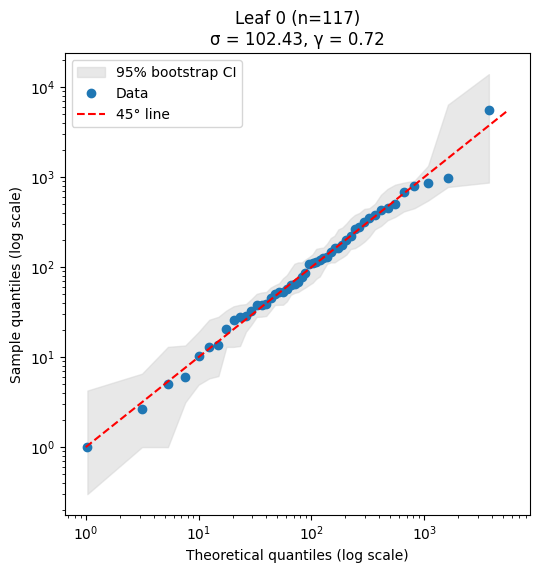

In [ ]:
graphs.plot_gp_tree_qq(gpd_tail_tree_pruned, X_tail, y_tail)


In [ ]:
importance=pd.DataFrame(importances)
importance.head()

,name,importance
0,Category_Business Disruption and System Failures,0.000
1,"Category_Clients, Products & Business Practices",0.000
2,Category_Damage to Physical Assets,0.000
3,Category_Employment Practices and Workplace Sa...,0.000
4,"Category_Execution, Delivery & Process Management",0.000


In [ ]:
# 모듈 헬퍼 준비
find_leaf = M.find_leaf
get_leaves = M._get_all_leaves

def _get_leaf_params(leaf):
    gp = getattr(leaf, "gpd_params", None)
    return (np.nan, np.nan) if gp is None else (float(gp[0]), float(gp[1]))

# CI 계산
cis = M.leaf_confidence_intervals(
    gpd_tail_tree_pruned, X_tail, y_tail,
    find_leaf=find_leaf, get_leaves=get_leaves, get_leaf_params=_get_leaf_params
)

# 보기 좋게 출력 (+ 리프별 샘플 수)
leaf_objs = np.array([find_leaf(gpd_tail_tree_pruned, X_tail[i]) for i in range(len(X_tail))], dtype=object)
leaves = get_leaves(gpd_tail_tree_pruned)

print("\n===== Leaf-wise γ 95% CI =====")
for i, rec in enumerate(cis):
    gamma = rec.get("gamma", np.nan)
    lo, hi = (rec.get("ci_95", [np.nan, np.nan]) + [np.nan, np.nan])[:2]
    n_i = int(np.sum(leaf_objs == leaves[i])) if i < len(leaves) else 0
    print(f"Leaf#{i:02d}  N={n_i:4d}   γ={gamma: .3f}   CI95=[{lo: .3f}, {hi: .3f}]")



===== Leaf-wise γ 95% CI =====
Leaf#00  N= 117   γ= 0.718   CI95=[ 0.410,  1.027]


In [ ]:
import numpy as np
import scipy.stats as st

def hill_ci(gamma_hat, n_exceed, alpha=0.05):
    """Asymptotic normal CI for Hill estimator"""
    se = gamma_hat / np.sqrt(n_exceed)
    z = st.norm.ppf(1 - alpha/2)
    return gamma_hat - z*se, gamma_hat + z*se

print("\n===== Leaf-wise γ 95% CI (Asymptotic) =====")
for i, rec in enumerate(cis):
    gamma = rec.get("gamma", np.nan)
    n_i = int(np.sum(leaf_objs == leaves[i])) if i < len(leaves) else 0
    if np.isnan(gamma) or n_i < 30:  # 샘플 적으면 skip
        lo, hi = np.nan, np.nan
    else:
        lo, hi = hill_ci(gamma, n_i, alpha=0.05)
    print(f"Leaf#{i:02d}  N={n_i:4d}   γ={gamma: .3f}   CI95=[{lo: .3f}, {hi: .3f}]")



===== Leaf-wise γ 95% CI (Asymptotic) =====
Leaf#00  N= 117   γ= 0.718   CI95=[ 0.588,  0.848]


##AIC

In [ ]:
# ================== POST-FIT EVAL: AIC/BIC, VaR, ES, GOF ==================

# ★ 1) raw y (초과치 아님) 준비
y_tail_raw = y_all_data[mask_tail]        # raw tail values
y_tail_excess = y_tail                    # (이미 있음) excess = y - u_threshold

# ★ 2) 네임스페이스 통일 (patched 모듈 함수 바인딩)
find_leaf_fn  = l1_l2_gpd_patched_new_catprune.find_leaf
get_leaves_fn = l1_l2_gpd_patched_new_catprune._get_all_leaves

# ★ 3) LN-only 트리도 patched 모듈로 생성 + 파라미터 부여
ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
    X_all_data, y_all_data, feature_names_list, min_leaf=30, max_depth=4
)
l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
    ln_only_tree, X_all_data, y_all_data, trunc_right=None
)

# 4) (선택) Bulk 모델로는 L2 트리 사용한 혼합 ln+gpd 성능을 보고 싶다면
tree_ln_for_mix  = l2_bulk_tree                      # bulk용 LN 트리
tree_gpd_for_mix = gpd_tail_tree_pruned              # tail용 GPD 트리 (없으면 None)

# 5) 모델 로그가능도/정보기준
ll_ln, k_ln, aic_ln, bic_ln = model_loglik_aic_bic(
    ln_only_tree, None,
    X_all_data, y_all_data,                      # LN-only: bulk=전체
    np.empty((0, X_all_data.shape[1])), np.empty(0),  # tail 없음
    u_threshold,
    find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
)

if tree_gpd_for_mix is not None:
    ll_mix, k_mix, aic_mix, bic_mix = model_loglik_aic_bic(
        tree_ln_for_mix, tree_gpd_for_mix,
        X_bulk, y_bulk,                         # bulk set
        X_tail, y_tail_raw,                     # ★ raw tail 필요!
        u_threshold,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
    )
else:
    ll_mix, k_mix, aic_mix, bic_mix = (np.nan, np.nan, np.nan, np.nan)

print(f"[LN Only]  logL={ll_ln:.1f}, k={k_ln}, AIC={aic_ln:.1f}, BIC={bic_ln:.1f}")
if tree_gpd_for_mix is not None:
    print(f"[LN+GPD]  logL={ll_mix:.1f}, k={k_mix}, AIC={aic_mix:.1f}, BIC={bic_mix:.1f}")
else:
    print("[LN+GPD]  (tail 표본 부족으로 GPD 트리 없음)")

# 6) VaR / ES
var_ln  = unconditional_var_ln(ln_only_tree, get_leaves=get_leaves_fn, alpha=0.99)
es_ln   = unconditional_es_ln(ln_only_tree,  get_leaves=get_leaves_fn, alpha=0.99)

if tree_gpd_for_mix is not None:
    var_mix = unconditional_var_mix(tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    es_mix  = unconditional_es_mix (tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    print(f"99% VaR | LN Only = {var_ln:,.0f}   LN+GPD = {var_mix:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}   LN+GPD = {es_mix:,.0f}")
else:
    print(f"99% VaR | LN Only = {var_ln:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}")

# 7) GPD 리프별 GOF (KS/AD) — excess 필요
if tree_gpd_for_mix is not None:
    gof_df = gpd_gof_leafwise(
        tree_gpd_for_mix, X_tail, y_tail_excess,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn, method="both"
    )
    pd.set_option('display.float_format', '{:,.3f}'.format)
    print("\n=== GPD Leaf-wise KS / AD Results ===")
    print(gof_df.to_string(index=False))


[LN Only]  logL=-6317.3, k=10, AIC=12654.6, BIC=12709.8
[LN+GPD]  logL=-6316.9, k=12, AIC=12657.8, BIC=12724.0
99% VaR | LN Only = 415   LN+GPD = 426
99% ES  | LN Only = 991   LN+GPD = 1,474

=== GPD Leaf-wise KS / AD Results ===
        leaf_id   n   sigma  gamma  KS stat  KS p  AD stat  AD p
140440508438208 117 102.434  0.718    0.044 0.973    0.232 0.972


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# ──────────────────────────────────────────────
# 0) Monte-Carlo 기반 VaR/ES 계산 (ppf 사용 안 함)
# ──────────────────────────────────────────────
def mc_var_es(dist, params, alpha=0.99, n_mc=300_000, random_state=42):
    """
    dist   : scipy.stats 배포( .rvs 가능 )
    params : dist.fit(...) 결과 파라미터 (튜플)
    alpha  : 신뢰수준 (예: 0.99)
    n_mc   : MC 표본 수
    """
    rng = np.random.default_rng(random_state)
    samples = dist.rvs(*params, size=n_mc, random_state=rng)

    # 샘플 기반 VaR/ES
    var_alpha = np.quantile(samples, alpha)
    tail = samples[samples >= var_alpha]
    # tail이 비면 방어적 처리
    if tail.size == 0:
        k = max(1, int(np.ceil(0.001 * n_mc)))
        tail = np.partition(samples, -k)[-k:]
    es_alpha = float(tail.mean())
    return float(var_alpha), es_alpha

# ──────────────────────────────────────────────
# 1) 적합 + AIC/BIC + (MC) VaR + (MC) ES
# ──────────────────────────────────────────────
def fit_score_var_es(dist, data, name,
                     fix_loc0=True,    # NIG에는 False 권장
                     alpha=0.99,
                     n_es_mc=300_000,
                     random_state=42):
    """
    dist, data, name, alpha 동일.
    n_es_mc : ES/ VaR 추정을 위한 MC 표본 수
    """
    try:
        data = np.asarray(data, dtype=float)
        data = data[np.isfinite(data)]
        if data.size == 0:
            raise ValueError("No valid data points.")

        # ① 분포 적합 (MLE)
        if fix_loc0:
            params = dist.fit(data, floc=0)   # loc을 0으로 고정 (NIG에는 비권장)
            k = len(params) - 1
        else:
            params = dist.fit(data)           # loc/scale/shape 모두 추정
            k = len(params)

        # ② 로그 가능도
        logpdf = dist.logpdf(data, *params)
        logpdf = logpdf[np.isfinite(logpdf)]
        logL   = float(logpdf.sum())
        n      = int(data.size)

        # ③ AIC / BIC
        aic = 2*k - 2*logL
        bic = np.log(n)*k - 2*logL

        # ④~⑤ VaR/ES (모두 MC로 계산 → ppf 사용 안 함)
        var_alpha, es_alpha = mc_var_es(dist, params, alpha, n_es_mc, random_state)

        return {
            "Distribution": name,
            "Log-Likelihood": logL,
            "AIC": aic,
            "BIC": bic,
            f"VaR {int(alpha*100)}%": var_alpha,
            f"ES  {int(alpha*100)}%": es_alpha
        }

    except Exception as e:
        return {
            "Distribution": name,
            "Log-Likelihood": f"Fit failed: {e}",
            "AIC": np.nan,
            "BIC": np.nan,
            f"VaR {int(alpha*100)}%": np.nan,
            f"ES  {int(alpha*100)}%": np.nan
        }

# ──────────────────────────────────────────────
# 2) 후보 분포 지정 & 실행
# ──────────────────────────────────────────────
candidates = {
    "Log-Normal":     (stats.lognorm,     True),
    "Gamma":          (stats.gamma,       True),
    "Weibull":        (stats.weibull_min, True),
    # NIG는 scipy.stats.norminvgauss (shape: a, b; loc, scale)
    # ★ floc=0 고정하지 마세요 → 수치 불안정 완화
    "NIG":            (stats.norminvgauss, False),
}

alpha = 0.99
results = [fit_score_var_es(dist, y_all_data, name,
                            fix_loc0=fix_loc0,   # NIG는 False
                            alpha=alpha,
                            n_es_mc=300_000,
                            random_state=42)
           for name, (dist, fix_loc0) in candidates.items()]

results_df = (pd.DataFrame(results)
                .sort_values("AIC", key=lambda s: s.fillna(np.inf))
                .reset_index(drop=True))

print(results_df)


  Distribution  Log-Likelihood        AIC        BIC  VaR 99%   ES  99%
0   Log-Normal      -6,436.114 12,876.229 12,887.267  405.921 1,168.057
1          NIG      -6,631.743 13,271.486 13,293.563  796.498 1,870.522
2      Weibull      -6,650.446 13,304.892 13,315.930  262.308   405.445
3        Gamma      -7,049.216 14,102.431 14,113.470  333.264   440.302



================  Model Comparison  ================

  Distribution  Log-Likelihood        AIC        BIC  VaR 99%   ES  99%      k
0       LN+GPD      -6,316.907 12,657.815 12,724.045  425.696 1,474.206 12.000
1   Log-Normal      -6,436.114 12,876.229 12,887.267  405.921 1,168.057    NaN
2          NIG      -6,631.743 13,271.486 13,293.563  796.498 1,870.522    NaN
3      Weibull      -6,650.446 13,304.892 13,315.930  262.308   405.445    NaN
4        Gamma      -7,049.216 14,102.431 14,113.470  333.264   440.302    NaN


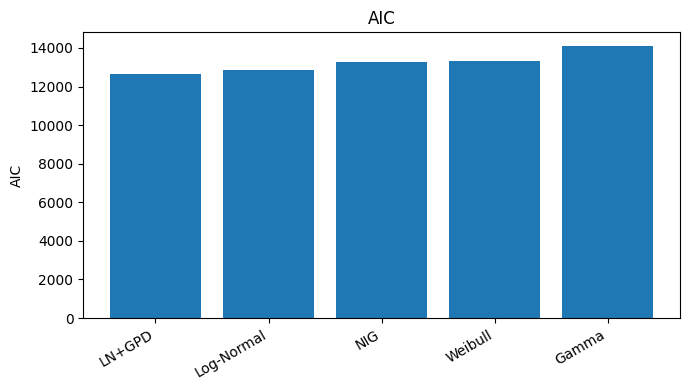

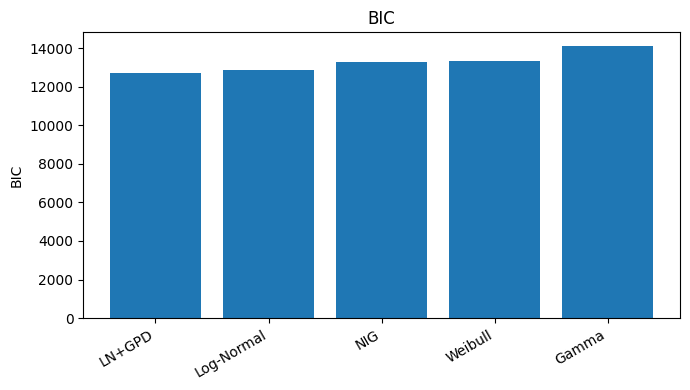

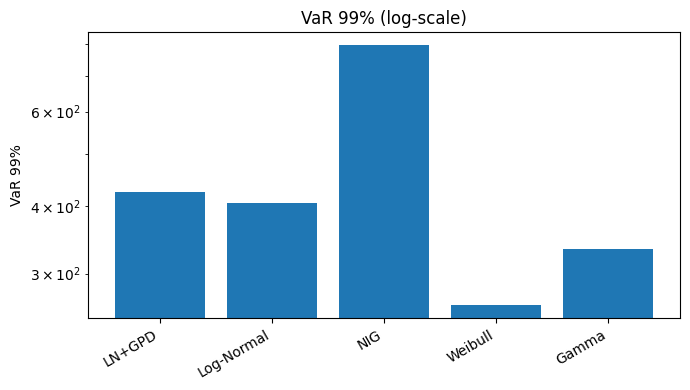

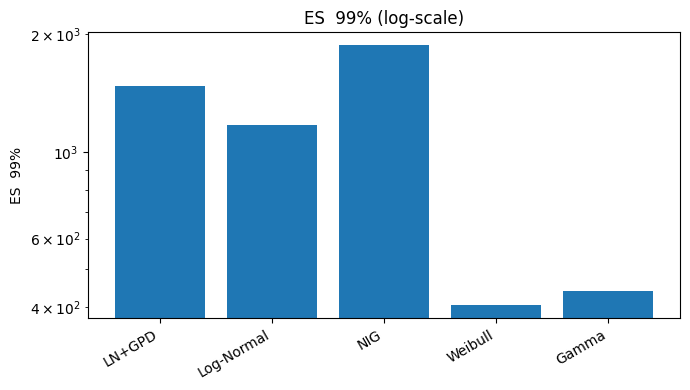

In [ ]:
# ──────────────────────────────────────────────
# 0) Tree 모델 행을 만들어 results_df 와 합치기
# ──────────────────────────────────────────────
tree_rows = pd.DataFrame([
#    {"Distribution": "LN‑Tree",  "Log-Likelihood": ll_ln,  "k": k_ln,
#     "AIC": aic_ln,  "BIC": bic_ln,
 #    "VaR 99%": var_ln,  "ES  99%": es_ln},
    {"Distribution": "LN+GPD",   "Log-Likelihood": ll_mix, "k": k_mix,
     "AIC": aic_mix, "BIC": bic_mix,
     "VaR 99%": var_mix, "ES  99%": es_mix}
])

full_df = (pd.concat([results_df, tree_rows], ignore_index=True)
             .sort_values("AIC")
             .reset_index(drop=True))

print("\n================  Model Comparison  ================\n")
print(full_df)

# ──────────────────────────────────────────────
# 1) AIC / BIC   (로그축 X)
# ──────────────────────────────────────────────
import matplotlib.pyplot as plt

for metric in ["AIC", "BIC"]:
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], full_df[metric])
    plt.title(f"{metric}")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

# ──────────────────────────────────────────────
# 2) VaR / ES   (log‑scale로 값 차이를 보기 좋게)
# ──────────────────────────────────────────────
for metric in ["VaR 99%", "ES  99%"]:
    y = pd.to_numeric(full_df[metric], errors="coerce").to_numpy(dtype=float)
    y_plot = np.where(np.isfinite(y) & (y > 0), y, np.nan)  # 🔧 inf/<=0 → NaN
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], y_plot)
    plt.yscale("log")
    plt.title(f"{metric} (log-scale)")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()




================ 1. Fitting Single Distributions on Tail Data ================


================ 2. Calculating GPD-Tree Performance on Tail Data ================

GPD-Tree -> Leaves: 1, k: 2, Log-L: -742.78, AIC: 1489.56, BIC: 1495.09


================ Final Tail Model Comparison (including GPD-Tree) ================

          Distribution  Log-Likelihood       AIC       BIC
GPD-Tree (from LN+GPD)        -742.782 1,489.563 1,495.087
            Log-Normal        -745.952 1,495.904 1,501.428
                   NIG        -748.301 1,504.603 1,515.651
               Weibull        -753.916 1,511.833 1,517.357
                 Gamma        -769.690 1,543.379 1,548.904


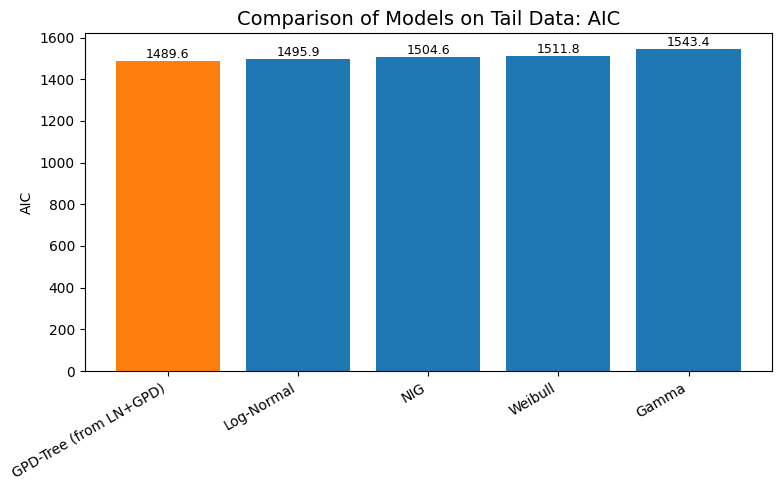

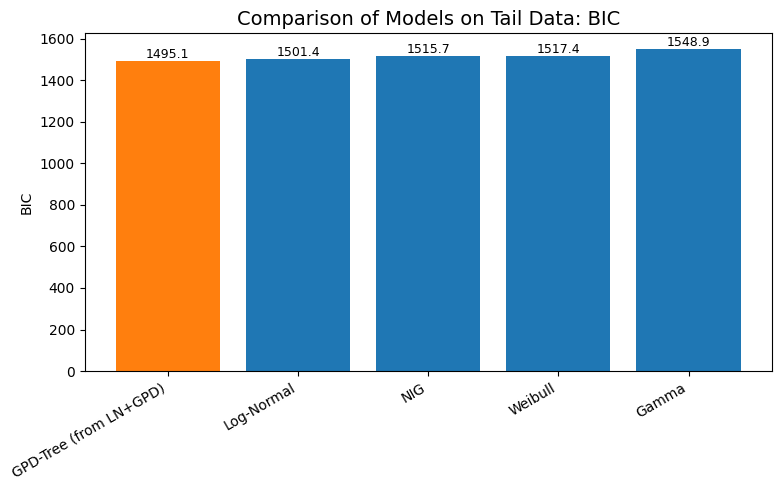

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
# l1_l2_gpd_patched_new_catprune.py 파일이 같은 디렉토리에 있다고 가정합니다.
import l1_l2_gpd_patched_new_catprune

# =================================================================================
# 0. 필요한 변수들이 이미 생성되어 있다고 가정합니다.
# =================================================================================
# 이 스크립트 실행 전에 다음 변수들이 준비되어 있어야 합니다:
#
# y_tail_excess: 꼬리 데이터의 초과분 (y - u)
# X_tail: 꼬리 데이터의 특성(X) 데이터
# gpd_tail_tree_pruned: 최종적으로 가지치기된 GPD-Tree 객체
# =================================================================================


# =================================================================================
# 1. 평가 및 비교를 위한 헬퍼 함수
# =================================================================================

def fit_single_dist_on_tail(dist, data, name, fix_loc0=True):
    """단일 분포를 꼬리 데이터에 적합하고 AIC/BIC를 계산"""
    try:
        data = np.asarray(data, dtype=float)
        data = data[np.isfinite(data) & (data > 0)]
        if data.size < 10:
            raise ValueError(f"Not enough data points ({data.size})")

        if fix_loc0:
            params = dist.fit(data, floc=0)
            k = len(params) - 1
        else:
            params = dist.fit(data)
            k = len(params)

        logpdf = dist.logpdf(data, *params)
        logpdf = logpdf[np.isfinite(logpdf)]
        logL = float(logpdf.sum())
        n = int(data.size)
        aic = 2*k - 2*logL
        bic = np.log(n)*k - 2*logL

        return {"Distribution": name, "Log-Likelihood": logL, "AIC": aic, "BIC": bic}
    except Exception as e:
        return {"Distribution": name, "Log-Likelihood": f"Fit failed: {e}", "AIC": np.nan, "BIC": np.nan}

# =================================================================================
# 2. 단일 분포들을 꼬리 데이터에 적합
# =================================================================================

# 꼬리 모델링에 적합한 후보 분포들
tail_candidates = {
    "Log-Normal":     (stats.lognorm,     True),
    "Gamma":          (stats.gamma,       True),
    "Weibull":        (stats.weibull_min, True),
    # NIG는 scipy.stats.norminvgauss (shape: a, b; loc, scale)
    # ★ floc=0 고정하지 마세요 → 수치 불안정 완화
    "NIG":            (stats.norminvgauss, False),
}

print("\n================ 1. Fitting Single Distributions on Tail Data ================\n")
single_dist_results = [fit_single_dist_on_tail(dist, y_tail_excess, name, fix_loc0=fix_loc0)
                       for name, (dist, fix_loc0) in tail_candidates.items()]

results_df = pd.DataFrame(single_dist_results)

# =================================================================================
# 3. GPD-Tree 모델의 꼬리 성능 계산 (핵심 부분)
# =================================================================================
print("\n================ 2. Calculating GPD-Tree Performance on Tail Data ================\n")

# 3.1. GPD-Tree의 Log-Likelihood 계산
# get_subtree_nll 함수는 Negative Log-Likelihood (NLL)을 반환합니다.
nll_gpd_tree = l1_l2_gpd_patched_new_catprune.get_subtree_nll(
    gpd_tail_tree_pruned, X_tail, y_tail_excess
)
ll_gpd_tree = -nll_gpd_tree # Log-Likelihood = -NLL

# 3.2. GPD-Tree의 파라미터 수(k) 계산
# 각 리프마다 (sigma, gamma) 2개의 파라미터가 있습니다.
num_leaves_gpd = l1_l2_gpd_patched_new_catprune._num_leaves(gpd_tail_tree_pruned)
k_gpd_tree = 2 * num_leaves_gpd

# 3.3. 꼬리 데이터 샘플 수(n)
n_tail = len(y_tail_excess)

# 3.4. GPD-Tree의 AIC, BIC 계산
aic_gpd_tree = 2 * k_gpd_tree - 2 * ll_gpd_tree
bic_gpd_tree = np.log(n_tail) * k_gpd_tree - 2 * ll_gpd_tree

print(f"GPD-Tree -> Leaves: {num_leaves_gpd}, k: {k_gpd_tree}, Log-L: {ll_gpd_tree:.2f}, AIC: {aic_gpd_tree:.2f}, BIC: {bic_gpd_tree:.2f}")


# =================================================================================
# 4. 최종 비교표 생성 및 출력
# =================================================================================

# GPD-Tree 결과를 DataFrame 행으로 만듭니다.
gpd_tree_row = pd.DataFrame([{
    "Distribution": "GPD-Tree (from LN+GPD)",
    "Log-Likelihood": ll_gpd_tree,
    "AIC": aic_gpd_tree,
    "BIC": bic_gpd_tree,
}])

# 단일 분포 결과와 GPD-Tree 결과를 합치고 AIC 기준으로 정렬합니다.
final_tail_df = (pd.concat([results_df, gpd_tree_row], ignore_index=True)
                 .sort_values("AIC")
                 .reset_index(drop=True))

print("\n\n================ Final Tail Model Comparison (including GPD-Tree) ================\n")
print(final_tail_df.to_string(index=False))


# =================================================================================
# 5. 시각화
# =================================================================================
for metric in ["AIC", "BIC"]:
    plt.figure(figsize=(8, 5))
    plot_df = final_tail_df.dropna(subset=[metric])

    # GPD-Tree를 다른 색으로 강조
    colors = ['C1' if 'GPD-Tree' in x else 'C0' for x in plot_df["Distribution"]]
    bars = plt.bar(plot_df["Distribution"], plot_df[metric], color=colors)

    plt.title(f"Comparison of Models on Tail Data: {metric}", fontsize=14)
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)

    # bar 위에 값 표시
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.1f}', va='bottom', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

In [ ]:
import pickle

# --- __main__ 블록 마지막에 추가 ---
save_path = '/content/drive/MyDrive/Operational_risk/'
# 1) 저장할 객체들 모으기
output = {
    # Bulk 트리
    'l1_bulk_tree' : l1_bulk_tree,
    'l2_bulk_tree' : l2_bulk_tree,
    # Tail 트리
    'gpd_raw_tree' : gpd_tail_tree_raw,
    'gpd_pruned_tree' : gpd_tail_tree_pruned,
    # 데이터
    'X_bulk'       : X_bulk,
    'y_bulk'       : y_bulk,
    'X_tail'       : X_tail,
    'y_tail'       : y_tail,
    'X_all_data'   : X_all_data,
    'y_all_data'   : y_all_data,
    'df_model_ready':df_model_ready,
    # (선택) 피처 이름
    'feature_names': feature_names_list,
    # (선택) 임계값
    'u_threshold'  : u_threshold
}

# 2) 피클 파일로 저장
with open(save_path + 'EPU_Category_insurance.pkl', 'wb') as f:
    pickle.dump(output, f)



#End